<a href="https://colab.research.google.com/github/Kevinlo937/cord-cutting-predicated/blob/main/topMSO_add_Vars.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import glob
import os

# 設定目錄路徑
directory_path = '帳單/'

# 取得所有檔名以 '帳單_' 開頭的 .csv 檔案的路徑
all_files = glob.glob(os.path.join(directory_path, "帳單_*.csv"))

# 建立一個空的 list 來存放所有 DataFrame
all_dataframes = []

# 迭代所有檔案路徑，讀取 CSV 並加入 list
for filename in all_files:
    df = pd.read_csv(filename, sep='^')
    all_dataframes.append(df)

# 使用 pd.concat 合併所有 DataFrame
ds_bill = pd.concat(all_dataframes, ignore_index=True)

✅ 已載入字型： ['Noto Sans TC']


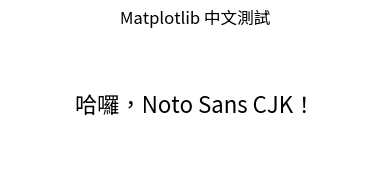

In [14]:
"""
跨平台載入 Noto Sans CJK 字型並驗證
在 VS Code + 本地 Python 環境執行
"""

import os
import sys
import platform
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib import font_manager

# ---------- 1. 推斷各作業系統的預設字型路徑 ----------
def guess_noto_path() -> str | None:
    """回傳可能存在的 NotoSansCJK-Regular.ttc 路徑，找不到則回傳 None"""
    candidates = []

    match platform.system():
        case "Windows":
            candidates = [
                r"C:\Windows\Fonts\NotoSansCJK-Regular.ttc",
                r"C:\Windows\Fonts\NotoSansCJKtc-Regular.otf",
            ]
        case "Darwin":  # macOS
            candidates = [
                "/Library/Fonts/NotoSansCJK-Regular.ttc",
                "/System/Library/Fonts/NotoSansCJK.ttc",
            ]
        case "Linux":
            # 常見安裝位置；亦可加入 ~/.local/share/fonts
            candidates = [
                "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
                "/usr/share/fonts/truetype/noto/NotoSansCJK-Regular.ttc",
                str(Path.home() / ".local/share/fonts/NotoSansCJK-Regular.ttc"),
            ]

    for p in candidates:
        if Path(p).is_file():
            return p
    return None


# ---------- 2. 取得字型路徑（可改為專案內相對路徑） ----------
# font_path = guess_noto_path()
font_path = 'NotoSansTC-Regular.ttf'  # 若已下載字型檔，請確認路徑正確

if font_path is None:
    # 若系統沒安裝，可改成專案相對路徑，例如 Path("fonts/NotoSansCJK-Regular.ttc")
    font_path = "fonts/NotoSansCJK-Regular.ttc"  # 請確認實際檔案位置
    if not Path(font_path).is_file():
        sys.exit(
            f"❌ 找不到 Noto Sans CJK 字型！\n"
            f"  請先安裝字型或把字型檔放到 {font_path}"
        )

# ---------- 3. 動態註冊並設定為預設中文字型 ----------
font_manager.fontManager.addfont(font_path)
plt.rcParams["font.family"] = font_manager.FontProperties(fname=font_path).get_name()

# ---------- 4. 驗證 ----------
print("✅ 已載入字型：", plt.rcParams["font.family"])

# (可選) 畫個示範圖
plt.figure(figsize=(4, 2))
plt.title("Matplotlib 中文測試")
plt.text(0.5, 0.5, "哈囉，Noto Sans CJK！", ha="center", va="center", size=16)
plt.axis("off")
plt.tight_layout()
plt.show()


topMSO_add_Vars.ipynb

目的：主要增加 平均繳款延遲日數、最常見交款方式 兩項帳務特徵，然後做新一輪模型訓練

1.取得2022~2024帳單資料，清洗掉0元帳單及目標日期區間外的帳單資料後，輸出bill_22_24_filtered.csv，包含下欄位資訊
客編	相關編號	帳單起日	帳單迄日	金額	銷帳日期	繳別	繳費方式

2.與相同2022~2024 區間已數值化派工資料集 ds_numService.csv 資料集合併，輸出ds_numService_with_billing.csv

In [2]:
ds_bill.head()

,客編,相關編號,帳單起日,帳單迄日,金額,銷帳日期,繳別,繳費方式
0,674831,1272367,1970/01/01 08:00:00,1970/01/01 08:00:00,0,14-2月 -22,1,CVS臨櫃代收(7-11)
1,549309,1295146,1970/01/01 08:00:00,1970/01/01 08:00:00,0,14-2月 -22,1,CVS臨櫃代收(7-11)
2,711264,785596,2005/04/17 00:00:00,2005/06/14 00:00:00,1342,23-2月 -22,1,CVS臨櫃代收(7-11)
3,712384,786716,2009/05/01 00:00:00,2009/06/11 00:00:00,820,10-2月 -22,1,CVS臨櫃代收(7-11)
4,702883,777193,2011/09/01 00:00:00,2011/09/30 00:00:00,0,25-2月 -22,1,CVS臨櫃代收(7-11)


In [3]:
ds_bill.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12261132 entries, 0 to 12261131
Data columns (total 8 columns):
 #   Column  Dtype 
---  ------  ----- 
 0   客編      int64 
 1   相關編號    int64 
 2   帳單起日    object
 3   帳單迄日    object
 4   金額      int64 
 5   銷帳日期    object
 6   繳別      int64 
 7   繳費方式    object
dtypes: int64(4), object(4)
memory usage: 748.4+ MB


In [3]:
ds_bill_filtered = ds_bill[ds_bill['金額'] != 0].copy()  # 建立副本


In [4]:
ds_bill_filtered.loc[:, '帳單起日'] = pd.to_datetime(ds_bill_filtered['帳單起日'], format='%Y/%m/%d %H:%M:%S', errors='coerce')
ds_bill_filtered.loc[:, '帳單迄日'] = pd.to_datetime(ds_bill_filtered['帳單迄日'], format='%Y/%m/%d %H:%M:%S', errors='coerce')

In [5]:
ds_bill_filtered.head()

,客編,相關編號,帳單起日,帳單迄日,金額,銷帳日期,繳別,繳費方式
2,711264,785596,2005-04-17 00:00:00,2005-06-14 00:00:00,1342,23-2月 -22,1,CVS臨櫃代收(7-11)
3,712384,786716,2009-05-01 00:00:00,2009-06-11 00:00:00,820,10-2月 -22,1,CVS臨櫃代收(7-11)
6,357531,939921,2012-04-11 00:00:00,2012-05-10 00:00:00,600,08-2月 -22,6,CVS臨櫃代收(7-11)
9,917372,1160943,2014-04-09 00:00:00,2014-05-12 00:00:00,453,08-2月 -22,1,CVS臨櫃代收(7-11)
10,848809,923456,2014-06-01 00:00:00,2014-07-09 00:00:00,760,24-2月 -22,1,CVS臨櫃代收(7-11)


In [6]:
# 檢查 ds_bill_filtered 的銷帳日期空值情況

print("=== 檢查 ds_bill_filtered 銷帳日期空值情況 ===")

# 1. 基本資訊檢查
print(f"資料總筆數: {len(ds_bill_filtered):,}")
print(f"銷帳日期欄位型態: {ds_bill_filtered['銷帳日期'].dtype}")

# 2. 空值統計
null_count = ds_bill_filtered['銷帳日期'].isnull().sum()
not_null_count = ds_bill_filtered['銷帳日期'].notnull().sum()
total_count = len(ds_bill_filtered)

print(f"\n=== 空值統計 ===")
print(f"銷帳日期為空值 (NaN/NaT): {null_count:,} 筆")
print(f"銷帳日期有值: {not_null_count:,} 筆")
print(f"空值比例: {null_count/total_count*100:.2f}%")
print(f"有值比例: {not_null_count/total_count*100:.2f}%")

# 3. 檢查空字串和其他可能的空值表示
if ds_bill_filtered['銷帳日期'].dtype == 'object':
    empty_string_count = (ds_bill_filtered['銷帳日期'] == '').sum()
    whitespace_count = ds_bill_filtered['銷帳日期'].str.strip().eq('').sum()
    none_string_count = (ds_bill_filtered['銷帳日期'] == 'None').sum()
    
    print(f"\n=== 其他空值形式檢查 ===")
    print(f"空字串 (''): {empty_string_count:,} 筆")
    print(f"純空白字元: {whitespace_count:,} 筆")
    print(f"字串 'None': {none_string_count:,} 筆")

# 4. 顯示銷帳日期的前10筆資料（包含空值）
print(f"\n=== 銷帳日期前10筆資料 ===")
sample_data = ds_bill_filtered[['客編', '相關編號', '帳單起日', '銷帳日期', '金額']].head(10)
print(sample_data.to_string(index=False))

# 5. 如果有空值，顯示空值記錄的樣本
if null_count > 0:
    print(f"\n=== 空值記錄樣本 (前10筆) ===")
    null_records = ds_bill_filtered[ds_bill_filtered['銷帳日期'].isnull()]
    
    display_cols = ['客編', '相關編號', '帳單起日', '帳單迄日', '金額', '銷帳日期', '繳別', '繳費方式']
    available_cols = [col for col in display_cols if col in null_records.columns]
    
    print(null_records[available_cols].head(10).to_string(index=False))
    
    # 分析空值記錄的特徵
    print(f"\n=== 空值記錄特徵分析 ===")
    print(f"涉及客編數: {null_records['客編'].nunique():,}")
    
    if '金額' in null_records.columns:
        amount_stats = null_records['金額'].describe()
        print(f"空值記錄金額統計:")
        print(f"  平均金額: {amount_stats['mean']:.2f}")
        print(f"  最大金額: {amount_stats['max']:.2f}")
        print(f"  最小金額: {amount_stats['min']:.2f}")
    
    if '繳別' in null_records.columns:
        payment_type_dist = null_records['繳別'].value_counts().head(5)
        print(f"\n空值記錄繳別分布 (前5項):")
        for payment_type, count in payment_type_dist.items():
            print(f"  {payment_type}: {count:,} 筆")

# 6. 檢查銷帳日期的值分布（如果不是太多唯一值的話）
unique_count = ds_bill_filtered['銷帳日期'].nunique()
print(f"\n=== 銷帳日期值分布 ===")
print(f"銷帳日期唯一值數量: {unique_count:,}")

if unique_count <= 20:  # 如果唯一值不多，顯示分布
    date_dist = ds_bill_filtered['銷帳日期'].value_counts().head(10)
    print(f"銷帳日期分布 (前10項):")
    for date_val, count in date_dist.items():
        print(f"  {date_val}: {count:,} 筆")

# 7. 檢查銷帳日期的範圍（如果是日期格式）
if pd.api.types.is_datetime64_any_dtype(ds_bill_filtered['銷帳日期']):
    valid_dates = ds_bill_filtered['銷帳日期'].dropna()
    if len(valid_dates) > 0:
        print(f"\n=== 銷帳日期範圍 ===")
        print(f"最早銷帳日期: {valid_dates.min()}")
        print(f"最晚銷帳日期: {valid_dates.max()}")
        print(f"日期範圍: {(valid_dates.max() - valid_dates.min()).days} 天")

# 8. 總結
print(f"\n=== 檢查總結 ===")
if null_count == 0:
    print("✅ 銷帳日期欄位沒有空值")
else:
    print(f"⚠️ 銷帳日期欄位有 {null_count:,} 個空值 ({null_count/total_count*100:.2f}%)")
    print("建議：")
    print("  1. 如果空值比例較高，需要決定如何處理（刪除或填補）")
    print("  2. 如果空值有特定模式，可能需要進一步調查原因")
    print("  3. 考慮空值對後續分析的影響")

=== 檢查 ds_bill_filtered 銷帳日期空值情況 ===
資料總筆數: 5,110,734
銷帳日期欄位型態: object

=== 空值統計 ===
銷帳日期為空值 (NaN/NaT): 0 筆
銷帳日期有值: 5,110,734 筆
空值比例: 0.00%
有值比例: 100.00%

=== 其他空值形式檢查 ===
空字串 (''): 0 筆
純空白字元: 0 筆
字串 'None': 0 筆

=== 銷帳日期前10筆資料 ===
    客編    相關編號                帳單起日      銷帳日期   金額
711264  785596 2005-04-17 00:00:00 23-2月 -22 1342
712384  786716 2009-05-01 00:00:00 10-2月 -22  820
357531  939921 2012-04-11 00:00:00 08-2月 -22  600
917372 1160943 2014-04-09 00:00:00 08-2月 -22  453
848809  923456 2014-06-01 00:00:00 24-2月 -22  760
703175  777486 2015-06-01 00:00:00 22-2月 -22  696
884540 1025584 2015-06-19 00:00:00 15-2月 -22  256
834271  909017 2015-08-01 00:00:00 18-2月 -22 1843
718073  792417 2015-10-01 00:00:00 16-2月 -22  667
687046 1063496 2015-12-08 00:00:00 08-2月 -22  650

=== 銷帳日期值分布 ===
銷帳日期唯一值數量: 1,089

=== 檢查總結 ===
✅ 銷帳日期欄位沒有空值


In [7]:
ds_bill_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5110734 entries, 2 to 12261131
Data columns (total 8 columns):
 #   Column  Dtype 
---  ------  ----- 
 0   客編      int64 
 1   相關編號    int64 
 2   帳單起日    object
 3   帳單迄日    object
 4   金額      int64 
 5   銷帳日期    object
 6   繳別      int64 
 7   繳費方式    object
dtypes: int64(4), object(4)
memory usage: 350.9+ MB


In [8]:
# 篩選帳單迄日在 2022 年至 2024 年之間的資料
ds_bill_filtered = ds_bill_filtered[
    (ds_bill_filtered['帳單迄日'] >= pd.Timestamp('2022-01-01')) &
    (ds_bill_filtered['帳單迄日'] <= pd.Timestamp('2024-12-31'))
]

In [9]:
ds_bill_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4610073 entries, 20 to 12261068
Data columns (total 8 columns):
 #   Column  Dtype 
---  ------  ----- 
 0   客編      int64 
 1   相關編號    int64 
 2   帳單起日    object
 3   帳單迄日    object
 4   金額      int64 
 5   銷帳日期    object
 6   繳別      int64 
 7   繳費方式    object
dtypes: int64(4), object(4)
memory usage: 316.5+ MB


In [13]:
ds_bill_filtered.reset_index(drop=True, inplace=True)
ds_bill = ds_bill_filtered.copy()

In [12]:
# 載入資料
dataset = pd.read_csv('cleaned_dataset_fix_20241231.csv',sep='^')

In [14]:
# 根據 dataset 中的客編及相關編號篩選 ds_bill 資料

print("=== 根據 dataset 篩選 ds_bill 資料 ===")

# 1. 檢查當前資料狀態
print("篩選前資料狀態：")
print(f"ds_bill 總筆數: {len(ds_bill):,}")
print(f"dataset 總筆數: {len(dataset):,}")

# 2. 檢查欄位名稱
print("\nds_bill 欄位:")
print(ds_bill.columns.tolist())

print("\ndataset 欄位:")
print(dataset.columns.tolist())

# 3. 檢查客編及相關編號的資料型態
print(f"\nds_bill 客編資料型態: {ds_bill['客編'].dtype}")
print(f"ds_bill 相關編號資料型態: {ds_bill['相關編號'].dtype}")
print(f"dataset 客編資料型態: {dataset['客編'].dtype}")
print(f"dataset 相關編號資料型態: {dataset['相關編號'].dtype}")

# 4. 統一資料型態（轉為字串以確保比對準確性）
print("\n統一資料型態為字串...")
ds_bill['客編'] = ds_bill['客編'].astype(str)
ds_bill['相關編號'] = ds_bill['相關編號'].astype(str)
dataset['客編'] = dataset['客編'].astype(str)
dataset['相關編號'] = dataset['相關編號'].astype(str)

# 5. 建立 dataset 中的客編+相關編號組合索引
print("\n建立參考索引...")
dataset_keys = set(zip(dataset['客編'], dataset['相關編號']))
print(f"dataset 中唯一的客編+相關編號組合數: {len(dataset_keys):,}")

# 6. 建立 ds_bill 中的客編+相關編號組合
ds_bill_keys = list(zip(ds_bill['客編'], ds_bill['相關編號']))
print(f"ds_bill 中客編+相關編號組合數: {len(ds_bill_keys):,}")

# 7. 篩選存在於 dataset 中的記錄
print("\n開始篩選...")
# 建立篩選條件
mask = [key in dataset_keys for key in ds_bill_keys]
ds_bill_filtered_by_dataset = ds_bill[mask].copy()

# 8. 統計篩選結果
original_count = len(ds_bill)
filtered_count = len(ds_bill_filtered_by_dataset)
removed_count = original_count - filtered_count

print(f"\n=== 篩選結果統計 ===")
print(f"原始 ds_bill 筆數: {original_count:,}")
print(f"篩選後保留筆數: {filtered_count:,}")
print(f"刪除筆數: {removed_count:,}")
print(f"保留比例: {filtered_count/original_count*100:.2f}%")
print(f"刪除比例: {removed_count/original_count*100:.2f}%")

# 9. 驗證篩選結果
print(f"\n=== 篩選結果驗證 ===")

# 檢查篩選後的資料是否都存在於 dataset 中
filtered_keys = set(zip(ds_bill_filtered_by_dataset['客編'], ds_bill_filtered_by_dataset['相關編號']))
verification_count = len(filtered_keys.intersection(dataset_keys))
total_filtered_unique = len(filtered_keys)

print(f"篩選後唯一客編+相關編號組合數: {total_filtered_unique:,}")
print(f"與 dataset 匹配的組合數: {verification_count:,}")
print(f"驗證通過率: {verification_count/total_filtered_unique*100:.2f}%")

if verification_count == total_filtered_unique:
    print("✅ 篩選結果驗證通過，所有保留記錄都存在於 dataset 中")
else:
    print("⚠️ 篩選結果異常，部分記錄可能不匹配")

# 10. 顯示被刪除的記錄樣本（供確認）
if removed_count > 0:
    print(f"\n=== 被刪除記錄樣本 (前10筆) ===")
    removed_records = ds_bill[~ds_bill.index.isin(ds_bill_filtered_by_dataset.index)]
    display_cols = ['客編', '相關編號', '帳單起日', '帳單迄日', '金額']
    available_cols = [col for col in display_cols if col in removed_records.columns]
    
    print("被刪除的記錄樣本:")
    print(removed_records[available_cols].head(10).to_string(index=False))
    
    # 分析被刪除記錄的特徵
    print(f"\n被刪除記錄特徵:")
    print(f"  涉及客編數: {removed_records['客編'].nunique():,}")
    print(f"  涉及相關編號數: {removed_records['相關編號'].nunique():,}")
    
    if '金額' in removed_records.columns:
        removed_amount_sum = removed_records['金額'].sum()
        removed_amount_avg = removed_records['金額'].mean()
        print(f"  被刪除記錄總金額: {removed_amount_sum:,.2f}")
        print(f"  被刪除記錄平均金額: {removed_amount_avg:.2f}")

# 11. 顯示保留記錄樣本
print(f"\n=== 保留記錄樣本 (前10筆) ===")
display_cols = ['客編', '相關編號', '帳單起日', '帳單迄日', '金額', '銷帳日期']
available_cols = [col for col in display_cols if col in ds_bill_filtered_by_dataset.columns]
print(ds_bill_filtered_by_dataset[available_cols].head(10).to_string(index=False))

# 12. 分析保留記錄的分布
print(f"\n=== 保留記錄分析 ===")
if len(ds_bill_filtered_by_dataset) > 0:
    print(f"保留記錄涉及客編數: {ds_bill_filtered_by_dataset['客編'].nunique():,}")
    print(f"保留記錄涉及相關編號數: {ds_bill_filtered_by_dataset['相關編號'].nunique():,}")
    
    if '金額' in ds_bill_filtered_by_dataset.columns:
        retained_amount_sum = ds_bill_filtered_by_dataset['金額'].sum()
        retained_amount_avg = ds_bill_filtered_by_dataset['金額'].mean()
        print(f"保留記錄總金額: {retained_amount_sum:,.2f}")
        print(f"保留記錄平均金額: {retained_amount_avg:.2f}")
    
    # 客編分布統計
    cust_distribution = ds_bill_filtered_by_dataset['客編'].value_counts().head(10)
    print(f"\n保留記錄客編分布 (前10名):")
    for cust_id, count in cust_distribution.items():
        print(f"  客編 {cust_id}: {count} 筆")

# 13. 更新 ds_bill 變數（可選）
# 如果要直接更新 ds_bill，取消下面註解
# ds_bill = ds_bill_filtered_by_dataset.copy()

print(f"\n✅ 篩選完成")
print(f"篩選後的資料已存於 ds_bill_filtered_by_dataset 變數中")
print(f"如需要，可將此變數重新賦值給 ds_bill")

# 14. 可選：儲存篩選後的資料
'''
save_option = input("\n是否要儲存篩選後的資料到 CSV 檔案? (y/n): ")
if save_option.lower() == 'y':
    output_filename = 'ds_bill_filtered_by_dataset.csv'
    ds_bill_filtered_by_dataset.to_csv(output_filename, index=False, sep='^')
    print(f"✅ 篩選後資料已儲存至 {output_filename}")
'''

=== 根據 dataset 篩選 ds_bill 資料 ===
篩選前資料狀態：
ds_bill 總筆數: 4,610,073
dataset 總筆數: 315,066

ds_bill 欄位:
['客編', '相關編號', '帳單起日', '帳單迄日', '金額', '銷帳日期', '繳別', '繳費方式']

dataset 欄位:
['客編', '產品名稱', '用戶種類', '相關編號', '起日', '迄日', '系統台', '地區', '繳別', '使用狀態']

ds_bill 客編資料型態: int64
ds_bill 相關編號資料型態: int64
dataset 客編資料型態: int64
dataset 相關編號資料型態: int64

統一資料型態為字串...

建立參考索引...
dataset 中唯一的客編+相關編號組合數: 315,066
ds_bill 中客編+相關編號組合數: 4,610,073

開始篩選...

=== 篩選結果統計 ===
原始 ds_bill 筆數: 4,610,073
篩選後保留筆數: 1,070,373
刪除筆數: 3,539,700
保留比例: 23.22%
刪除比例: 76.78%

=== 篩選結果驗證 ===
篩選後唯一客編+相關編號組合數: 122,537
與 dataset 匹配的組合數: 122,537
驗證通過率: 100.00%
✅ 篩選結果驗證通過，所有保留記錄都存在於 dataset 中

=== 被刪除記錄樣本 (前10筆) ===
被刪除的記錄樣本:
     客編    相關編號                帳單起日                帳單迄日  金額
 712195 2261495 2022-02-10 00:00:00 2023-02-09 00:00:00 900
 523519 1133492 2022-01-29 00:00:00 2022-07-31 00:00:00 120
 763995 1942146 2022-01-29 00:00:00 2022-07-31 00:00:00 120
1068080 2166756 2021-06-05 00:00:00 2022-03-24 00:00:00 100
 635093 1742849 202

'\nsave_option = input("\n是否要儲存篩選後的資料到 CSV 檔案? (y/n): ")\nif save_option.lower() == \'y\':\n    output_filename = \'ds_bill_filtered_by_dataset.csv\'\n    ds_bill_filtered_by_dataset.to_csv(output_filename, index=False, sep=\'^\')\n    print(f"✅ 篩選後資料已儲存至 {output_filename}")\n'

In [15]:
ds_bill_filtered_by_dataset.reset_index(drop=True, inplace=True)
ds_bill_filtered_by_dataset.info()
ds_bill_filtered_temp = ds_bill_filtered_by_dataset.copy()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1070373 entries, 0 to 1070372
Data columns (total 8 columns):
 #   Column  Non-Null Count    Dtype 
---  ------  --------------    ----- 
 0   客編      1070373 non-null  object
 1   相關編號    1070373 non-null  object
 2   帳單起日    1070373 non-null  object
 3   帳單迄日    1070373 non-null  object
 4   金額      1070373 non-null  int64 
 5   銷帳日期    1070373 non-null  object
 6   繳別      1070373 non-null  int64 
 7   繳費方式    1070373 non-null  object
dtypes: int64(2), object(6)
memory usage: 65.3+ MB


In [16]:
# 分析 ds_bill_filtered_temp 中銷帳日期的格式

print("=== 分析 ds_bill_filtered_temp 銷帳日期格式 ===")

# 1. 基本資訊檢查
print(f"資料總筆數: {len(ds_bill_filtered_temp):,}")
print(f"銷帳日期欄位型態: {ds_bill_filtered_temp['銷帳日期'].dtype}")

# 2. 空值統計
null_count = ds_bill_filtered_temp['銷帳日期'].isnull().sum()
not_null_count = ds_bill_filtered_temp['銷帳日期'].notnull().sum()

print(f"\n=== 空值統計 ===")
print(f"銷帳日期為空值: {null_count:,} 筆")
print(f"銷帳日期有值: {not_null_count:,} 筆")
print(f"空值比例: {null_count/len(ds_bill_filtered_temp)*100:.2f}%")

# 3. 取得非空值的銷帳日期進行格式分析
non_null_dates = ds_bill_filtered_temp['銷帳日期'].dropna()

if len(non_null_dates) > 0:
    print(f"\n=== 銷帳日期樣本展示 (前20筆) ===")
    sample_dates = non_null_dates.head(20)
    for i, date in enumerate(sample_dates):
        print(f"  {i+1:2d}: {date} (type: {type(date)})")
    
    # 4. 格式模式分析 (如果是字串格式)
    if ds_bill_filtered_temp['銷帳日期'].dtype == 'object':
        print(f"\n=== 格式模式分析 ===")
        
        # 定義各種可能的格式模式
        format_patterns = {
            '%d-%b -%y': r'^\d{1,2}-[A-Za-z]{3} -\d{2}$',          # 15-Jan -24
            '%d-%b-%y': r'^\d{1,2}-[A-Za-z]{3}-\d{2}$',           # 15-Jan-24
            '%Y-%m-%d': r'^\d{4}-\d{2}-\d{2}$',                   # 2024-01-15
            '%Y/%m/%d': r'^\d{4}/\d{2}/\d{2}$',                   # 2024/01/15
            '%d/%m/%Y': r'^\d{1,2}/\d{1,2}/\d{4}$',              # 15/01/2024
            '%Y-%m-%d %H:%M:%S': r'^\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}$',  # 2024-01-15 10:30:00
        }
        
        format_counts = {}
        unmatched_samples = []
        
        for pattern_name, regex_pattern in format_patterns.items():
            matches = non_null_dates.str.match(regex_pattern, na=False)
            count = matches.sum()
            format_counts[pattern_name] = count
            
            if count > 0:
                print(f"{pattern_name:20}: {count:,} 筆")
                # 顯示該格式的樣本
                sample_matches = non_null_dates[matches].head(3)
                for j, sample in enumerate(sample_matches):
                    print(f"  範例{j+1}: {sample}")
        
        # 檢查未匹配的格式
        total_matched = sum(format_counts.values())
        unmatched_count = len(non_null_dates) - total_matched
        
        if unmatched_count > 0:
            print(f"\n{'未識別格式':20}: {unmatched_count:,} 筆")
            
            # 找出未匹配的樣本
            all_matched = pd.Series(False, index=non_null_dates.index)
            for regex_pattern in format_patterns.values():
                all_matched |= non_null_dates.str.match(regex_pattern, na=False)
            
            unmatched_data = non_null_dates[~all_matched]
            
            print("未識別格式樣本 (前10筆):")
            for i, sample in enumerate(unmatched_data.head(10)):
                print(f"  {i+1}: '{sample}' (長度: {len(str(sample))})")
        
        # 5. 長度分析
        print(f"\n=== 字串長度分析 ===")
        date_lengths = non_null_dates.astype(str).str.len()
        length_counts = date_lengths.value_counts().sort_index()
        
        print("字串長度分布:")
        for length, count in length_counts.items():
            print(f"  長度 {length}: {count:,} 筆")
            
            # 顯示該長度的樣本
            length_samples = non_null_dates[date_lengths == length].head(3)
            for j, sample in enumerate(length_samples):
                print(f"    範例{j+1}: '{sample}'")
        
        # 6. 特殊字符分析
        print(f"\n=== 特殊字符分析 ===")
        
        # 檢查包含特定字符的數量
        char_analysis = {
            '包含 "-"': non_null_dates.str.contains('-', na=False).sum(),
            '包含 "/"': non_null_dates.str.contains('/', na=False).sum(),
            '包含 " "': non_null_dates.str.contains(' ', na=False).sum(),
            '包含 ":"': non_null_dates.str.contains(':', na=False).sum(),
            '包含英文字母': non_null_dates.str.contains('[A-Za-z]', na=False).sum(),
            '包含數字': non_null_dates.str.contains('\d', na=False).sum(),
        }
        
        for char_type, count in char_analysis.items():
            percentage = count / len(non_null_dates) * 100
            print(f"{char_type:15}: {count:,} 筆 ({percentage:.1f}%)")
        
        # 7. 月份格式分析 (檢查是否有中文或英文月份)
        print(f"\n=== 月份格式分析 ===")
        
        # 英文月份縮寫
        eng_months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                     'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
        
        # 中文月份
        cn_months = ['1月', '2月', '3月', '4月', '5月', '6月',
                    '7月', '8月', '9月', '10月', '11月', '12月']
        
        # 檢查英文月份
        eng_month_pattern = '|'.join(eng_months)
        eng_month_count = non_null_dates.str.contains(eng_month_pattern, na=False).sum()
        print(f"包含英文月份: {eng_month_count:,} 筆")
        
        # 檢查中文月份
        cn_month_pattern = '|'.join(cn_months)
        cn_month_count = non_null_dates.str.contains(cn_month_pattern, na=False).sum()
        print(f"包含中文月份: {cn_month_count:,} 筆")
        
        # 顯示英文月份樣本
        if eng_month_count > 0:
            eng_samples = non_null_dates[non_null_dates.str.contains(eng_month_pattern, na=False)].head(5)
            print("英文月份樣本:")
            for i, sample in enumerate(eng_samples):
                print(f"  {i+1}: {sample}")
        
        # 顯示中文月份樣本
        if cn_month_count > 0:
            cn_samples = non_null_dates[non_null_dates.str.contains(cn_month_pattern, na=False)].head(5)
            print("中文月份樣本:")
            for i, sample in enumerate(cn_samples):
                print(f"  {i+1}: {sample}")

    elif pd.api.types.is_datetime64_any_dtype(ds_bill_filtered_temp['銷帳日期']):
        print(f"\n=== datetime 格式分析 ===")
        print("銷帳日期已轉換為 datetime 格式")
        
        # 顯示 datetime 樣本
        datetime_samples = non_null_dates.head(10)
        print("datetime 樣本:")
        for i, sample in enumerate(datetime_samples):
            print(f"  {i+1}: {sample}")
        
        # 日期範圍分析
        min_date = non_null_dates.min()
        max_date = non_null_dates.max()
        print(f"\n日期範圍:")
        print(f"  最早日期: {min_date}")
        print(f"  最晚日期: {max_date}")
        print(f"  日期跨度: {(max_date - min_date).days} 天")

    # 8. 總結
    print(f"\n=== 格式分析總結 ===")
    if ds_bill_filtered_temp['銷帳日期'].dtype == 'object' and len(non_null_dates) > 0:
        print("銷帳日期為字串格式，發現的主要格式:")
        sorted_formats = sorted(format_counts.items(), key=lambda x: x[1], reverse=True)
        for fmt, count in sorted_formats:
            if count > 0:
                percentage = count / len(non_null_dates) * 100
                print(f"  {fmt}: {count:,} 筆 ({percentage:.1f}%)")
        
        if unmatched_count > 0:
            unmatched_percentage = unmatched_count / len(non_null_dates) * 100
            print(f"  未識別格式: {unmatched_count:,} 筆 ({unmatched_percentage:.1f}%)")
            
    elif pd.api.types.is_datetime64_any_dtype(ds_bill_filtered_temp['銷帳日期']):
        print("銷帳日期已是標準 datetime 格式")
    else:
        print("無法識別的銷帳日期格式")

else:
    print("⚠️ 所有銷帳日期都是空值")

=== 分析 ds_bill_filtered_temp 銷帳日期格式 ===
資料總筆數: 1,070,373
銷帳日期欄位型態: object

=== 空值統計 ===
銷帳日期為空值: 0 筆
銷帳日期有值: 1,070,373 筆
空值比例: 0.00%

=== 銷帳日期樣本展示 (前20筆) ===
   1: 08-2月 -22 (type: <class 'str'>)
   2: 14-2月 -22 (type: <class 'str'>)
   3: 23-2月 -22 (type: <class 'str'>)
   4: 23-2月 -22 (type: <class 'str'>)
   5: 08-2月 -22 (type: <class 'str'>)
   6: 24-2月 -22 (type: <class 'str'>)
   7: 24-2月 -22 (type: <class 'str'>)
   8: 23-2月 -22 (type: <class 'str'>)
   9: 25-2月 -22 (type: <class 'str'>)
  10: 06-2月 -22 (type: <class 'str'>)
  11: 08-2月 -22 (type: <class 'str'>)
  12: 23-2月 -22 (type: <class 'str'>)
  13: 14-2月 -22 (type: <class 'str'>)
  14: 06-2月 -22 (type: <class 'str'>)
  15: 10-2月 -22 (type: <class 'str'>)
  16: 06-2月 -22 (type: <class 'str'>)
  17: 07-2月 -22 (type: <class 'str'>)
  18: 25-2月 -22 (type: <class 'str'>)
  19: 07-2月 -22 (type: <class 'str'>)
  20: 14-2月 -22 (type: <class 'str'>)

=== 格式模式分析 ===

未識別格式               : 1,070,373 筆
未識別格式樣本 (前10筆):
  1: '08-2月 -22

In [29]:
ds_bill_filtered_temp = ds_bill_filtered_by_dataset.copy()

In [26]:
ds_bill_filtered_temp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1070373 entries, 0 to 1070372
Data columns (total 8 columns):
 #   Column  Non-Null Count    Dtype 
---  ------  --------------    ----- 
 0   客編      1070373 non-null  object
 1   相關編號    1070373 non-null  object
 2   帳單起日    1070373 non-null  object
 3   帳單迄日    1070373 non-null  object
 4   金額      1070373 non-null  int64 
 5   銷帳日期    1070373 non-null  object
 6   繳別      1070373 non-null  int64 
 7   繳費方式    1070373 non-null  object
dtypes: int64(2), object(6)
memory usage: 65.3+ MB


In [27]:
ds_bill_filtered_temp.head()

,客編,相關編號,帳單起日,帳單迄日,金額,銷帳日期,繳別,繳費方式
0,707133,781455,2016-05-04 00:00:00,2022-01-30 00:00:00,453,08-2月 -22,12,CVS臨櫃代收(7-11)
1,954132,2078956,2018-09-23 00:00:00,2022-02-10 00:00:00,443,14-2月 -22,6,CVS臨櫃代收(7-11)
2,847937,922600,2020-01-17 00:00:00,2022-07-27 00:00:00,1800,23-2月 -22,6,CVS臨櫃代收(7-11)
3,731665,806082,2020-01-01 00:00:00,2022-04-15 00:00:00,700,23-2月 -22,1,CVS臨櫃代收(7-11)
4,718111,792455,2020-03-06 00:00:00,2022-02-07 00:00:00,567,08-2月 -22,1,CVS臨櫃代收(7-11)


In [30]:
# 更穩定的中文月份置換方法

import re

print("=== 改進中文月份置換方法 ===")

# 建立副本進行處理
# ds_bill_filtered_temp = ds_bill_filtered.copy()

# 1. 檢查轉換前的銷帳日期樣本
print("轉換前銷帳日期樣本:")
sample_dates = ds_bill_filtered_temp['銷帳日期'].dropna().head(20)
for i, date in enumerate(sample_dates):
    print(f"  {i+1:2d}: {date}")

# 2. 使用正規表達式進行精確的中文月份替換
def replace_chinese_months(date_str):
    """
    使用正規表達式精確替換中文月份，避免錯誤替換
    """
    if pd.isna(date_str):
        return date_str
    
    # 定義中文月份到英文縮寫的對應
    month_patterns = [
        (r'(\d{1,2})-1月-(\d{2,4})', r'\1-Jan-\2'),    # 處理 18-1月-22
        (r'(\d{1,2})-2月-(\d{2,4})', r'\1-Feb-\2'),    # 處理 18-2月-22
        (r'(\d{1,2})-3月-(\d{2,4})', r'\1-Mar-\2'),    # 處理 18-3月-22
        (r'(\d{1,2})-4月-(\d{2,4})', r'\1-Apr-\2'),    # 處理 18-4月-22
        (r'(\d{1,2})-5月-(\d{2,4})', r'\1-May-\2'),    # 處理 18-5月-22
        (r'(\d{1,2})-6月-(\d{2,4})', r'\1-Jun-\2'),    # 處理 18-6月-22
        (r'(\d{1,2})-7月-(\d{2,4})', r'\1-Jul-\2'),    # 處理 18-7月-22
        (r'(\d{1,2})-8月-(\d{2,4})', r'\1-Aug-\2'),    # 處理 18-8月-22
        (r'(\d{1,2})-9月-(\d{2,4})', r'\1-Sep-\2'),    # 處理 18-9月-22
        (r'(\d{1,2})-10月-(\d{2,4})', r'\1-Oct-\2'),   # 處理 18-10月-22
        (r'(\d{1,2})-11月-(\d{2,4})', r'\1-Nov-\2'),   # 處理 18-11月-22
        (r'(\d{1,2})-12月-(\d{2,4})', r'\1-Dec-\2'),   # 處理 18-12月-22
        
        # 處理帶空格的格式 (如: 18-1月 -22)
        (r'(\d{1,2})-1月\s+-(\d{2,4})', r'\1-Jan -\2'),  
        (r'(\d{1,2})-2月\s+-(\d{2,4})', r'\1-Feb -\2'),  
        (r'(\d{1,2})-3月\s+-(\d{2,4})', r'\1-Mar -\2'),  
        (r'(\d{1,2})-4月\s+-(\d{2,4})', r'\1-Apr -\2'),  
        (r'(\d{1,2})-5月\s+-(\d{2,4})', r'\1-May -\2'),  
        (r'(\d{1,2})-6月\s+-(\d{2,4})', r'\1-Jun -\2'),  
        (r'(\d{1,2})-7月\s+-(\d{2,4})', r'\1-Jul -\2'),  
        (r'(\d{1,2})-8月\s+-(\d{2,4})', r'\1-Aug -\2'),  
        (r'(\d{1,2})-9月\s+-(\d{2,4})', r'\1-Sep -\2'),  
        (r'(\d{1,2})-10月\s+-(\d{2,4})', r'\1-Oct -\2'), 
        (r'(\d{1,2})-11月\s+-(\d{2,4})', r'\1-Nov -\2'), 
        (r'(\d{1,2})-12月\s+-(\d{2,4})', r'\1-Dec -\2'), 
    ]
    
    result = str(date_str)
    
    # 逐一應用正規表達式替換
    for pattern, replacement in month_patterns:
        result = re.sub(pattern, replacement, result)
    
    return result

# 3. 應用改進的替換函數
print("\n開始精確的中文月份替換...")

# 統計替換前的格式
print("\n替換前格式統計:")
chinese_month_pattern = r'\d{1,2}-(1月|2月|3月|4月|5月|6月|7月|8月|9月|10月|11月|12月)'
chinese_month_count = ds_bill_filtered_temp['銷帳日期'].str.contains(chinese_month_pattern, na=False).sum()
print(f"包含中文月份的記錄: {chinese_month_count:,} 筆")

# 應用新的替換方法
ds_bill_filtered_temp['銷帳日期'] = ds_bill_filtered_temp['銷帳日期'].apply(replace_chinese_months)

# 4. 檢查替換結果
print("\n替換後銷帳日期樣本:")
sample_dates_after = ds_bill_filtered_temp['銷帳日期'].dropna().head(20)
for i, date in enumerate(sample_dates_after):
    print(f"  {i+1:2d}: {date}")

# 5. 驗證替換效果
print("\n替換效果驗證:")

# 檢查是否還有中文月份
remaining_chinese = ds_bill_filtered_temp['銷帳日期'].str.contains(chinese_month_pattern, na=False).sum()
print(f"替換後仍包含中文月份: {remaining_chinese:,} 筆")

# 檢查英文月份格式
eng_pattern_1 = r'\d{1,2}-(Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Oct|Nov|Dec)-\d{2,4}'
eng_pattern_2 = r'\d{1,2}-(Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Oct|Nov|Dec)\s+-\d{2,4}'

eng_count_1 = ds_bill_filtered_temp['銷帳日期'].str.contains(eng_pattern_1, na=False).sum()
eng_count_2 = ds_bill_filtered_temp['銷帳日期'].str.contains(eng_pattern_2, na=False).sum()

print(f"格式 '%d-%b-%y': {eng_count_1:,} 筆")
print(f"格式 '%d-%b -%y': {eng_count_2:,} 筆")

# 6. 檢查潛在的錯誤替換
print("\n檢查潛在錯誤:")

# 尋找可能的錯誤格式（如 18-1Jan-22）
error_pattern = r'\d{1,2}-\d+[A-Za-z]{3}-\d{2,4}'
error_count = ds_bill_filtered_temp['銷帳日期'].str.contains(error_pattern, na=False).sum()

if error_count > 0:
    print(f"⚠️ 發現 {error_count:,} 筆可能的錯誤格式")
    error_samples = ds_bill_filtered_temp[ds_bill_filtered_temp['銷帳日期'].str.contains(error_pattern, na=False)]['銷帳日期'].head(10)
    print("錯誤格式樣本:")
    for i, sample in enumerate(error_samples):
        print(f"  {i+1}: {sample}")
else:
    print("✅ 未發現明顯的錯誤格式")

# 7. 對比轉換前後的變化
print(f"\n格式轉換統計:")
print(f"轉換前中文月份記錄: {chinese_month_count:,} 筆")
print(f"轉換後英文月份記錄: {eng_count_1 + eng_count_2:,} 筆")
print(f"成功轉換率: {(eng_count_1 + eng_count_2) / max(chinese_month_count, 1) * 100:.1f}%")

# 8. 顯示轉換前後對比樣本
print(f"\n轉換前後對比 (前10筆有變化的記錄):")
original_dates = ds_bill_filtered['銷帳日期'].dropna()
converted_dates = ds_bill_filtered_temp['銷帳日期'].dropna()

# 找出有變化的記錄
# Reset both indexes to ensure alignment
original_dates_reset = original_dates.reset_index(drop=True)
converted_dates_reset = converted_dates.reset_index(drop=True)

# 比較時避免因長度不同導致的 ValueError：
# 只比較兩者共有的前 n 筆（n = min(len(original), len(converted))）
n = min(len(original_dates_reset), len(converted_dates_reset))
if n == 0:
    print("No records to compare.")
else:
    orig_slice = original_dates_reset.iloc[:n]
    conv_slice = converted_dates_reset.iloc[:n]
    changed_mask = orig_slice != conv_slice
    print(f"Found {changed_mask.sum()} changed dates out of {n} compared")

    changed_indices = orig_slice[changed_mask].index[:10]

    for i, idx in enumerate(changed_indices):
        print(f"  {i+1}: '{orig_slice.loc[idx]}' → '{conv_slice.loc[idx]}'")

print(f"\n✅ 改進的中文月份替換完成")
print(f"使用正規表達式確保精確替換，避免 '18-1Jan-22' 等錯誤格式")

=== 改進中文月份置換方法 ===
轉換前銷帳日期樣本:
   1: 08-2月 -22
   2: 14-2月 -22
   3: 23-2月 -22
   4: 23-2月 -22
   5: 08-2月 -22
   6: 24-2月 -22
   7: 24-2月 -22
   8: 23-2月 -22
   9: 25-2月 -22
  10: 06-2月 -22
  11: 08-2月 -22
  12: 23-2月 -22
  13: 14-2月 -22
  14: 06-2月 -22
  15: 10-2月 -22
  16: 06-2月 -22
  17: 07-2月 -22
  18: 25-2月 -22
  19: 07-2月 -22
  20: 14-2月 -22

開始精確的中文月份替換...

替換前格式統計:


C:\Users\user\AppData\Local\Temp\ipykernel_20032\2046745363.py:68: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  chinese_month_count = ds_bill_filtered_temp['銷帳日期'].str.contains(chinese_month_pattern, na=False).sum()


包含中文月份的記錄: 1,070,373 筆

替換後銷帳日期樣本:
   1: 08-Feb -22
   2: 14-Feb -22
   3: 23-Feb -22
   4: 23-Feb -22
   5: 08-Feb -22
   6: 24-Feb -22
   7: 24-Feb -22
   8: 23-Feb -22
   9: 25-Feb -22
  10: 06-Feb -22
  11: 08-Feb -22
  12: 23-Feb -22
  13: 14-Feb -22
  14: 06-Feb -22
  15: 10-Feb -22
  16: 06-Feb -22
  17: 07-Feb -22
  18: 25-Feb -22
  19: 07-Feb -22
  20: 14-Feb -22

替換效果驗證:


C:\Users\user\AppData\Local\Temp\ipykernel_20032\2046745363.py:84: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  remaining_chinese = ds_bill_filtered_temp['銷帳日期'].str.contains(chinese_month_pattern, na=False).sum()


替換後仍包含中文月份: 0 筆


C:\Users\user\AppData\Local\Temp\ipykernel_20032\2046745363.py:91: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  eng_count_1 = ds_bill_filtered_temp['銷帳日期'].str.contains(eng_pattern_1, na=False).sum()
C:\Users\user\AppData\Local\Temp\ipykernel_20032\2046745363.py:92: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  eng_count_2 = ds_bill_filtered_temp['銷帳日期'].str.contains(eng_pattern_2, na=False).sum()


格式 '%d-%b-%y': 276,023 筆
格式 '%d-%b -%y': 794,350 筆

檢查潛在錯誤:
✅ 未發現明顯的錯誤格式

格式轉換統計:
轉換前中文月份記錄: 1,070,373 筆
轉換後英文月份記錄: 1,070,373 筆
成功轉換率: 100.0%

轉換前後對比 (前10筆有變化的記錄):
Found 1070373 changed dates out of 1070373 compared
  1: '08-2月 -22' → '08-Feb -22'
  2: '14-2月 -22' → '14-Feb -22'
  3: '23-2月 -22' → '23-Feb -22'
  4: '23-2月 -22' → '23-Feb -22'
  5: '08-2月 -22' → '08-Feb -22'
  6: '24-2月 -22' → '24-Feb -22'
  7: '10-2月 -22' → '24-Feb -22'
  8: '24-2月 -22' → '23-Feb -22'
  9: '23-2月 -22' → '25-Feb -22'
  10: '08-2月 -22' → '06-Feb -22'

✅ 改進的中文月份替換完成
使用正規表達式確保精確替換，避免 '18-1Jan-22' 等錯誤格式


In [32]:
ds_bill_filtered_temp.head()

,客編,相關編號,帳單起日,帳單迄日,金額,銷帳日期,繳別,繳費方式
0,707133,781455,2016-05-04 00:00:00,2022-01-30 00:00:00,453,08-Feb -22,12,CVS臨櫃代收(7-11)
1,954132,2078956,2018-09-23 00:00:00,2022-02-10 00:00:00,443,14-Feb -22,6,CVS臨櫃代收(7-11)
2,847937,922600,2020-01-17 00:00:00,2022-07-27 00:00:00,1800,23-Feb -22,6,CVS臨櫃代收(7-11)
3,731665,806082,2020-01-01 00:00:00,2022-04-15 00:00:00,700,23-Feb -22,1,CVS臨櫃代收(7-11)
4,718111,792455,2020-03-06 00:00:00,2022-02-07 00:00:00,567,08-Feb -22,1,CVS臨櫃代收(7-11)


In [33]:
# 將銷帳日期格式從多種格式轉換為 '%Y-%m-%d %H:%M:%S'

print("=== 轉換銷帳日期格式 ===")

# 1. 檢查當前狀態
print("轉換前狀態檢查：")
print(f"ds_bill_filtered_temp 筆數: {len(ds_bill_filtered_temp):,}")
print(f"銷帳日期欄位型態: {ds_bill_filtered_temp['銷帳日期'].dtype}")

# 顯示前10筆銷帳日期樣本
print(f"\n銷帳日期前10筆樣本:")
sample_dates = ds_bill_filtered_temp['銷帳日期'].head(10)
for i, date in enumerate(sample_dates):
    print(f"  {i+1}: {date} (type: {type(date)})")

# 2. 分析銷帳日期格式分布
print(f"\n=== 銷帳日期格式分析 ===")
if ds_bill_filtered_temp['銷帳日期'].dtype == 'object':
    # 檢查不同格式的數量
    format_1_pattern = ds_bill_filtered_temp['銷帳日期'].str.contains(r'\d{1,2}-\w{3} -\d{2}', na=False)  # 15-Jan -24
    format_2_pattern = ds_bill_filtered_temp['銷帳日期'].str.contains(r'\d{1,2}-\w{3}-\d{2}', na=False)   # 15-Jan-24
    
    format_1_count = format_1_pattern.sum()
    format_2_count = format_2_pattern.sum()
    other_format = len(ds_bill_filtered_temp) - format_1_count - format_2_count
    
    print(f"格式 '%d-%b -%y' (如: 15-Jan -24): {format_1_count:,} 筆")
    print(f"格式 '%d-%b-%y' (如: 15-Jan-24): {format_2_count:,} 筆")
    print(f"其他格式或空值: {other_format:,} 筆")

# 3. 處理銷帳日期格式轉換
print(f"\n=== 開始格式轉換 ===")

# 建立副本進行安全轉換
ds_bill_converted = ds_bill_filtered_temp.copy()

if ds_bill_converted['銷帳日期'].dtype == 'object':
    print("偵測到字串格式，開始解析日期...")
    
    # 準備存放轉換結果
    converted_dates = pd.Series(index=ds_bill_converted.index, dtype='datetime64[ns]')
    
    # 嘗試格式1：'%d-%b -%y'
    print("\n嘗試格式1: '%d-%b -%y'")
    try:
        format_1_mask = ds_bill_converted['銷帳日期'].str.contains(r'\d{1,2}-\w{3} -\d{2}', na=False)
        format_1_data = ds_bill_converted.loc[format_1_mask, '銷帳日期']
        
        if len(format_1_data) > 0:
            converted_1 = pd.to_datetime(format_1_data, format='%d-%b -%y', errors='coerce')
            converted_dates[format_1_mask] = converted_1
            success_1 = converted_1.notna().sum()
            print(f"  格式1轉換: {success_1:,}/{len(format_1_data):,} 筆成功")
        else:
            print("  格式1: 無符合資料")
    except Exception as e:
        print(f"  格式1轉換失敗: {e}")
    
    # 嘗試格式2：'%d-%b-%y'
    print("\n嘗試格式2: '%d-%b-%y'")
    try:
        format_2_mask = ds_bill_converted['銷帳日期'].str.contains(r'\d{1,2}-\w{3}-\d{2}', na=False)
        format_2_data = ds_bill_converted.loc[format_2_mask, '銷帳日期']
        
        if len(format_2_data) > 0:
            converted_2 = pd.to_datetime(format_2_data, format='%d-%b-%y', errors='coerce')
            converted_dates[format_2_mask] = converted_2
            success_2 = converted_2.notna().sum()
            print(f"  格式2轉換: {success_2:,}/{len(format_2_data):,} 筆成功")
        else:
            print("  格式2: 無符合資料")
    except Exception as e:
        print(f"  格式2轉換失敗: {e}")
    
    # 處理剩餘未轉換的資料
    remaining_mask = converted_dates.isna() & ds_bill_converted['銷帳日期'].notna()
    remaining_data = ds_bill_converted.loc[remaining_mask, '銷帳日期']
    
    if len(remaining_data) > 0:
        print(f"\n處理剩餘 {len(remaining_data):,} 筆資料...")
        # 嘗試自動推斷格式
        try:
            converted_remaining = pd.to_datetime(remaining_data, errors='coerce')
            converted_dates[remaining_mask] = converted_remaining
            success_remaining = converted_remaining.notna().sum()
            print(f"  自動推斷轉換: {success_remaining:,}/{len(remaining_data):,} 筆成功")
        except Exception as e:
            print(f"  自動推斷失敗: {e}")
    
    # 更新銷帳日期欄位
    ds_bill_converted['銷帳日期'] = converted_dates
    
    print("✅ 多格式日期解析完成")

elif pd.api.types.is_datetime64_any_dtype(ds_bill_converted['銷帳日期']):
    print("銷帳日期已是 datetime 格式")
else:
    print("⚠️ 無法識別的銷帳日期格式")

# 4. 統一格式為 YYYY-MM-DD HH:MM:SS
print(f"\n=== 統一為標準格式 ===")

if pd.api.types.is_datetime64_any_dtype(ds_bill_converted['銷帳日期']):
    # 將銷帳日期設定時間為 00:00:00
    ds_bill_converted['銷帳日期'] = ds_bill_converted['銷帳日期'].dt.normalize()
    
    print("✅ 銷帳日期已統一為 YYYY-MM-DD 00:00:00 格式")
else:
    print("❌ 銷帳日期轉換失敗")

# 5. 確保帳單起日也是正確格式
if pd.api.types.is_datetime64_any_dtype(ds_bill_converted['帳單起日']):
    print("✅ 帳單起日已是正確的 datetime 格式")
else:
    print("轉換帳單起日為 datetime 格式...")
    ds_bill_converted['帳單起日'] = pd.to_datetime(
        ds_bill_converted['帳單起日'], 
        errors='coerce'
    )

# 6. 檢查轉換結果
print(f"\n=== 轉換結果檢查 ===")
print(f"帳單起日格式: {ds_bill_converted['帳單起日'].dtype}")
print(f"銷帳日期格式: {ds_bill_converted['銷帳日期'].dtype}")

print(f"\n帳單起日範例 (前5筆):")
print(ds_bill_converted['帳單起日'].head())

print(f"\n銷帳日期範例 (前5筆):")
print(ds_bill_converted['銷帳日期'].head())

# 7. 統計轉換結果
original_null = ds_bill_filtered_temp['銷帳日期'].isna().sum()
converted_null = ds_bill_converted['銷帳日期'].isna().sum()
total_records = len(ds_bill_converted)

print(f"\n=== 轉換統計 ===")
print(f"總記錄數: {total_records:,}")
print(f"原始空值數: {original_null:,}")
print(f"轉換後空值數: {converted_null:,}")
print(f"成功轉換數: {total_records - converted_null:,}")
print(f"轉換成功率: {(total_records - converted_null) / total_records * 100:.2f}%")

if converted_null > original_null:
    new_null_count = converted_null - original_null
    print(f"⚠️ 轉換過程中新增了 {new_null_count:,} 個空值")
    
    # 顯示轉換失敗的樣本
    failed_mask = ds_bill_converted['銷帳日期'].isna() & ds_bill_filtered_temp['銷帳日期'].notna()
    failed_records = ds_bill_filtered_temp[failed_mask]
    
    if len(failed_records) > 0:
        print(f"\n轉換失敗的樣本 (前10筆):")
        print("原始格式樣本:")
        for i, (idx, row) in enumerate(failed_records.head(10).iterrows()):
            print(f"  {i+1}: '{row['銷帳日期']}' (客編: {row['客編']})")

# 8. 測試日期運算功能
print(f"\n=== 日期運算測試 ===")
if (pd.api.types.is_datetime64_any_dtype(ds_bill_converted['帳單起日']) and 
    pd.api.types.is_datetime64_any_dtype(ds_bill_converted['銷帳日期'])):
    
    # 計算繳款延遲天數
    valid_records = ds_bill_converted.dropna(subset=['帳單起日', '銷帳日期'])
    if len(valid_records) > 0:
        delay_days = (valid_records['銷帳日期'] - valid_records['帳單起日']).dt.days
        
        print(f"✅ 日期運算測試成功")
        print(f"有效記錄數: {len(valid_records):,}")
        print(f"平均繳款延遲: {delay_days.mean():.1f} 天")
        print(f"最大延遲: {delay_days.max()} 天")
        print(f"最小延遲: {delay_days.min()} 天")
        print(f"延遲天數標準差: {delay_days.std():.1f} 天")
    else:
        print("⚠️ 沒有有效的日期記錄可供計算")
else:
    print("❌ 日期格式不一致，無法進行運算")

# 9. 更新原始變數
# ds_bill_filtered_temp = ds_bill_converted.copy()

print(f"\n✅ 多格式銷帳日期轉換完成")
print(f"銷帳日期現在採用統一的 YYYY-MM-DD HH:MM:SS 格式")

# 10. 最終驗證
print(f"\n=== 最終驗證 ===")
print(f"資料筆數: {len(ds_bill_converted):,}")
print(f"帳單起日格式: {ds_bill_converted['帳單起日'].dtype}")  
print(f"銷帳日期格式: {ds_bill_converted['銷帳日期'].dtype}")

# 顯示格式化後的日期樣本
print(f"\n最終銷帳日期格式樣本:")
final_sample = ds_bill_converted['銷帳日期'].dropna().head(5)
for i, date in enumerate(final_sample):
    print(f"  {i+1}: {date}")

print(f"\n✅ 兩個日期欄位現在都是統一的 datetime64[ns] 格式，可用於後續分析")

=== 轉換銷帳日期格式 ===
轉換前狀態檢查：
ds_bill_filtered_temp 筆數: 1,070,373
銷帳日期欄位型態: object

銷帳日期前10筆樣本:
  1: 08-Feb -22 (type: <class 'str'>)
  2: 14-Feb -22 (type: <class 'str'>)
  3: 23-Feb -22 (type: <class 'str'>)
  4: 23-Feb -22 (type: <class 'str'>)
  5: 08-Feb -22 (type: <class 'str'>)
  6: 24-Feb -22 (type: <class 'str'>)
  7: 24-Feb -22 (type: <class 'str'>)
  8: 23-Feb -22 (type: <class 'str'>)
  9: 25-Feb -22 (type: <class 'str'>)
  10: 06-Feb -22 (type: <class 'str'>)

=== 銷帳日期格式分析 ===
格式 '%d-%b -%y' (如: 15-Jan -24): 794,350 筆
格式 '%d-%b-%y' (如: 15-Jan-24): 276,023 筆
其他格式或空值: 0 筆

=== 開始格式轉換 ===
偵測到字串格式，開始解析日期...

嘗試格式1: '%d-%b -%y'
  格式1轉換: 794,350/794,350 筆成功

嘗試格式2: '%d-%b-%y'
  格式2轉換: 276,023/276,023 筆成功
✅ 多格式日期解析完成

=== 統一為標準格式 ===
✅ 銷帳日期已統一為 YYYY-MM-DD 00:00:00 格式
轉換帳單起日為 datetime 格式...

=== 轉換結果檢查 ===
帳單起日格式: datetime64[ns]
銷帳日期格式: datetime64[ns]

帳單起日範例 (前5筆):
0   2016-05-04
1   2018-09-23
2   2020-01-17
3   2020-01-01
4   2020-03-06
Name: 帳單起日, dtype: datetime64[ns]

銷帳日期範例 (前5

In [34]:
# 將帳單迄日格式轉換為跟帳單起日一樣的 datetime 格式

print("=== 轉換帳單迄日格式 ===")

# 1. 檢查當前狀態
print("轉換前狀態檢查：")
print(f"帳單起日格式: {ds_bill_converted['帳單起日'].dtype}")
print(f"帳單迄日格式: {ds_bill_converted['帳單迄日'].dtype}")

# 顯示前5筆樣本
print(f"\n帳單起日樣本 (前5筆):")
print(ds_bill_converted['帳單起日'].head())

print(f"\n帳單迄日樣本 (前5筆):")
print(ds_bill_converted['帳單迄日'].head())

# 2. 檢查帳單迄日的空值情況
null_count = ds_bill_converted['帳單迄日'].isna().sum()
total_count = len(ds_bill_converted)
print(f"\n帳單迄日空值統計:")
print(f"空值數量: {null_count:,}")
print(f"有效數量: {total_count - null_count:,}")
print(f"空值比例: {null_count/total_count*100:.2f}%")

# 3. 轉換帳單迄日格式
print(f"\n=== 開始轉換帳單迄日 ===")

if ds_bill_converted['帳單迄日'].dtype == 'object':
    print("偵測到字串格式，開始轉換為 datetime...")
    
    # 嘗試使用與帳單起日相同的格式進行轉換
    try:
        # 先嘗試 '%Y/%m/%d %H:%M:%S' 格式
        ds_bill_converted['帳單迄日'] = pd.to_datetime(
            ds_bill_converted['帳單迄日'], 
            format='%Y/%m/%d %H:%M:%S', 
            errors='coerce'
        )
        success_count = ds_bill_converted['帳單迄日'].notna().sum()
        print(f"✅ 使用 '%Y/%m/%d %H:%M:%S' 格式轉換成功: {success_count:,} 筆")
        
    except Exception as e:
        print(f"❌ 格式轉換失敗: {e}")
        
        # 如果失敗，嘗試自動推斷
        print("嘗試自動推斷日期格式...")
        ds_bill_converted['帳單迄日'] = pd.to_datetime(
            ds_bill_converted['帳單迄日'], 
            errors='coerce'
        )
        success_count = ds_bill_converted['帳單迄日'].notna().sum()
        print(f"自動推斷轉換成功: {success_count:,} 筆")

elif pd.api.types.is_datetime64_any_dtype(ds_bill_converted['帳單迄日']):
    print("✅ 帳單迄日已是 datetime 格式")
    success_count = ds_bill_converted['帳單迄日'].notna().sum()
else:
    print("⚠️ 無法識別的帳單迄日格式")
    success_count = 0

# 4. 統一時間格式（如果需要）
if pd.api.types.is_datetime64_any_dtype(ds_bill_converted['帳單迄日']):
    # 檢查是否需要標準化時間（設為 00:00:00）
    print(f"\n=== 統一時間格式 ===")
    
    # 檢查帳單起日是否已標準化
    bill_start_normalized = ds_bill_converted['帳單起日'].dt.time.nunique() == 1
    
    if bill_start_normalized:
        # 如果帳單起日已標準化為 00:00:00，則帳單迄日也標準化
        ds_bill_converted['帳單迄日'] = ds_bill_converted['帳單迄日'].dt.normalize()
        print("✅ 帳單迄日已統一為 YYYY-MM-DD 00:00:00 格式")
    else:
        print("✅ 保持帳單迄日原有的時間格式")

# 5. 轉換結果檢查
print(f"\n=== 轉換結果檢查 ===")
print(f"帳單起日格式: {ds_bill_converted['帳單起日'].dtype}")
print(f"帳單迄日格式: {ds_bill_converted['帳單迄日'].dtype}")

print(f"\n轉換後帳單起日樣本 (前5筆):")
print(ds_bill_converted['帳單起日'].head())

print(f"\n轉換後帳單迄日樣本 (前5筆):")
print(ds_bill_converted['帳單迄日'].head())

# 6. 統計轉換結果
converted_null = ds_bill_converted['帳單迄日'].isna().sum()
successful_conversions = total_count - converted_null

print(f"\n=== 轉換統計 ===")
print(f"總記錄數: {total_count:,}")
print(f"轉換前空值: {null_count:,}")
print(f"轉換後空值: {converted_null:,}")
print(f"成功轉換: {successful_conversions:,}")
print(f"轉換成功率: {successful_conversions/total_count*100:.2f}%")

if converted_null > null_count:
    new_null_count = converted_null - null_count
    print(f"⚠️ 轉換過程中新增了 {new_null_count:,} 個空值")

# 7. 日期範圍檢查
if pd.api.types.is_datetime64_any_dtype(ds_bill_converted['帳單迄日']):
    valid_end_dates = ds_bill_converted['帳單迄日'].dropna()
    if len(valid_end_dates) > 0:
        print(f"\n=== 帳單迄日範圍檢查 ===")
        print(f"最早帳單迄日: {valid_end_dates.min()}")
        print(f"最晚帳單迄日: {valid_end_dates.max()}")
        print(f"日期範圍: {(valid_end_dates.max() - valid_end_dates.min()).days} 天")

# 8. 驗證日期邏輯合理性
print(f"\n=== 日期邏輯驗證 ===")
if (pd.api.types.is_datetime64_any_dtype(ds_bill_converted['帳單起日']) and 
    pd.api.types.is_datetime64_any_dtype(ds_bill_converted['帳單迄日'])):
    
    # 檢查有效的日期記錄
    valid_dates = ds_bill_converted.dropna(subset=['帳單起日', '帳單迄日'])
    
    if len(valid_dates) > 0:
        # 計算帳單期間天數
        bill_period = (valid_dates['帳單迄日'] - valid_dates['帳單起日']).dt.days
        
        print(f"有效日期記錄數: {len(valid_dates):,}")
        print(f"平均帳單期間: {bill_period.mean():.1f} 天")
        print(f"最短帳單期間: {bill_period.min()} 天")
        print(f"最長帳單期間: {bill_period.max()} 天")
        
        # 檢查異常情況
        negative_period = (bill_period < 0).sum()
        if negative_period > 0:
            print(f"⚠️ 發現 {negative_period:,} 筆帳單迄日早於帳單起日的異常記錄")
        else:
            print(f"✅ 所有帳單日期邏輯正常")
    else:
        print("⚠️ 沒有有效的日期記錄可供驗證")
else:
    print("❌ 日期格式不一致，無法進行邏輯驗證")

# 9. 最終確認
print(f"\n=== 最終確認 ===")
both_datetime = (pd.api.types.is_datetime64_any_dtype(ds_bill_converted['帳單起日']) and 
                pd.api.types.is_datetime64_any_dtype(ds_bill_converted['帳單迄日']))

if both_datetime:
    print("✅ 帳單起日和帳單迄日現在都是統一的 datetime64[ns] 格式")
    print("✅ 可以進行日期運算和比較")
else:
    print("⚠️ 日期格式仍不一致，可能需要進一步處理")

print(f"\n帳單起日最終格式: {ds_bill_converted['帳單起日'].dtype}")
print(f"帳單迄日最終格式: {ds_bill_converted['帳單迄日'].dtype}")

=== 轉換帳單迄日格式 ===
轉換前狀態檢查：
帳單起日格式: datetime64[ns]
帳單迄日格式: object

帳單起日樣本 (前5筆):
0   2016-05-04
1   2018-09-23
2   2020-01-17
3   2020-01-01
4   2020-03-06
Name: 帳單起日, dtype: datetime64[ns]

帳單迄日樣本 (前5筆):
0    2022-01-30 00:00:00
1    2022-02-10 00:00:00
2    2022-07-27 00:00:00
3    2022-04-15 00:00:00
4    2022-02-07 00:00:00
Name: 帳單迄日, dtype: object

帳單迄日空值統計:
空值數量: 0
有效數量: 1,070,373
空值比例: 0.00%

=== 開始轉換帳單迄日 ===
偵測到字串格式，開始轉換為 datetime...
✅ 使用 '%Y/%m/%d %H:%M:%S' 格式轉換成功: 1,070,373 筆

=== 統一時間格式 ===
✅ 帳單迄日已統一為 YYYY-MM-DD 00:00:00 格式

=== 轉換結果檢查 ===
帳單起日格式: datetime64[ns]
帳單迄日格式: datetime64[ns]

轉換後帳單起日樣本 (前5筆):
0   2016-05-04
1   2018-09-23
2   2020-01-17
3   2020-01-01
4   2020-03-06
Name: 帳單起日, dtype: datetime64[ns]

轉換後帳單迄日樣本 (前5筆):
0   2022-01-30
1   2022-02-10
2   2022-07-27
3   2022-04-15
4   2022-02-07
Name: 帳單迄日, dtype: datetime64[ns]

=== 轉換統計 ===
總記錄數: 1,070,373
轉換前空值: 0
轉換後空值: 0
成功轉換: 1,070,373
轉換成功率: 100.00%

=== 帳單迄日範圍檢查 ===
最早帳單迄日: 2022-01-01 00:00:00
最晚帳單迄日: 2024-12-31 

In [35]:
ds_bill_converted.head()

,客編,相關編號,帳單起日,帳單迄日,金額,銷帳日期,繳別,繳費方式
0,707133,781455,2016-05-04,2022-01-30,453,2022-02-08,12,CVS臨櫃代收(7-11)
1,954132,2078956,2018-09-23,2022-02-10,443,2022-02-14,6,CVS臨櫃代收(7-11)
2,847937,922600,2020-01-17,2022-07-27,1800,2022-02-23,6,CVS臨櫃代收(7-11)
3,731665,806082,2020-01-01,2022-04-15,700,2022-02-23,1,CVS臨櫃代收(7-11)
4,718111,792455,2020-03-06,2022-02-07,567,2022-02-08,1,CVS臨櫃代收(7-11)


In [36]:
ds_bill_converted.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1070373 entries, 0 to 1070372
Data columns (total 8 columns):
 #   Column  Non-Null Count    Dtype         
---  ------  --------------    -----         
 0   客編      1070373 non-null  object        
 1   相關編號    1070373 non-null  object        
 2   帳單起日    1070373 non-null  datetime64[ns]
 3   帳單迄日    1070373 non-null  datetime64[ns]
 4   金額      1070373 non-null  int64         
 5   銷帳日期    1070373 non-null  datetime64[ns]
 6   繳別      1070373 non-null  int64         
 7   繳費方式    1070373 non-null  object        
dtypes: datetime64[ns](3), int64(2), object(3)
memory usage: 65.3+ MB


In [37]:
# 處理 ds_bill 資料集中的日期錯植問題
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# 假設 ds_bill 是您的資料集
# ds_bill = pd.read_csv('your_file.csv')  # 請根據實際情況載入資料
df = ds_bill_converted.copy()  # 使用之前處理過的資料集作為範例

def correct_bill_dates(df):
    """
    修正帳單起日及銷帳日期的錯植問題
    """
    # 建立副本避免修改原資料
    df_corrected = df.copy()
    
    # 確保日期欄位為 datetime 格式
    date_columns = ['帳單起日', '帳單迄日', '銷帳日期']
    for col in date_columns:
        if col in df_corrected.columns:
            df_corrected[col] = pd.to_datetime(df_corrected[col], errors='coerce')
    
    # 記錄修正的筆數
    bill_start_corrections = 0
    writeoff_corrections = 0
    
    for idx in df_corrected.index:
        # 取得當前記錄的值
        bill_start = df_corrected.loc[idx, '帳單起日']
        bill_end = df_corrected.loc[idx, '帳單迄日']
        payment_type = df_corrected.loc[idx, '繳別']
        writeoff_date = df_corrected.loc[idx, '銷帳日期']
        
        # 跳過有空值的記錄
        if pd.isna(bill_start) or pd.isna(bill_end) or pd.isna(payment_type):
            continue
        
        # 步驟1: 修正帳單起日
        # 計算繳別代表的天數（繳別 * 30天）
        # 🔧 修正：轉換為 Python 原生 int 類型
        payment_days = int(payment_type) * 30
        
        # 從帳單迄日減去繳別代表的天數，得到預期的帳單起日
        expected_bill_start = bill_end - timedelta(days=payment_days)
        
        # 計算與實際帳單起日的誤差
        date_diff = abs((bill_start - expected_bill_start).days)
        
        # 如果誤差超過90天，則修正帳單起日
        if date_diff > 90:
            new_bill_start = bill_end - timedelta(days=payment_days)
            df_corrected.loc[idx, '帳單起日'] = new_bill_start
            bill_start_corrections += 1
            print(f"第 {idx} 筆記錄：帳單起日已修正")
            print(f"  原帳單起日: {bill_start.date()}")
            print(f"  新帳單起日: {new_bill_start.date()}")
            print(f"  帳單迄日: {bill_end.date()}")
            print(f"  繳別: {payment_type} 個月")
            
            # 更新帳單起日變數以供後續銷帳日期修正使用
            bill_start = new_bill_start
        
        # 步驟2: 修正銷帳日期
        if not pd.isna(writeoff_date):
            # 銷帳日期與帳單起日比較
            if writeoff_date < bill_start:
                days_diff = (bill_start - writeoff_date).days
                
                # 如果早於帳單起日且差距>60天，則修正銷帳日期
                if days_diff > 60:
                    df_corrected.loc[idx, '銷帳日期'] = bill_start
                    writeoff_corrections += 1
                    print(f"第 {idx} 筆記錄：銷帳日期已修正")
                    print(f"  原銷帳日期: {writeoff_date.date()}")
                    print(f"  新銷帳日期: {bill_start.date()}")
                    print(f"  差距天數: {days_diff} 天")
    
    print(f"\n修正摘要:")
    print(f"帳單起日修正筆數: {bill_start_corrections}")
    print(f"銷帳日期修正筆數: {writeoff_corrections}")
    
    return df_corrected
# 執行修正
ds_bill_corrected = correct_bill_dates(df)



第 0 筆記錄：帳單起日已修正
  原帳單起日: 2016-05-04
  新帳單起日: 2021-02-04
  帳單迄日: 2022-01-30
  繳別: 12 個月
第 1 筆記錄：帳單起日已修正
  原帳單起日: 2018-09-23
  新帳單起日: 2021-08-14
  帳單迄日: 2022-02-10
  繳別: 6 個月
第 2 筆記錄：帳單起日已修正
  原帳單起日: 2020-01-17
  新帳單起日: 2022-01-28
  帳單迄日: 2022-07-27
  繳別: 6 個月
第 3 筆記錄：帳單起日已修正
  原帳單起日: 2020-01-01
  新帳單起日: 2022-03-16
  帳單迄日: 2022-04-15
  繳別: 1 個月
第 4 筆記錄：帳單起日已修正
  原帳單起日: 2020-03-06
  新帳單起日: 2022-01-08
  帳單迄日: 2022-02-07
  繳別: 1 個月
第 5 筆記錄：帳單起日已修正
  原帳單起日: 2020-04-24
  新帳單起日: 2021-08-26
  帳單迄日: 2022-02-22
  繳別: 6 個月
第 6 筆記錄：帳單起日已修正
  原帳單起日: 2020-09-02
  新帳單起日: 2021-08-26
  帳單迄日: 2022-02-22
  繳別: 6 個月
第 7 筆記錄：帳單起日已修正
  原帳單起日: 2021-01-21
  新帳單起日: 2022-02-11
  帳單迄日: 2023-02-06
  繳別: 12 個月
第 8 筆記錄：帳單起日已修正
  原帳單起日: 2021-02-12
  新帳單起日: 2022-02-01
  帳單迄日: 2023-01-27
  繳別: 12 個月
第 10 筆記錄：帳單起日已修正
  原帳單起日: 2021-08-02
  新帳單起日: 2022-01-07
  帳單迄日: 2022-02-06
  繳別: 1 個月
第 24 筆記錄：帳單起日已修正
  原帳單起日: 2021-12-23
  新帳單起日: 2021-09-23
  帳單迄日: 2022-03-22
  繳別: 6 個月
第 27 筆記錄：帳單起日已修正
  原帳單起日: 2021-12-19
  新帳單起日: 202

In [ ]:
# 檢查並刪除 ds_bill_corrected 與 ds_bill_converted 中帳單起日或銷帳日期不同的記錄

print("=== 比較 ds_bill_corrected 與 ds_bill_converted 的日期差異 ===")

# 1. 檢查兩個資料集的基本狀態
print("資料集基本資訊:")
print(f"ds_bill_corrected 筆數: {len(ds_bill_corrected):,}")
print(f"ds_bill_converted 筆數: {len(ds_bill_converted):,}")

# 2. 確保兩個資料集有相同的索引和筆數
if len(ds_bill_corrected) != len(ds_bill_converted):
    print("⚠️ 兩個資料集筆數不同，需要先對齊")
    # 如果筆數不同，可能需要重新對齊或使用其他比對方式
else:
    print("✅ 兩個資料集筆數相同，可進行比對")

# 3. 轉換日期欄位為相同格式以便比較
print("\n轉換日期格式以便比較...")

# 確保兩個資料集的日期都是 datetime 格式
for df_name, df in [("ds_bill_corrected", ds_bill_corrected), ("ds_bill_converted", ds_bill_converted)]:
    if '帳單起日' in df.columns:
        if not pd.api.types.is_datetime64_any_dtype(df['帳單起日']):
            df['帳單起日'] = pd.to_datetime(df['帳單起日'], errors='coerce')
    
    if '銷帳日期' in df.columns:
        if not pd.api.types.is_datetime64_any_dtype(df['銷帳日期']):
            df['銷帳日期'] = pd.to_datetime(df['銷帳日期'], errors='coerce')

print(f"ds_bill_corrected 帳單起日格式: {ds_bill_corrected['帳單起日'].dtype}")
print(f"ds_bill_corrected 銷帳日期格式: {ds_bill_corrected['銷帳日期'].dtype}")
print(f"ds_bill_converted 帳單起日格式: {ds_bill_converted['帳單起日'].dtype}")
print(f"ds_bill_converted 銷帳日期格式: {ds_bill_converted['銷帳日期'].dtype}")

# 4. 比較帳單起日
print("\n=== 比較帳單起日 ===")

# 處理空值比較
bill_start_different = []

for i in range(len(ds_bill_corrected)):
    start_corrected = ds_bill_corrected.iloc[i]['帳單起日']
    start_converted = ds_bill_converted.iloc[i]['帳單起日']
    
    # 處理 NaT 和空值的比較
    if pd.isna(start_corrected) and pd.isna(start_converted):
        # 兩者都是空值，視為相同
        different = False
    elif pd.isna(start_corrected) or pd.isna(start_converted):
        # 一個是空值，一個不是，視為不同
        different = True
    else:
        # 兩者都有值，比較日期
        different = start_corrected != start_converted
    
    bill_start_different.append(different)

bill_start_diff_count = sum(bill_start_different)
print(f"帳單起日不同的記錄數: {bill_start_diff_count:,}")

# 5. 比較銷帳日期
print("\n=== 比較銷帳日期 ===")

writeoff_different = []

for i in range(len(ds_bill_corrected)):
    writeoff_corrected = ds_bill_corrected.iloc[i]['銷帳日期']
    writeoff_converted = ds_bill_converted.iloc[i]['銷帳日期']
    
    # 處理 NaT 和空值的比較
    if pd.isna(writeoff_corrected) and pd.isna(writeoff_converted):
        # 兩者都是空值，視為相同
        different = False
    elif pd.isna(writeoff_corrected) or pd.isna(writeoff_converted):
        # 一個是空值，一個不是，視為不同
        different = True
    else:
        # 兩者都有值，比較日期
        different = writeoff_corrected != writeoff_converted
    
    writeoff_different.append(different)

writeoff_diff_count = sum(writeoff_different)
print(f"銷帳日期不同的記錄數: {writeoff_diff_count:,}")

# 6. 找出任一日期不同的記錄
print("\n=== 找出需要刪除的記錄 ===")

# 建立布林遮罩：帳單起日不同 OR 銷帳日期不同
any_date_different = [bill_start_different[i] or writeoff_different[i] 
                     for i in range(len(ds_bill_corrected))]

records_to_delete = sum(any_date_different)
print(f"任一日期不同的記錄數（需刪除）: {records_to_delete:,}")
print(f"刪除比例: {records_to_delete/len(ds_bill_corrected)*100:.2f}%")

# 7. 顯示差異記錄樣本
if records_to_delete > 0:
    print(f"\n=== 差異記錄樣本 (前10筆) ===")
    
    # 建立差異記錄的 DataFrame 進行比較
    diff_indices = [i for i, diff in enumerate(any_date_different) if diff][:10]
    
    print("索引\t客編\t帳單起日(corrected)\t帳單起日(converted)\t銷帳日期(corrected)\t銷帳日期(converted)")
    print("-" * 100)
    
    for idx in diff_indices:
        cust_id = ds_bill_corrected.iloc[idx]['客編']
        start_corr = ds_bill_corrected.iloc[idx]['帳單起日']
        start_conv = ds_bill_converted.iloc[idx]['帳單起日']
        writeoff_corr = ds_bill_corrected.iloc[idx]['銷帳日期']
        writeoff_conv = ds_bill_converted.iloc[idx]['銷帳日期']
        
        print(f"{idx}\t{cust_id}\t{start_corr}\t{start_conv}\t{writeoff_corr}\t{writeoff_conv}")

# 8. 執行刪除操作
if records_to_delete > 0:
    print(f"\n=== 執行刪除操作 ===")
    
    # 建立保留記錄的遮罩（與刪除遮罩相反）
    keep_mask = [not diff for diff in any_date_different]
    
    # 從兩個資料集中都刪除相同的記錄
    ds_bill_corrected_cleaned = ds_bill_corrected[keep_mask].copy()
    ds_bill_converted_cleaned = ds_bill_converted[keep_mask].copy()
    
    # 重設索引
    ds_bill_corrected_cleaned.reset_index(drop=True, inplace=True)
    ds_bill_converted_cleaned.reset_index(drop=True, inplace=True)
    
    print(f"刪除前 ds_bill_corrected 筆數: {len(ds_bill_corrected):,}")
    print(f"刪除後 ds_bill_corrected 筆數: {len(ds_bill_corrected_cleaned):,}")
    print(f"刪除前 ds_bill_converted 筆數: {len(ds_bill_converted):,}")
    print(f"刪除後 ds_bill_converted 筆數: {len(ds_bill_converted_cleaned):,}")
    print(f"實際刪除筆數: {records_to_delete:,}")
    
    # 9. 驗證刪除結果
    print(f"\n=== 驗證刪除結果 ===")
    
    # 重新比較清理後的資料
    verification_diffs = 0
    for i in range(len(ds_bill_corrected_cleaned)):
        start_corr = ds_bill_corrected_cleaned.iloc[i]['帳單起日']
        start_conv = ds_bill_converted_cleaned.iloc[i]['帳單起日']
        writeoff_corr = ds_bill_corrected_cleaned.iloc[i]['銷帳日期']
        writeoff_conv = ds_bill_converted_cleaned.iloc[i]['銷帳日期']
        
        # 檢查帳單起日
        start_diff = False
        if pd.isna(start_corr) and pd.isna(start_conv):
            start_diff = False
        elif pd.isna(start_corr) or pd.isna(start_conv):
            start_diff = True
        else:
            start_diff = start_corr != start_conv
        
        # 檢查銷帳日期
        writeoff_diff = False
        if pd.isna(writeoff_corr) and pd.isna(writeoff_conv):
            writeoff_diff = False
        elif pd.isna(writeoff_corr) or pd.isna(writeoff_conv):
            writeoff_diff = True
        else:
            writeoff_diff = writeoff_corr != writeoff_conv
        
        if start_diff or writeoff_diff:
            verification_diffs += 1
    
    print(f"清理後仍有日期差異的記錄數: {verification_diffs:,}")
    
    if verification_diffs == 0:
        print("✅ 所有日期差異記錄已成功刪除，兩個資料集現在完全一致")
    else:
        print("⚠️ 仍有部分記錄存在差異，可能需要進一步檢查")
    
    # 10. 更新原始變數
    print(f"\n=== 更新原始變數 ===")
    ds_bill_corrected = ds_bill_corrected_cleaned.copy()
    ds_bill_converted = ds_bill_converted_cleaned.copy()
    
    print("✅ ds_bill_corrected 和 ds_bill_converted 已更新為清理後的版本")

else:
    print("✅ 兩個資料集的日期完全一致，無需刪除任何記錄")

# 12. 最終摘要
print(f"\n=== 最終摘要 ===")
print(f"處理完成")
print(f"最終 ds_bill_corrected 筆數: {len(ds_bill_corrected):,}")
print(f"最終 ds_bill_converted 筆數: {len(ds_bill_converted):,}")

if records_to_delete > 0:
    print(f"已刪除 {records_to_delete:,} 筆日期不一致的記錄")
    print(f"兩個資料集現在的日期資料完全一致")
else:
    print("原始資料集的日期已經完全一致")

print(f"\n🎯 日期差異記錄清理作業完成！")

In [39]:
ds_bill_corrected.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1058460 entries, 0 to 1058459
Data columns (total 8 columns):
 #   Column  Non-Null Count    Dtype         
---  ------  --------------    -----         
 0   客編      1058460 non-null  object        
 1   相關編號    1058460 non-null  object        
 2   帳單起日    1058460 non-null  datetime64[ns]
 3   帳單迄日    1058460 non-null  datetime64[ns]
 4   金額      1058460 non-null  int64         
 5   銷帳日期    1058460 non-null  datetime64[ns]
 6   繳別      1058460 non-null  int64         
 7   繳費方式    1058460 non-null  object        
dtypes: datetime64[ns](3), int64(2), object(3)
memory usage: 64.6+ MB


In [40]:
# 檢查 ds_bill_corrected 是否有帳單迄日早於帳單起日的情形

print("=== 檢查 ds_bill_corrected 中帳單迄日早於帳單起日的情形 ===")

# 1. 檢查資料基本狀態
print(f"ds_bill_corrected 總筆數: {len(ds_bill_corrected):,}")
print(f"帳單起日格式: {ds_bill_corrected['帳單起日'].dtype}")
print(f"帳單迄日格式: {ds_bill_corrected['帳單迄日'].dtype}")

# 2. 確保兩個日期欄位都是 datetime 格式
if not pd.api.types.is_datetime64_any_dtype(ds_bill_corrected['帳單起日']):
    print("轉換帳單起日為 datetime 格式...")
    ds_bill_corrected['帳單起日'] = pd.to_datetime(ds_bill_corrected['帳單起日'], errors='coerce')

if not pd.api.types.is_datetime64_any_dtype(ds_bill_corrected['帳單迄日']):
    print("轉換帳單迄日為 datetime 格式...")
    ds_bill_corrected['帳單迄日'] = pd.to_datetime(ds_bill_corrected['帳單迄日'], errors='coerce')

# 3. 篩選有效記錄（兩個日期都不為空）
valid_records = ds_bill_corrected.dropna(subset=['帳單起日', '帳單迄日'])
print(f"\n帳單起日和帳單迄日都有效的記錄數: {len(valid_records):,}")

if len(valid_records) > 0:
    # 4. 計算帳單期間天數
    bill_period = (valid_records['帳單迄日'] - valid_records['帳單起日']).dt.days
    
    # 5. 找出帳單迄日早於帳單起日的記錄（期間為負數）
    negative_period_condition = bill_period < 0
    negative_period_records = valid_records[negative_period_condition]
    negative_count = len(negative_period_records)
    
    print(f"\n=== 檢查結果 ===")
    print(f"帳單迄日早於帳單起日的記錄數: {negative_count:,}")
    print(f"占有效記錄比例: {negative_count/len(valid_records)*100:.2f}%")
    print(f"占總記錄比例: {negative_count/len(ds_bill_corrected)*100:.2f}%")
    
    # 6. 帳單期間統計分析
    print(f"\n=== 帳單期間統計分析 ===")
    print(f"平均帳單期間: {bill_period.mean():.1f} 天")
    print(f"最短帳單期間: {bill_period.min()} 天")
    print(f"最長帳單期間: {bill_period.max()} 天")
    print(f"中位數帳單期間: {bill_period.median():.1f} 天")
    print(f"標準差: {bill_period.std():.1f} 天")
    
    # 7. 帳單期間區間分布
    print(f"\n=== 帳單期間區間分布 ===")
    ranges = [
        (-float('inf'), -1, "負數期間（異常）"),
        (0, 0, "0天期間"),
        (1, 30, "1-30天"),
        (31, 60, "31-60天"),
        (61, 90, "61-90天"),
        (91, 365, "91-365天"),
        (366, float('inf'), "超過1年")
    ]
    
    for min_days, max_days, label in ranges:
        if min_days == -float('inf'):
            range_count = (bill_period < max_days).sum()
        elif max_days == float('inf'):
            range_count = (bill_period >= min_days).sum()
        else:
            range_count = ((bill_period >= min_days) & (bill_period <= max_days)).sum()
        
        if range_count > 0:
            percentage = range_count / len(valid_records) * 100
            print(f"  {label}: {range_count:,} 筆 ({percentage:.1f}%)")
    
    # 8. 顯示異常記錄樣本
    if negative_count > 0:
        print(f"\n=== 異常記錄樣本 (前10筆) ===")
        
        display_cols = ['客編', '相關編號', '帳單起日', '帳單迄日', '金額', '繳別']
        available_cols = [col for col in display_cols if col in negative_period_records.columns]
        
        sample_records = negative_period_records[available_cols].head(10).copy()
        if len(sample_records) > 0:
            # 加入期間天數欄位
            sample_indices = sample_records.index
            sample_records['期間天數'] = bill_period[sample_indices]
            
            print("帳單迄日早於帳單起日的記錄:")
            print(sample_records.to_string(index=False))
        
        # 9. 分析異常記錄的期間分布
        negative_period_days = bill_period[negative_period_condition]
        print(f"\n=== 異常記錄期間分析 ===")
        print(f"平均負期間: {negative_period_days.mean():.1f} 天")
        print(f"最大負期間: {negative_period_days.min()} 天")  # min因為是負數
        print(f"最小負期間: {negative_period_days.max()} 天")  # max因為是負數
        
        # 負期間區間分布
        neg_ranges = [
            (-float('inf'), -365, "超過1年前"),
            (-364, -91, "91-364天前"),
            (-90, -31, "31-90天前"),
            (-30, -1, "1-30天前")
        ]
        
        print(f"\n負期間區間分布:")
        for min_days, max_days, label in neg_ranges:
            if min_days == -float('inf'):
                range_count = (negative_period_days <= max_days).sum()
            else:
                range_count = ((negative_period_days >= min_days) & (negative_period_days <= max_days)).sum()
            
            if range_count > 0:
                percentage = range_count / negative_count * 100
                print(f"  {label}: {range_count:,} 筆 ({percentage:.1f}%)")
        
        # 10. 客編統計
        unique_customers_negative = negative_period_records['客編'].nunique()
        print(f"\n=== 異常記錄客編統計 ===")
        print(f"涉及的唯一客編數: {unique_customers_negative:,}")
        
        # 異常最多的客編
        customer_negative_stats = negative_period_records.groupby('客編').size().reset_index(name='異常記錄數')
        customer_negative_stats = customer_negative_stats.sort_values('異常記錄數', ascending=False)
        
        print(f"\n異常記錄最多的客編 (前10名):")
        print(customer_negative_stats.head(10).to_string(index=False))
        
        # 11. 金額統計
        if '金額' in negative_period_records.columns:
            print(f"\n=== 異常記錄金額統計 ===")
            negative_amount_sum = negative_period_records['金額'].sum()
            negative_amount_avg = negative_period_records['金額'].mean()
            print(f"異常記錄總金額: {negative_amount_sum:,.2f}")
            print(f"異常記錄平均金額: {negative_amount_avg:.2f}")
        
        # 12. 繳別分析
        if '繳別' in negative_period_records.columns:
            payment_dist = negative_period_records['繳別'].value_counts()
            print(f"\n異常記錄繳別分布:")
            for payment, count in payment_dist.items():
                percentage = count / negative_count * 100
                print(f"  {payment}: {count:,} 筆 ({percentage:.1f}%)")
    
    else:
        print("✅ 沒有發現帳單迄日早於帳單起日的異常記錄")
    
    # 13. 合理期間記錄分析
    reasonable_period = bill_period[bill_period >= 0]
    if len(reasonable_period) > 0:
        print(f"\n=== 合理期間記錄統計 ===")
        print(f"合理期間記錄數: {len(reasonable_period):,}")
        print(f"合理期間平均天數: {reasonable_period.mean():.1f} 天")
        print(f"合理期間中位數: {reasonable_period.median():.1f} 天")
        print(f"合理期間標準差: {reasonable_period.std():.1f} 天")

else:
    print("⚠️ 沒有有效的日期記錄可供檢查")

# 14. 總結建議
print(f"\n=== 總結與建議 ===")
if negative_count > 0:
    print(f"🚨 發現 {negative_count:,} 筆帳單迄日早於帳單起日的異常記錄")
    print("建議處理方式：")
    print("1. 檢查這些記錄是否為資料錯誤")
    print("2. 考慮刪除或修正這些異常記錄")
    print("3. 如果是系統性問題，需要檢查資料來源")
else:
    print("✅ 所有記錄的帳單期間都是合理的（帳單迄日不早於帳單起日）")

print(f"\n🎯 帳單日期邏輯檢查完成！")

=== 檢查 ds_bill_corrected 中帳單迄日早於帳單起日的情形 ===
ds_bill_corrected 總筆數: 1,058,460
帳單起日格式: datetime64[ns]
帳單迄日格式: datetime64[ns]

帳單起日和帳單迄日都有效的記錄數: 1,058,460

=== 檢查結果 ===
帳單迄日早於帳單起日的記錄數: 51
占有效記錄比例: 0.00%
占總記錄比例: 0.00%

=== 帳單期間統計分析 ===
平均帳單期間: 73.3 天
最短帳單期間: -36 天
最長帳單期間: 822 天
中位數帳單期間: 30.0 天
標準差: 93.0 天

=== 帳單期間區間分布 ===
  負數期間（異常）: 2 筆 (0.0%)
  0天期間: 954 筆 (0.1%)
  1-30天: 804,181 筆 (76.0%)
  31-60天: 8,804 筆 (0.8%)
  61-90天: 11,491 筆 (1.1%)
  91-365天: 226,971 筆 (21.4%)
  超過1年: 6,008 筆 (0.6%)

=== 異常記錄樣本 (前10筆) ===
帳單迄日早於帳單起日的記錄:
     客編    相關編號       帳單起日       帳單迄日  金額  繳別  期間天數
1159641 2475084 2022-12-04 2022-12-03 308   1    -1
1149623 2447392 2023-09-28 2023-08-23  15   1   -36
1135653 2411007 2023-07-25 2023-07-24 333   1    -1
1137835 2416656 2023-08-02 2023-08-01 350   1    -1
1138190 2417224 2023-08-02 2023-08-01 308   1    -1
1162630 2483907 2023-08-02 2023-08-01 312   1    -1
1139452 2420485 2023-08-16 2023-08-15 310   1    -1
1135125 2409878 2023-08-03 2023-08-02 454   1    -1

In [41]:
# 刪除 ds_bill_corrected 中帳單迄日早於帳單起日的記錄

print("=== 刪除帳單迄日早於帳單起日的異常記錄 ===")

# 1. 記錄原始資料筆數
original_count = len(ds_bill_corrected)
print(f"原始 ds_bill_corrected 總筆數: {original_count:,}")

# 2. 確保日期欄位為 datetime 格式
if not pd.api.types.is_datetime64_any_dtype(ds_bill_corrected['帳單起日']):
    print("轉換帳單起日為 datetime 格式...")
    ds_bill_corrected['帳單起日'] = pd.to_datetime(ds_bill_corrected['帳單起日'], errors='coerce')

if not pd.api.types.is_datetime64_any_dtype(ds_bill_corrected['帳單迄日']):
    print("轉換帳單迄日為 datetime 格式...")
    ds_bill_corrected['帳單迄日'] = pd.to_datetime(ds_bill_corrected['帳單迄日'], errors='coerce')

# 3. 找出有效記錄（兩個日期都不為空）
valid_date_mask = ds_bill_corrected['帳單起日'].notna() & ds_bill_corrected['帳單迄日'].notna()
valid_count = valid_date_mask.sum()
print(f"有效日期記錄數: {valid_count:,}")

# 4. 在有效記錄中找出異常記錄（帳單迄日早於帳單起日）
bill_period = (ds_bill_corrected['帳單迄日'] - ds_bill_corrected['帳單起日']).dt.days
negative_period_mask = valid_date_mask & (bill_period < 0)
negative_count = negative_period_mask.sum()

print(f"\n=== 異常記錄統計 ===")
print(f"帳單迄日早於帳單起日的記錄數: {negative_count:,}")

if negative_count > 0:
    print(f"占總記錄比例: {negative_count/original_count*100:.2f}%")
    print(f"占有效記錄比例: {negative_count/valid_count*100:.2f}%")
    
    # 5. 顯示要刪除的記錄樣本
    print(f"\n=== 要刪除的記錄樣本 (前10筆) ===")
    
    display_cols = ['客編', '相關編號', '帳單起日', '帳單迄日', '金額', '繳別']
    available_cols = [col for col in display_cols if col in ds_bill_corrected.columns]
    
    negative_records = ds_bill_corrected[negative_period_mask][available_cols].head(10).copy()
    if len(negative_records) > 0:
        # 加入期間天數欄位
        sample_indices = negative_records.index
        negative_records['期間天數'] = bill_period[sample_indices]
        print("即將刪除的異常記錄:")
        print(negative_records.to_string(index=False))
    
    # 6. 統計要刪除記錄的相關資訊
    print(f"\n=== 刪除記錄影響分析 ===")
    
    # 涉及的客編數
    affected_customers = ds_bill_corrected[negative_period_mask]['客編'].nunique()
    print(f"涉及的唯一客編數: {affected_customers:,}")
    
    # 涉及的金額
    if '金額' in ds_bill_corrected.columns:
        affected_amount = ds_bill_corrected[negative_period_mask]['金額'].sum()
        print(f"涉及的總金額: {affected_amount:,.2f}")
    
    # 繳別分布
    if '繳別' in ds_bill_corrected.columns:
        payment_dist = ds_bill_corrected[negative_period_mask]['繳別'].value_counts()
        print(f"\n刪除記錄的繳別分布:")
        for payment, count in payment_dist.items():
            percentage = count / negative_count * 100
            print(f"  {payment}: {count:,} 筆 ({percentage:.1f}%)")
    
    # 7. 執行刪除操作
    print(f"\n⚠️ 準備刪除 {negative_count:,} 筆異常記錄...")
    
    # 保留非異常記錄
    ds_bill_corrected = ds_bill_corrected[~negative_period_mask].copy()
    
    # 8. 驗證刪除結果
    final_count = len(ds_bill_corrected)
    deleted_count = original_count - final_count
    
    print(f"\n=== 刪除操作完成 ===")
    print(f"✅ 成功刪除記錄數: {deleted_count:,}")
    print(f"📊 刪除前總筆數: {original_count:,}")
    print(f"📊 刪除後總筆數: {final_count:,}")
    print(f"📉 記錄減少比例: {deleted_count/original_count*100:.2f}%")
    
    # 9. 重新檢驗清理後的資料
    print(f"\n=== 清理後資料驗證 ===")
    
    # 重新計算帳單期間
    final_valid_mask = ds_bill_corrected['帳單起日'].notna() & ds_bill_corrected['帳單迄日'].notna()
    final_valid_count = final_valid_mask.sum()
    
    if final_valid_count > 0:
        final_bill_period = (ds_bill_corrected['帳單迄日'] - ds_bill_corrected['帳單起日']).dt.days
        final_negative_count = (final_bill_period < 0).sum()
        
        print(f"清理後有效日期記錄數: {final_valid_count:,}")
        print(f"清理後異常記錄數: {final_negative_count:,}")
        
        if final_negative_count == 0:
            print("✅ 確認：所有異常記錄已成功刪除")
        else:
            print(f"⚠️ 警告：仍有 {final_negative_count:,} 筆異常記錄")
        
        # 顯示清理後的帳單期間統計
        valid_periods = final_bill_period[final_bill_period >= 0]
        if len(valid_periods) > 0:
            print(f"\n清理後帳單期間統計:")
            print(f"  平均帳單期間: {valid_periods.mean():.1f} 天")
            print(f"  最短帳單期間: {valid_periods.min()} 天")
            print(f"  最長帳單期間: {valid_periods.max()} 天")
            print(f"  中位數帳單期間: {valid_periods.median():.1f} 天")
    
    # 10. 重置索引（可選）
    print(f"\n📋 重置資料索引...")
    ds_bill_corrected.reset_index(drop=True, inplace=True)
    print(f"✅ 索引重置完成，最終資料筆數: {len(ds_bill_corrected):,}")
    
else:
    print("✅ 沒有發現需要刪除的異常記錄")

print(f"\n🎯 異常記錄刪除作業完成！")

# 11. 顯示最終資料狀態
print(f"\n=== 最終資料狀態 ===")
print(f"ds_bill_corrected 最終筆數: {len(ds_bill_corrected):,}")
print(f"資料欄位數: {len(ds_bill_corrected.columns)}")

# 顯示記憶體使用情況
memory_usage = ds_bill_corrected.memory_usage(deep=True).sum() / 1024 / 1024
print(f"記憶體使用量: {memory_usage:.2f} MB")

=== 刪除帳單迄日早於帳單起日的異常記錄 ===
原始 ds_bill_corrected 總筆數: 1,058,460
有效日期記錄數: 1,058,460

=== 異常記錄統計 ===
帳單迄日早於帳單起日的記錄數: 51
占總記錄比例: 0.00%
占有效記錄比例: 0.00%

=== 要刪除的記錄樣本 (前10筆) ===
即將刪除的異常記錄:
     客編    相關編號       帳單起日       帳單迄日  金額  繳別  期間天數
1159641 2475084 2022-12-04 2022-12-03 308   1    -1
1149623 2447392 2023-09-28 2023-08-23  15   1   -36
1135653 2411007 2023-07-25 2023-07-24 333   1    -1
1137835 2416656 2023-08-02 2023-08-01 350   1    -1
1138190 2417224 2023-08-02 2023-08-01 308   1    -1
1162630 2483907 2023-08-02 2023-08-01 312   1    -1
1139452 2420485 2023-08-16 2023-08-15 310   1    -1
1135125 2409878 2023-08-03 2023-08-02 454   1    -1
 145680 2417406 2023-08-02 2023-08-01 468   1    -1
1142088 2424743 2023-08-01 2023-07-31 325   1    -1

=== 刪除記錄影響分析 ===
涉及的唯一客編數: 44
涉及的總金額: 14,994.00

刪除記錄的繳別分布:
  1: 51 筆 (100.0%)

⚠️ 準備刪除 51 筆異常記錄...

=== 刪除操作完成 ===
✅ 成功刪除記錄數: 51
📊 刪除前總筆數: 1,058,460
📊 刪除後總筆數: 1,058,409
📉 記錄減少比例: 0.00%

=== 清理後資料驗證 ===
清理後有效日期記錄數: 1,058,409
清理後異常記錄數: 0
✅ 確認：所有異常

=== 帳務日期分析與視覺化 ===
總記錄數: 1,058,409
有效帳單記錄數: 1,058,409
有效付款記錄數: 1,058,409


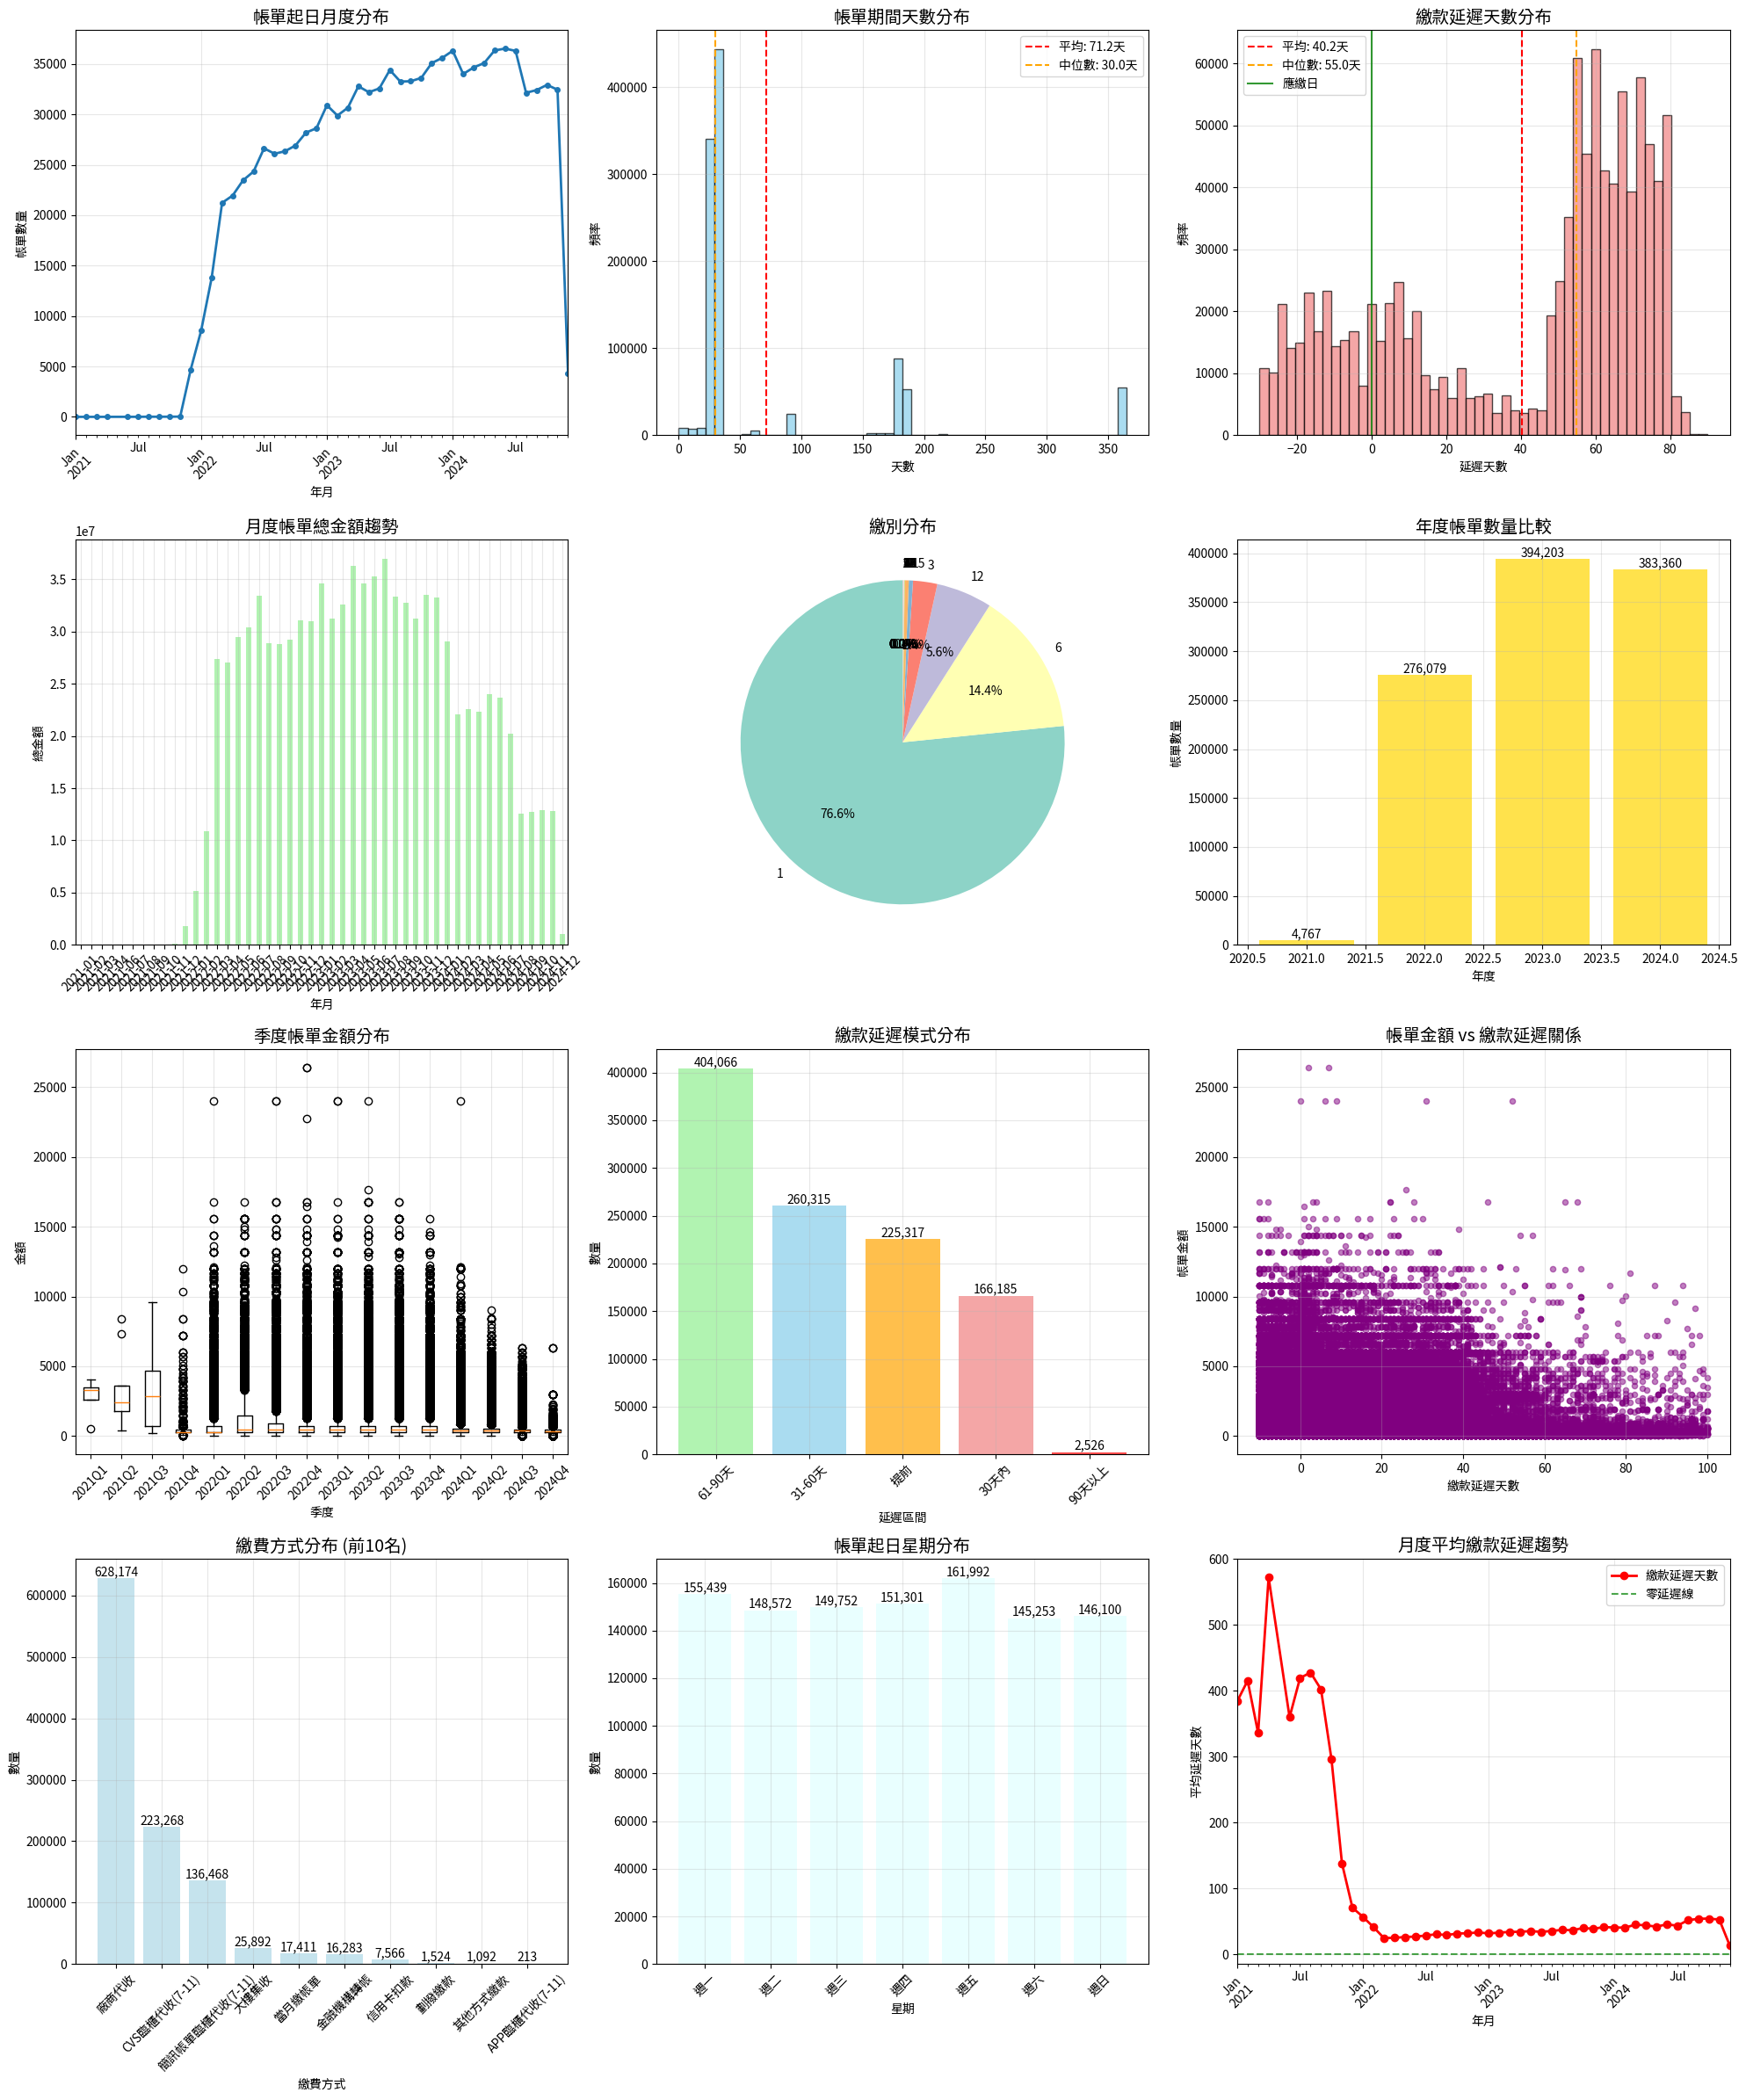


=== 帳務分析統計摘要 ===

📊 帳單基本統計:
帳單總數: 1,058,409
涉及客戶數: 119,630
資料時間範圍: 2021-01-22 ~ 2024-12-26

📈 帳單期間分析:
平均帳單期間: 73.3 天
帳單期間中位數: 30.0 天
最短帳單期間: 0 天
最長帳單期間: 822 天

💰 帳單金額分析:
總帳單金額: 936,422,684.00
平均帳單金額: 884.75
帳單金額中位數: 429.00
最大帳單金額: 26,388.00
最小帳單金額: 1.00

⏰ 繳款延遲分析:
有銷帳記錄的帳單數: 1,058,409
平均繳款延遲: 38.6 天
延遲中位數: 55.0 天
最大延遲: 1215 天
最小延遲: -60 天

繳款模式分布:
  提前繳款: 218,730 筆 (20.7%)
  準時繳款: 6,587 筆 (0.6%)
  延遲1-30天: 166,185 筆 (15.7%)
  延遲31-60天: 260,315 筆 (24.6%)
  延遲61-90天: 404,066 筆 (38.2%)
  延遲超過90天: 2,526 筆 (0.2%)

📅 時間分布分析:
年度統計:
  2021年: 4,767 筆, 總額 2,045,671.00, 平均 429.13
  2022年: 276,079 筆, 總額 312,866,999.00, 平均 1133.25
  2023年: 394,203 筆, 總額 405,611,760.00, 平均 1028.94
  2024年: 383,360 筆, 總額 215,898,254.00, 平均 563.17

✅ 帳務日期分析與視覺化完成!


In [43]:
import seaborn as sns
import numpy as np
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')


print("=== 帳務日期分析與視覺化 ===")

# 1. 載入並準備資料
bill_data = ds_bill_corrected.copy()

# 確保日期格式正確
date_columns = ['帳單起日', '帳單迄日', '銷帳日期']
for col in date_columns:
    if col in bill_data.columns:
        bill_data[col] = pd.to_datetime(bill_data[col], errors='coerce')

# 計算衍生指標
bill_data['帳單期間天數'] = (bill_data['帳單迄日'] - bill_data['帳單起日']).dt.days
bill_data['繳款延遲天數'] = (bill_data['銷帳日期'] - bill_data['帳單起日']).dt.days
bill_data['年月'] = bill_data['帳單起日'].dt.to_period('M')
bill_data['年'] = bill_data['帳單起日'].dt.year
bill_data['月'] = bill_data['帳單起日'].dt.month
bill_data['季度'] = bill_data['帳單起日'].dt.quarter

# 篩選有效資料
valid_data = bill_data.dropna(subset=['帳單起日', '帳單迄日'])
payment_data = bill_data.dropna(subset=['帳單起日', '銷帳日期'])

print(f"總記錄數: {len(bill_data):,}")
print(f"有效帳單記錄數: {len(valid_data):,}")
print(f"有效付款記錄數: {len(payment_data):,}")

# 2. 建立視覺化圖表
fig = plt.figure(figsize=(20, 24))

# 2.1 帳單起日時間分布
plt.subplot(4, 3, 1)
monthly_counts = bill_data.groupby('年月').size()
monthly_counts.plot(kind='line', marker='o', linewidth=2, markersize=4)
plt.title('帳單起日月度分布', fontsize=14, fontweight='bold')
plt.xlabel('年月')
plt.ylabel('帳單數量')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# 2.2 帳單期間天數分布
plt.subplot(4, 3, 2)
valid_periods = valid_data['帳單期間天數']
valid_periods_filtered = valid_periods[(valid_periods >= 0) & (valid_periods <= 365)]
plt.hist(valid_periods_filtered, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
plt.axvline(valid_periods_filtered.mean(), color='red', linestyle='--', 
           label=f'平均: {valid_periods_filtered.mean():.1f}天')
plt.axvline(valid_periods_filtered.median(), color='orange', linestyle='--', 
           label=f'中位數: {valid_periods_filtered.median():.1f}天')
plt.title('帳單期間天數分布', fontsize=14, fontweight='bold')
plt.xlabel('天數')
plt.ylabel('頻率')
plt.legend()
plt.grid(True, alpha=0.3)

# 2.3 繳款延遲天數分布
plt.subplot(4, 3, 3)
delay_days = payment_data['繳款延遲天數']
delay_days_filtered = delay_days[(delay_days >= -30) & (delay_days <= 90)]
plt.hist(delay_days_filtered, bins=50, alpha=0.7, color='lightcoral', edgecolor='black')
plt.axvline(delay_days_filtered.mean(), color='red', linestyle='--', 
           label=f'平均: {delay_days_filtered.mean():.1f}天')
plt.axvline(delay_days_filtered.median(), color='orange', linestyle='--', 
           label=f'中位數: {delay_days_filtered.median():.1f}天')
plt.axvline(0, color='green', linestyle='-', alpha=0.8, label='應繳日')
plt.title('繳款延遲天數分布', fontsize=14, fontweight='bold')
plt.xlabel('延遲天數')
plt.ylabel('頻率')
plt.legend()
plt.grid(True, alpha=0.3)

# 2.4 月度帳單金額趨勢
plt.subplot(4, 3, 4)
monthly_amount = bill_data.groupby('年月')['金額'].agg(['sum', 'mean'])
monthly_amount['sum'].plot(kind='bar', alpha=0.7, color='lightgreen')
plt.title('月度帳單總金額趨勢', fontsize=14, fontweight='bold')
plt.xlabel('年月')
plt.ylabel('總金額')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# 2.5 繳別分布
plt.subplot(4, 3, 5)
payment_type_counts = bill_data['繳別'].value_counts()
plt.pie(payment_type_counts.values, labels=payment_type_counts.index, autopct='%1.1f%%', 
        startangle=90, colors=plt.cm.Set3.colors)
plt.title('繳別分布', fontsize=14, fontweight='bold')

# 2.6 年度帳單數量比較
plt.subplot(4, 3, 6)
yearly_counts = bill_data.groupby('年').size()
bars = plt.bar(yearly_counts.index, yearly_counts.values, alpha=0.7, color='gold')
plt.title('年度帳單數量比較', fontsize=14, fontweight='bold')
plt.xlabel('年度')
plt.ylabel('帳單數量')
# 在柱狀圖上顯示數值
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height):,}', ha='center', va='bottom')
plt.grid(True, alpha=0.3)

# 2.7 季度帳單金額箱型圖
plt.subplot(4, 3, 7)
season_data = []
season_labels = []
for year in bill_data['年'].unique():
    for quarter in [1, 2, 3, 4]:
        quarter_data = bill_data[(bill_data['年'] == year) & (bill_data['季度'] == quarter)]['金額']
        if len(quarter_data) > 0:
            season_data.append(quarter_data)
            season_labels.append(f'{year}Q{quarter}')

if season_data:
    plt.boxplot(season_data, labels=season_labels)
plt.title('季度帳單金額分布', fontsize=14, fontweight='bold')
plt.xlabel('季度')
plt.ylabel('金額')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# 2.8 延遲支付模式分析
plt.subplot(4, 3, 8)
delay_categories = pd.cut(payment_data['繳款延遲天數'], 
                         bins=[-np.inf, 0, 30, 60, 90, np.inf],
                         labels=['提前', '30天內', '31-60天', '61-90天', '90天以上'])
delay_counts = delay_categories.value_counts()
colors = ['lightgreen', 'skyblue', 'orange', 'lightcoral', 'red']
bars = plt.bar(delay_counts.index, delay_counts.values, color=colors, alpha=0.7)
plt.title('繳款延遲模式分布', fontsize=14, fontweight='bold')
plt.xlabel('延遲區間')
plt.ylabel('數量')
plt.xticks(rotation=45)
# 在柱狀圖上顯示數值
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height):,}', ha='center', va='bottom')
plt.grid(True, alpha=0.3)

# 2.9 帳單金額與延遲天數散布圖
plt.subplot(4, 3, 9)
scatter_data = payment_data[(payment_data['繳款延遲天數'] >= -10) & 
                           (payment_data['繳款延遲天數'] <= 100)]
plt.scatter(scatter_data['繳款延遲天數'], scatter_data['金額'], 
           alpha=0.5, s=20, color='purple')
plt.xlabel('繳款延遲天數')
plt.ylabel('帳單金額')
plt.title('帳單金額 vs 繳款延遲關係', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# 2.10 繳費方式分布
plt.subplot(4, 3, 10)
if '繳費方式' in bill_data.columns:
    payment_method_counts = bill_data['繳費方式'].value_counts().head(10)
    bars = plt.bar(range(len(payment_method_counts)), payment_method_counts.values, 
                   alpha=0.7, color='lightblue')
    plt.title('繳費方式分布 (前10名)', fontsize=14, fontweight='bold')
    plt.xlabel('繳費方式')
    plt.ylabel('數量')
    plt.xticks(range(len(payment_method_counts)), payment_method_counts.index, rotation=45)
    # 在柱狀圖上顯示數值
    for i, bar in enumerate(bars):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                 f'{int(height):,}', ha='center', va='bottom')
    plt.grid(True, alpha=0.3)

# 2.11 帳單週期分析（一週中的分布）
plt.subplot(4, 3, 11)
bill_data['weekday'] = bill_data['帳單起日'].dt.day_name()
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_counts = bill_data['weekday'].value_counts().reindex(weekday_order)
chinese_weekdays = ['週一', '週二', '週三', '週四', '週五', '週六', '週日']
bars = plt.bar(chinese_weekdays, weekday_counts.values, alpha=0.7, color='lightcyan')
plt.title('帳單起日星期分布', fontsize=14, fontweight='bold')
plt.xlabel('星期')
plt.ylabel('數量')
plt.xticks(rotation=45)
# 在柱狀圖上顯示數值
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height):,}', ha='center', va='bottom')
plt.grid(True, alpha=0.3)

# 2.12 月度平均延遲趨勢
plt.subplot(4, 3, 12)
monthly_delay = payment_data.groupby('年月')['繳款延遲天數'].mean()
monthly_delay.plot(kind='line', marker='o', linewidth=2, markersize=6, color='red')
plt.title('月度平均繳款延遲趨勢', fontsize=14, fontweight='bold')
plt.xlabel('年月')
plt.ylabel('平均延遲天數')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='green', linestyle='--', alpha=0.7, label='零延遲線')
plt.legend()

plt.tight_layout()
plt.show()

# 3. 統計摘要報告
print(f"\n=== 帳務分析統計摘要 ===")

print(f"\n📊 帳單基本統計:")
print(f"帳單總數: {len(bill_data):,}")
print(f"涉及客戶數: {bill_data['客編'].nunique():,}")
print(f"資料時間範圍: {bill_data['帳單起日'].min().strftime('%Y-%m-%d')} ~ {bill_data['帳單起日'].max().strftime('%Y-%m-%d')}")

print(f"\n📈 帳單期間分析:")
if len(valid_data) > 0:
    print(f"平均帳單期間: {valid_data['帳單期間天數'].mean():.1f} 天")
    print(f"帳單期間中位數: {valid_data['帳單期間天數'].median():.1f} 天")
    print(f"最短帳單期間: {valid_data['帳單期間天數'].min()} 天")
    print(f"最長帳單期間: {valid_data['帳單期間天數'].max()} 天")

print(f"\n💰 帳單金額分析:")
print(f"總帳單金額: {bill_data['金額'].sum():,.2f}")
print(f"平均帳單金額: {bill_data['金額'].mean():.2f}")
print(f"帳單金額中位數: {bill_data['金額'].median():.2f}")
print(f"最大帳單金額: {bill_data['金額'].max():,.2f}")
print(f"最小帳單金額: {bill_data['金額'].min():.2f}")

print(f"\n⏰ 繳款延遲分析:")
if len(payment_data) > 0:
    print(f"有銷帳記錄的帳單數: {len(payment_data):,}")
    print(f"平均繳款延遲: {payment_data['繳款延遲天數'].mean():.1f} 天")
    print(f"延遲中位數: {payment_data['繳款延遲天數'].median():.1f} 天")
    print(f"最大延遲: {payment_data['繳款延遲天數'].max()} 天")
    print(f"最小延遲: {payment_data['繳款延遲天數'].min()} 天")
    
    # 延遲分布統計
    early_payment = (payment_data['繳款延遲天數'] < 0).sum()
    on_time = (payment_data['繳款延遲天數'] == 0).sum()
    late_30 = ((payment_data['繳款延遲天數'] > 0) & (payment_data['繳款延遲天數'] <= 30)).sum()
    late_60 = ((payment_data['繳款延遲天數'] > 30) & (payment_data['繳款延遲天數'] <= 60)).sum()
    late_90 = ((payment_data['繳款延遲天數'] > 60) & (payment_data['繳款延遲天數'] <= 90)).sum()
    very_late = (payment_data['繳款延遲天數'] > 90).sum()
    
    print(f"\n繳款模式分布:")
    print(f"  提前繳款: {early_payment:,} 筆 ({early_payment/len(payment_data)*100:.1f}%)")
    print(f"  準時繳款: {on_time:,} 筆 ({on_time/len(payment_data)*100:.1f}%)")
    print(f"  延遲1-30天: {late_30:,} 筆 ({late_30/len(payment_data)*100:.1f}%)")
    print(f"  延遲31-60天: {late_60:,} 筆 ({late_60/len(payment_data)*100:.1f}%)")
    print(f"  延遲61-90天: {late_90:,} 筆 ({late_90/len(payment_data)*100:.1f}%)")
    print(f"  延遲超過90天: {very_late:,} 筆 ({very_late/len(payment_data)*100:.1f}%)")

print(f"\n📅 時間分布分析:")
yearly_stats = bill_data.groupby('年').agg({
    '帳單起日': 'count',
    '金額': ['sum', 'mean']
}).round(2)
print("年度統計:")
for year in yearly_stats.index:
    count = yearly_stats.loc[year, ('帳單起日', 'count')]
    total_amount = yearly_stats.loc[year, ('金額', 'sum')]
    avg_amount = yearly_stats.loc[year, ('金額', 'mean')]
    print(f"  {year}年: {count:,} 筆, 總額 {total_amount:,.2f}, 平均 {avg_amount:.2f}")

print(f"\n✅ 帳務日期分析與視覺化完成!")

In [44]:
ds_bill_corrected.to_csv('bill_22_24_dateCorrected.csv', index=False, sep='^')

In [1]:
import pandas as pd
# 載入資料
ds_bill = pd.read_csv('bill_22_24_dateCorrected.csv',sep='^')

In [2]:
ds_bill.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1058409 entries, 0 to 1058408
Data columns (total 8 columns):
 #   Column  Non-Null Count    Dtype 
---  ------  --------------    ----- 
 0   客編      1058409 non-null  int64 
 1   相關編號    1058409 non-null  int64 
 2   帳單起日    1058409 non-null  object
 3   帳單迄日    1058409 non-null  object
 4   金額      1058409 non-null  int64 
 5   銷帳日期    1058409 non-null  object
 6   繳別      1058409 non-null  int64 
 7   繳費方式    1058409 non-null  object
dtypes: int64(4), object(4)
memory usage: 64.6+ MB


In [3]:
# 檢查 ds_bill 中帳單迄日的空值情況
print("=== ds_bill 帳單迄日空值檢查 ===")

if 'ds_bill' in locals() or 'ds_bill' in globals():
    # 檢查帳單迄日欄位是否存在
    if '帳單迄日' in ds_bill.columns:
        null_count = ds_bill['帳單迄日'].isnull().sum()
        total_count = len(ds_bill)
        not_null_count = ds_bill['帳單迄日'].notnull().sum()
        
        print(f"ds_bill 總筆數: {total_count:,}")
        print(f"帳單迄日為空值: {null_count:,}")
        print(f"帳單迄日有值: {not_null_count:,}")
        print(f"空值比例: {null_count/total_count*100:.2f}%")
        
        # 顯示帳單迄日的基本資訊
        print(f"\n帳單迄日欄位資料型態: {ds_bill['帳單迄日'].dtype}")
        
        # 如果有非空值，顯示樣本
        if not_null_count > 0:
            print(f"\n帳單迄日樣本 (前5筆非空值):")
            non_null_samples = ds_bill['帳單迄日'].dropna().head(5)
            for i, sample in enumerate(non_null_samples):
                print(f"  {i+1}: {sample}")
        
    else:
        print("❌ ds_bill 中找不到'帳單迄日'欄位")
        print(f"可用欄位: {list(ds_bill.columns)}")
else:
    print("❌ 找不到 ds_bill 變數")
    print("可用的相關變數:")
    
    # 檢查其他可能的帳單資料變數
    possible_vars = ['ds_bill_filtered', 'ds_bill_filtered_by_dataset', 'bill', 'ds_bill_corrected']
    for var_name in possible_vars:
        if var_name in locals() or var_name in globals():
            var_data = eval(var_name)
            if hasattr(var_data, 'columns') and '帳單迄日' in var_data.columns:
                null_count = var_data['帳單迄日'].isnull().sum()
                total_count = len(var_data)
                print(f"  {var_name}: 總筆數={total_count:,}, 帳單迄日空值={null_count:,}")

=== ds_bill 帳單迄日空值檢查 ===
ds_bill 總筆數: 1,058,409
帳單迄日為空值: 0
帳單迄日有值: 1,058,409
空值比例: 0.00%

帳單迄日欄位資料型態: object

帳單迄日樣本 (前5筆非空值):
  1: 2022-02-06
  2: 2022-09-14
  3: 2022-10-16
  4: 2022-01-31
  5: 2022-07-16


In [4]:
ds_bill.head()
bill = ds_bill.copy()

In [5]:
# 更穩健的多日期欄位轉換方法

import pandas as pd
import numpy as np
from datetime import datetime
import re

print("=== 更穩健的多日期欄位轉換 ===")

# 1. 檢查原始日期欄位資料
date_columns = ['帳單起日', '帳單迄日', '銷帳日期']
print("轉換前各日期欄位狀態檢查：")

for col in date_columns:
    if col in bill.columns:
        print(f"\n{col}:")
        print(f"  資料型態: {bill[col].dtype}")
        print(f"  總筆數: {len(bill):,}")
        print(f"  非空值筆數: {bill[col].notna().sum():,}")
        print(f"  空值筆數: {bill[col].isna().sum():,}")
        
        # 顯示樣本
        non_null_samples = bill[col].dropna().head(10)
        if len(non_null_samples) > 0:
            print(f"  樣本 (前10筆非空值):")
            for i, sample in enumerate(non_null_samples):
                print(f"    {i+1:2d}: '{sample}' (type: {type(sample)})")

# 2. 建立統一的日期解析函數
def robust_date_parser_multi(date_str):
    """
    更穩健的日期解析函數，處理多種格式
    """
    if pd.isna(date_str) or date_str == '' or str(date_str).strip() == '':
        return pd.NaT
    
    # 轉為字串並清理
    date_str = str(date_str).strip()
    
    # 如果已經是日期型態，直接返回
    if isinstance(date_str, (pd.Timestamp, datetime)):
        return pd.Timestamp(date_str)
    
    # 定義中文月份映射
    chinese_month_map = {
        '1月': '01', '2月': '02', '3月': '03', '4月': '04',
        '5月': '05', '6月': '06', '7月': '07', '8月': '08',
        '9月': '09', '10月': '10', '11月': '11', '12月': '12'
    }
    
    # 步驟1: 處理中文月份
    original_str = date_str
    for cn_month, num_month in chinese_month_map.items():
        if cn_month in date_str:
            date_str = date_str.replace(cn_month, f'-{num_month}-')
            break
    
    # 清理多餘的連字符
    date_str = re.sub(r'-+', '-', date_str)
    
    # 步驟2: 嘗試不同的日期格式
    formats_to_try = [
        # 標準格式
        '%Y-%m-%d %H:%M:%S.%f',
        '%Y-%m-%d %H:%M:%S',
        '%Y-%m-%d',
        '%Y/%m/%d %H:%M:%S',
        '%Y/%m/%d',
        
        # 中文月份轉換後的格式
        '%d-%m-%y',      # 處理 18-01-24
        '%d-%m-%Y',      # 處理 18-01-2024
        
        # 帶空格的格式
        '%d %m %y',      # 18 01 24
        '%d %m %Y',      # 18 01 2024
        
        # 英文月份格式
        '%d-%b-%y',      # 18-Jan-24
        '%d-%b -%y',     # 18-Jan -24 (帶空格)
        '%d-%b-%Y',      # 18-Jan-2024
        '%d %b %y',      # 18 Jan 24
        '%d %b %Y',      # 18 Jan 2024
        
        # 其他常見格式
        '%d/%m/%Y',      # 18/01/2024
        '%d/%m/%y',      # 18/01/24
        '%Y%m%d',        # 20240118
        '%d-%m-%Y %H:%M:%S',
        '%d/%m/%Y %H:%M:%S',
    ]
    
    # 嘗試解析
    for fmt in formats_to_try:
        try:
            parsed_date = pd.to_datetime(date_str, format=fmt, errors='raise')
            
            # 檢查年份合理性 (1900-2030)
            if 1900 <= parsed_date.year <= 2030:
                return parsed_date
                
        except (ValueError, TypeError):
            continue
    
    # 步驟3: 嘗試自動推斷（最後手段）
    try:
        parsed_date = pd.to_datetime(date_str, infer_datetime_format=True, errors='raise')
        if 1900 <= parsed_date.year <= 2030:
            return parsed_date
    except:
        pass
    
    # 步驟4: 處理特殊格式（手動解析）
    try:
        # 處理 dd-mm-yy 格式但年份需要調整
        if re.match(r'^\d{1,2}-\d{1,2}-\d{2}$', date_str):
            parts = date_str.split('-')
            day, month, year = parts[0], parts[1], parts[2]
            
            # 年份處理邏輯
            year_int = int(year)
            if year_int <= 30:  # 00-30 視為 2000-2030
                year_int += 2000
            elif year_int <= 99:  # 31-99 視為 1931-1999
                year_int += 1900
            
            try:
                return pd.Timestamp(year=year_int, month=int(month), day=int(day))
            except:
                pass
    except:
        pass
    
    print(f"    ⚠️ 無法解析日期: '{original_str}' -> '{date_str}'")
    return pd.NaT

# 3. 建立副本進行安全轉換
bill_safe = bill.copy()

print(f"\n=== 開始穩健轉換所有日期欄位 ===")

# 轉換統計
conversion_stats = {}

# 4. 逐一轉換各日期欄位
for col in date_columns:
    if col not in bill_safe.columns:
        print(f"⚠️ 欄位 '{col}' 不存在，跳過")
        continue
    
    print(f"\n正在轉換 {col}...")
    
    # 統計轉換前狀態
    original_not_null = bill_safe[col].notna().sum()
    
    # 應用穩健解析函數
    converted_dates = bill_safe[col].apply(robust_date_parser_multi)
    
    # 統計轉換結果
    converted_not_null = converted_dates.notna().sum()
    conversion_failures = original_not_null - converted_not_null
    
    conversion_stats[col] = {
        'original_not_null': original_not_null,
        'converted_not_null': converted_not_null,
        'conversion_failures': conversion_failures,
        'success_rate': converted_not_null/max(original_not_null, 1)*100
    }
    
    # 更新欄位
    bill_safe[col] = converted_dates
    
    print(f"  原始非空值數: {original_not_null:,}")
    print(f"  轉換後非空值數: {converted_not_null:,}")
    print(f"  轉換失敗數: {conversion_failures:,}")
    print(f"  轉換成功率: {converted_not_null/max(original_not_null, 1)*100:.2f}%")

# 5. 顯示轉換結果統計表
print(f"\n=== 轉換結果統計表 ===")
stats_df = pd.DataFrame.from_dict(conversion_stats, orient='index')
stats_df['success_rate'] = stats_df['success_rate'].round(2)
print(stats_df)

# 6. 顯示轉換後的樣本
print(f"\n=== 轉換後樣本檢查 ===")
for col in date_columns:
    if col in bill_safe.columns:
        print(f"\n{col} 轉換後格式: {bill_safe[col].dtype}")
        success_samples = bill_safe[col].dropna().head(5)
        if len(success_samples) > 0:
            print(f"{col} 成功轉換樣本:")
            for i, date in enumerate(success_samples):
                print(f"  {i+1}: {date}")

# 7. 日期範圍檢查
print(f"\n=== 日期範圍檢查 ===")
for col in date_columns:
    if col in bill_safe.columns:
        valid_dates = bill_safe[col].dropna()
        if len(valid_dates) > 0:
            print(f"\n{col} 日期範圍: {valid_dates.min()} ~ {valid_dates.max()}")
            
            # 年份分布
            year_counts = valid_dates.dt.year.value_counts().sort_index()
            print(f"{col} 年份分布:")
            for year, count in year_counts.head(10).items():
                print(f"  {year}: {count:,} 筆")
            
            # 檢查異常年份
            current_year = datetime.now().year
            future_dates = valid_dates[valid_dates.dt.year > current_year]
            old_dates = valid_dates[valid_dates.dt.year < 1990]
            
            if len(future_dates) > 0:
                print(f"  ⚠️ 發現 {len(future_dates)} 筆未來日期")
            if len(old_dates) > 0:
                print(f"  ⚠️ 發現 {len(old_dates)} 筆過舊日期 (1990年前)")

# 8. 邏輯性檢查
print(f"\n=== 日期邏輯性檢查 ===")

# 檢查帳單起日與帳單迄日的關係
if '帳單起日' in bill_safe.columns and '帳單迄日' in bill_safe.columns:
    both_valid = bill_safe.dropna(subset=['帳單起日', '帳單迄日'])
    if len(both_valid) > 0:
        bill_period = (both_valid['帳單迄日'] - both_valid['帳單起日']).dt.days
        
        print(f"帳單起日與帳單迄日邏輯檢查:")
        print(f"  有效記錄數: {len(both_valid):,}")
        print(f"  平均帳單期間: {bill_period.mean():.1f} 天")
        print(f"  帳單期間範圍: {bill_period.min()} ~ {bill_period.max()} 天")
        
        # 檢查異常
        negative_period = (bill_period < 0).sum()
        if negative_period > 0:
            print(f"  ⚠️ {negative_period:,} 筆帳單迄日早於帳單起日")

# 檢查銷帳日期與帳單起日的關係
if '銷帳日期' in bill_safe.columns and '帳單起日' in bill_safe.columns:
    both_valid = bill_safe.dropna(subset=['帳單起日', '銷帳日期'])
    if len(both_valid) > 0:
        delay_days = (both_valid['銷帳日期'] - both_valid['帳單起日']).dt.days
        
        print(f"\n銷帳日期與帳單起日邏輯檢查:")
        print(f"  有效記錄數: {len(both_valid):,}")
        print(f"  平均繳款延遲: {delay_days.mean():.1f} 天")
        print(f"  延遲天數範圍: {delay_days.min()} ~ {delay_days.max()} 天")
        
        # 檢查異常延遲
        early_payment = (delay_days < 0).sum()
        very_late_payment = (delay_days > 365).sum()
        
        if early_payment > 0:
            print(f"  ⚠️ {early_payment:,} 筆銷帳日期早於帳單起日")
        if very_late_payment > 0:
            print(f"  ⚠️ {very_late_payment:,} 筆延遲超過1年")

# 9. 找出各欄位的轉換失敗記錄
print(f"\n=== 轉換失敗記錄分析 ===")
for col in date_columns:
    if col in bill_safe.columns:
        failed_mask = bill[col].notna() & bill_safe[col].isna()
        failed_records = bill[failed_mask]
        
        if len(failed_records) > 0:
            print(f"\n{col} 轉換失敗記錄 (前5筆):")
            for i, (idx, row) in enumerate(failed_records.head(5).iterrows()):
                original_value = row[col]
                print(f"  {i+1}: 索引={idx}, 原值='{original_value}' (type: {type(original_value)})")

# 10. 最終確認和更新
print(f"\n=== 最終轉換總結 ===")
total_failures = sum([stats['conversion_failures'] for stats in conversion_stats.values()])
total_original = sum([stats['original_not_null'] for stats in conversion_stats.values()])

if total_failures == 0:
    print(f"✅ 所有日期欄位轉換完全成功！")
elif total_failures < total_original * 0.05:  # 總失敗率小於5%
    print(f"✅ 日期轉換大致成功，總失敗率: {total_failures/total_original*100:.2f}%")
else:
    print(f"⚠️ 日期轉換總失敗率較高: {total_failures/total_original*100:.2f}%")
    print("建議檢查失敗記錄並調整解析邏輯")

# 更新原始變數
bill = bill_safe.copy()
print(f"\n✅ bill 變數已更新為轉換後的資料")

# 顯示最終格式
print(f"\n=== 最終日期欄位格式 ===")
for col in date_columns:
    if col in bill.columns:
        print(f"{col}: {bill[col].dtype}")
        valid_count = bill[col].notna().sum()
        print(f"  有效日期數: {valid_count:,}")

print(f"\n🎯 多日期欄位穩健轉換作業完成！")

=== 更穩健的多日期欄位轉換 ===
轉換前各日期欄位狀態檢查：

帳單起日:
  資料型態: object
  總筆數: 1,058,409
  非空值筆數: 1,058,409
  空值筆數: 0
  樣本 (前10筆非空值):
     1: '2021-08-07' (type: <class 'str'>)
     2: '2021-09-15' (type: <class 'str'>)
     3: '2021-10-17' (type: <class 'str'>)
     4: '2021-11-12' (type: <class 'str'>)
     5: '2021-12-17' (type: <class 'str'>)
     6: '2021-12-12' (type: <class 'str'>)
     7: '2021-12-30' (type: <class 'str'>)
     8: '2021-12-01' (type: <class 'str'>)
     9: '2021-12-21' (type: <class 'str'>)
    10: '2021-12-01' (type: <class 'str'>)

帳單迄日:
  資料型態: object
  總筆數: 1,058,409
  非空值筆數: 1,058,409
  空值筆數: 0
  樣本 (前10筆非空值):
     1: '2022-02-06' (type: <class 'str'>)
     2: '2022-09-14' (type: <class 'str'>)
     3: '2022-10-16' (type: <class 'str'>)
     4: '2022-01-31' (type: <class 'str'>)
     5: '2022-07-16' (type: <class 'str'>)
     6: '2022-01-11' (type: <class 'str'>)
     7: '2022-01-06' (type: <class 'str'>)
     8: '2022-05-31' (type: <class 'str'>)
     9: '2022-07-10' (ty

In [6]:
bill.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1058409 entries, 0 to 1058408
Data columns (total 8 columns):
 #   Column  Non-Null Count    Dtype         
---  ------  --------------    -----         
 0   客編      1058409 non-null  int64         
 1   相關編號    1058409 non-null  int64         
 2   帳單起日    1058409 non-null  datetime64[ns]
 3   帳單迄日    1058409 non-null  datetime64[ns]
 4   金額      1058409 non-null  int64         
 5   銷帳日期    1058409 non-null  datetime64[ns]
 6   繳別      1058409 non-null  int64         
 7   繳費方式    1058409 non-null  object        
dtypes: datetime64[ns](3), int64(4), object(1)
memory usage: 64.6+ MB


In [7]:
print("=== 篩選保留帳單迄日落於2024年的資料 ===")

# 1. 檢查篩選前的資料狀態
print("篩選前資料狀態:")
print(f"bill 總筆數: {len(bill):,}")
print(f"帳單迄日格式: {bill['帳單迄日'].dtype}")

# 確認帳單迄日是否為 datetime 格式
if not pd.api.types.is_datetime64_any_dtype(bill['帳單迄日']):
    print("轉換帳單迄日為 datetime 格式...")
    bill['帳單迄日'] = pd.to_datetime(bill['帳單迄日'], errors='coerce')

# 2. 檢查帳單迄日的時間範圍
valid_end_dates = bill['帳單迄日'].dropna()
if len(valid_end_dates) > 0:
    print(f"\n篩選前帳單迄日範圍:")
    print(f"最早帳單迄日: {valid_end_dates.min()}")
    print(f"最晚帳單迄日: {valid_end_dates.max()}")
    
    # 年份分布統計
    year_distribution = valid_end_dates.dt.year.value_counts().sort_index()
    print(f"\n篩選前年份分布:")
    for year, count in year_distribution.items():
        print(f"  {year}年: {count:,} 筆")

# 3. 建立篩選條件：帳單迄日在2024年
print(f"\n=== 建立2024年篩選條件 ===")

# 方法1: 使用年份篩選
# condition_2024 = bill['帳單迄日'].dt.year == 2024

# 方法2: 使用日期範圍篩選（更精確）
condition_2024 = (bill['帳單迄日'] >= pd.Timestamp('2024-07-01')) & (bill['帳單迄日'] <= pd.Timestamp('2024-12-31'))

# 4. 應用篩選條件
bill_2024 = bill[condition_2024].copy()

# 5. 統計篩選結果
original_count = len(bill)
filtered_count = len(bill_2024)
removed_count = original_count - filtered_count

print(f"\n=== 篩選結果統計 ===")
print(f"篩選前總筆數: {original_count:,}")
print(f"篩選後保留筆數: {filtered_count:,}")
print(f"刪除筆數: {removed_count:,}")
print(f"保留比例: {filtered_count/original_count*100:.2f}%")
print(f"刪除比例: {removed_count/original_count*100:.2f}%")

# 6. 驗證篩選結果
print(f"\n=== 驗證篩選結果 ===")
if len(bill_2024) > 0:
    # 檢查篩選後的年份分布
    filtered_end_dates = bill_2024['帳單迄日'].dropna()
    if len(filtered_end_dates) > 0:
        filtered_year_dist = filtered_end_dates.dt.year.value_counts().sort_index()
        print(f"篩選後年份分布:")
        for year, count in filtered_year_dist.items():
            print(f"  {year}年: {count:,} 筆")
        
        # 確認只有2024年
        unique_years = filtered_end_dates.dt.year.unique()
        if len(unique_years) == 1 and unique_years[0] == 2024:
            print("✅ 篩選成功：所有記錄的帳單迄日都在2024年")
        else:
            print(f"⚠️ 篩選異常：發現其他年份 {unique_years}")
        
        # 顯示2024年的月份分布
        print(f"\n2024年月份分布:")
        month_dist = filtered_end_dates.dt.month.value_counts().sort_index()
        month_names = ['1月', '2月', '3月', '4月', '5月', '6月', 
                      '7月', '8月', '9月', '10月', '11月', '12月']
        for month, count in month_dist.items():
            print(f"  {month_names[month-1]}: {count:,} 筆")
    
    # 7. 顯示篩選後的樣本資料
    print(f"\n=== 篩選後資料樣本 (前10筆) ===")
    display_cols = ['客編', '相關編號', '帳單起日', '帳單迄日', '金額', '銷帳日期']
    available_cols = [col for col in display_cols if col in bill_2024.columns]
    
    sample_data = bill_2024[available_cols].head(10)
    print(sample_data.to_string(index=False))
    
    # 8. 檢查其他日期欄位的影響
    print(f"\n=== 其他日期欄位檢查 ===")
    
    # 檢查帳單起日範圍
    if '帳單起日' in bill_2024.columns:
        valid_start_dates = bill_2024['帳單起日'].dropna()
        if len(valid_start_dates) > 0:
            print(f"帳單起日範圍: {valid_start_dates.min()} ~ {valid_start_dates.max()}")
            start_year_dist = valid_start_dates.dt.year.value_counts().sort_index()
            print(f"帳單起日年份分布:")
            for year, count in start_year_dist.items():
                print(f"  {year}年: {count:,} 筆")
    
    # 檢查銷帳日期範圍
    if '銷帳日期' in bill_2024.columns:
        valid_writeoff_dates = bill_2024['銷帳日期'].dropna()
        if len(valid_writeoff_dates) > 0:
            print(f"銷帳日期範圍: {valid_writeoff_dates.min()} ~ {valid_writeoff_dates.max()}")
            writeoff_year_dist = valid_writeoff_dates.dt.year.value_counts().sort_index()
            print(f"銷帳日期年份分布:")
            for year, count in writeoff_year_dist.items():
                print(f"  {year}年: {count:,} 筆")
    
    # 9. 分析被刪除的記錄
    if removed_count > 0:
        print(f"\n=== 被刪除記錄分析 ===")
        removed_records = bill[~condition_2024]
        
        # 被刪除記錄的年份分布
        removed_end_dates = removed_records['帳單迄日'].dropna()
        if len(removed_end_dates) > 0:
            removed_year_dist = removed_end_dates.dt.year.value_counts().sort_index()
            print(f"被刪除記錄的年份分布:")
            for year, count in removed_year_dist.items():
                print(f"  {year}年: {count:,} 筆")
        
        # 顯示被刪除記錄的樣本
        print(f"\n被刪除記錄樣本 (前5筆):")
        removed_sample = removed_records[available_cols].head(5)
        print(removed_sample.to_string(index=False))
        
        # 統計被刪除記錄的影響
        if '金額' in removed_records.columns:
            removed_amount = removed_records['金額'].sum()
            print(f"被刪除記錄總金額: {removed_amount:,.2f}")
        
        unique_customers_removed = removed_records['客編'].nunique()
        print(f"被刪除記錄涉及客編數: {unique_customers_removed:,}")

else:
    print("⚠️ 篩選後沒有任何記錄，請檢查篩選條件")

# 10. 重設索引
if len(bill_2024) > 0:
    bill_2024.reset_index(drop=True, inplace=True)
    print(f"\n📋 已重設索引")

# 11. 更新 bill 變數
bill = bill_2024.copy()
print(f"\n✅ bill 變數已更新為2024年帳單迄日的資料")

# 12. 最終確認
print(f"\n=== 最終確認 ===")
print(f"最終 bill 資料筆數: {len(bill):,}")
print(f"最終記憶體使用: {bill.memory_usage(deep=True).sum() / 1024 / 1024:.2f} MB")

if len(bill) > 0:
    final_end_dates = bill['帳單迄日'].dropna()
    if len(final_end_dates) > 0:
        print(f"最終帳單迄日範圍: {final_end_dates.min()} ~ {final_end_dates.max()}")
        # 確認所有帳單迄日都在2024年
        all_2024 = (final_end_dates.dt.year == 2024).all()
        print(f"確認所有帳單迄日都在2024年: {'✅ 是' if all_2024 else '❌ 否'}")

print(f"\n🎯 2024年帳單迄日資料篩選作業完成！")

=== 篩選保留帳單迄日落於2024年的資料 ===
篩選前資料狀態:
bill 總筆數: 1,058,409
帳單迄日格式: datetime64[ns]

篩選前帳單迄日範圍:
最早帳單迄日: 2022-01-01 00:00:00
最晚帳單迄日: 2024-12-31 00:00:00

篩選前年份分布:
  2022年: 210,551 筆
  2023年: 380,823 筆
  2024年: 467,035 筆

=== 建立2024年篩選條件 ===

=== 篩選結果統計 ===
篩選前總筆數: 1,058,409
篩選後保留筆數: 241,435
刪除筆數: 816,974
保留比例: 22.81%
刪除比例: 77.19%

=== 驗證篩選結果 ===
篩選後年份分布:
  2024年: 241,435 筆
✅ 篩選成功：所有記錄的帳單迄日都在2024年

2024年月份分布:
  7月: 39,825 筆
  8月: 39,522 筆
  9月: 39,967 筆
  10月: 40,533 筆
  11月: 41,359 筆
  12月: 40,229 筆

=== 篩選後資料樣本 (前10筆) ===
     客編    相關編號       帳單起日       帳單迄日   金額       銷帳日期
1107235 2314104 2022-07-22 2024-07-21 8400 2022-07-01
 823635  898337 2022-07-01 2024-09-30 2400 2022-07-20
 823636  898338 2022-07-01 2024-09-30 2400 2022-07-20
 823637  898339 2022-07-01 2024-09-30 2400 2022-07-20
 823638  898340 2022-07-01 2024-09-30 2400 2022-07-20
 823639  898341 2022-07-01 2024-09-30 2400 2022-07-20
 823640  898342 2022-07-01 2024-09-30 2400 2022-07-20
 823641  898343 2022-07-01 2024-09-30 2400 20

In [8]:
# 查詢 bill 中銷帳日期大於帳單起日超過60天的資料

print("=== 銷帳日期大於帳單起日超過60天的資料統計 ===")

# 1. 檢查資料基本狀態
print(f"bill 總筆數: {len(bill):,}")
print(f"帳單起日格式: {bill['帳單起日'].dtype}")
print(f"銷帳日期格式: {bill['銷帳日期'].dtype}")

# 2. 篩選有效記錄（兩個日期都不為空）
valid_records = bill.dropna(subset=['帳單起日', '銷帳日期'])
print(f"帳單起日和銷帳日期都有效的記錄數: {len(valid_records):,}")

if len(valid_records) > 0:
    # 3. 計算銷帳延遲天數
    delay_days = (valid_records['銷帳日期'] - valid_records['帳單起日']).dt.days
    
    # 4. 篩選超過60天的記錄
    over_60_days_condition = delay_days > 60
    over_60_days_records = valid_records[over_60_days_condition]
    over_60_days_count = len(over_60_days_records)
    
    print(f"\n=== 查詢結果 ===")
    print(f"銷帳日期大於帳單起日超過60天的資料數: {over_60_days_count:,} 筆")
    print(f"占有效記錄比例: {over_60_days_count/len(valid_records)*100:.2f}%")
    print(f"占總記錄比例: {over_60_days_count/len(bill)*100:.2f}%")
    
    # 5. 延遲天數統計分析
    if over_60_days_count > 0:
        over_60_delay_days = delay_days[over_60_days_condition]
        
        print(f"\n=== 超過60天記錄的延遲統計 ===")
        print(f"平均延遲天數: {over_60_delay_days.mean():.1f} 天")
        print(f"最小延遲天數: {over_60_delay_days.min()} 天")
        print(f"最大延遲天數: {over_60_delay_days.max()} 天")
        print(f"中位數延遲天數: {over_60_delay_days.median():.1f} 天")
        print(f"標準差: {over_60_delay_days.std():.1f} 天")
        
        # 6. 延遲天數區間分布
        print(f"\n=== 延遲天數區間分布 ===")
        ranges = [
            (61, 90, "61-90天"),
            (91, 180, "91-180天"),
            (181, 365, "181-365天"),
            (366, float('inf'), "超過1年")
        ]
        
        for min_days, max_days, label in ranges:
            if max_days == float('inf'):
                range_count = (over_60_delay_days >= min_days).sum()
            else:
                range_count = ((over_60_delay_days >= min_days) & (over_60_delay_days <= max_days)).sum()
            
            if range_count > 0:
                print(f"  {label}: {range_count:,} 筆 ({range_count/over_60_days_count*100:.1f}%)")
        
        # 7. 顯示樣本記錄
        print(f"\n=== 超過60天記錄樣本 (前10筆) ===")
        display_cols = ['客編', '相關編號', '帳單起日', '銷帳日期', '金額', '繳費方式']
        available_cols = [col for col in display_cols if col in over_60_days_records.columns]
        
        sample_records = over_60_days_records[available_cols].head(10).copy()
        if len(sample_records) > 0:
            # 加入延遲天數欄位
            sample_indices = sample_records.index
            sample_records['延遲天數'] = delay_days[sample_indices]
            
            print(sample_records.to_string(index=False))
        
        # 8. 客編統計
        unique_customers = over_60_days_records['客編'].nunique()
        print(f"\n=== 客編統計 ===")
        print(f"涉及的唯一客編數: {unique_customers:,}")
        
        # 延遲最多的客編
        customer_delay_stats = over_60_days_records.groupby('客編').agg({
            '銷帳日期': 'count',  # 記錄數
        }).rename(columns={'銷帳日期': '超過60天記錄數'})
        
        # 加入平均延遲天數
        customer_avg_delay = over_60_days_records.groupby('客編').apply(
            lambda x: ((x['銷帳日期'] - x['帳單起日']).dt.days).mean()
        ).rename('平均延遲天數')
        
        customer_delay_stats = customer_delay_stats.join(customer_avg_delay)
        customer_delay_stats = customer_delay_stats.sort_values('平均延遲天數', ascending=False)
        
        print(f"\n延遲最嚴重的客編 (前10名):")
        print(customer_delay_stats.head(10).to_string())
        
    else:
        print("✅ 沒有銷帳日期大於帳單起日超過60天的記錄")
    
    # 9. 總體延遲天數分布概覽
    print(f"\n=== 總體延遲天數分布概覽 ===")
    print(f"所有有效記錄的延遲天數統計:")
    print(f"  平均延遲: {delay_days.mean():.1f} 天")
    print(f"  中位數延遲: {delay_days.median():.1f} 天")
    print(f"  最大延遲: {delay_days.max()} 天")
    print(f"  最小延遲: {delay_days.min()} 天")
    
    # 延遲分布區間
    delay_ranges = [
        (-float('inf'), 0, "提前繳款"),
        (0, 30, "30天內"),
        (31, 60, "31-60天"),
        (61, 90, "61-90天"),
        (91, float('inf'), "超過90天")
    ]
    
    print(f"\n總體延遲分布:")
    for min_days, max_days, label in delay_ranges:
        if min_days == -float('inf'):
            range_count = (delay_days < max_days).sum()
        elif max_days == float('inf'):
            range_count = (delay_days >= min_days).sum()
        else:
            range_count = ((delay_days >= min_days) & (delay_days <= max_days)).sum()
        
        percentage = range_count / len(valid_records) * 100
        print(f"  {label}: {range_count:,} 筆 ({percentage:.1f}%)")

else:
    print("⚠️ 沒有有效的日期記錄可供分析")

print(f"\n🎯 查詢完成！")

=== 銷帳日期大於帳單起日超過60天的資料統計 ===
bill 總筆數: 241,435
帳單起日格式: datetime64[ns]
銷帳日期格式: datetime64[ns]
帳單起日和銷帳日期都有效的記錄數: 241,435

=== 查詢結果 ===
銷帳日期大於帳單起日超過60天的資料數: 94,377 筆
占有效記錄比例: 39.09%
占總記錄比例: 39.09%

=== 超過60天記錄的延遲統計 ===
平均延遲天數: 70.5 天
最小延遲天數: 61 天
最大延遲天數: 424 天
中位數延遲天數: 70.0 天
標準差: 7.6 天

=== 延遲天數區間分布 ===
  61-90天: 94,081 筆 (99.7%)
  91-180天: 222 筆 (0.2%)
  181-365天: 70 筆 (0.1%)
  超過1年: 4 筆 (0.0%)

=== 超過60天記錄樣本 (前10筆) ===
     客編    相關編號       帳單起日       銷帳日期    金額          繳費方式  延遲天數
1024908 1903758 2023-01-11 2023-03-13 10800 CVS臨櫃代收(7-11)    61
 848067 1207354 2023-02-07 2023-05-25  4800 CVS臨櫃代收(7-11)   107
1009230 2150522 2023-04-01 2023-06-27  1200          大樓集收    87
1199124 2578211 2023-05-12 2023-07-19  8580 CVS臨櫃代收(7-11)    68
1156610 2464840 2023-06-03 2023-08-11 12000 CVS臨櫃代收(7-11)    69
1005835 1723062 2023-06-14 2023-08-31  7200 CVS臨櫃代收(7-11)    78
1204205 2594375 2023-06-17 2023-08-21 16800 CVS臨櫃代收(7-11)    65
1204204 2592709 2023-06-14 2023-08-21 16800 CVS臨櫃代收(7-11)    68
1

C:\Users\user\AppData\Local\Temp\ipykernel_2480\3207332742.py:81: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  customer_avg_delay = over_60_days_records.groupby('客編').apply(


In [9]:
bill['繳費方式'].value_counts()

繳費方式
廠商代收              152964
CVS臨櫃代收(7-11)      43827
簡訊帳單臨櫃代收(7-11)     31621
大樓集收                4349
金融機構轉帳              3234
當月繳帳單               3233
信用卡扣款               1495
劃撥繳款                 245
其他方式繳款               183
APP自動扣款              156
客戶自行繳款                51
APP臨櫃代收(7-11)         37
需先請款                  29
人工收費單                  4
稽核收款                   3
金融機構繳款                 2
個月繳帳單                  1
專案收款                   1
Name: count, dtype: int64

In [10]:
print("=== 刪除 bill 中繳費方式為「大樓集收」的記錄 ===")

# 1. 檢查刪除前的資料狀態
print("刪除前資料狀態:")
print(f"bill 總筆數: {len(bill):,}")

# 檢查繳費方式的分布
if '繳費方式' in bill.columns:
    payment_method_dist = bill['繳費方式'].value_counts()
    print(f"\n刪除前繳費方式分布:")
    for method, count in payment_method_dist.items():
        print(f"  {method}: {count:,} 筆")
    
    # 檢查是否有「大樓集收」
    building_collection_count = (bill['繳費方式'] == '大樓集收').sum()
    print(f"\n「大樓集收」記錄數: {building_collection_count:,} 筆")
    
    if building_collection_count > 0:
        # 2. 顯示要刪除的記錄樣本
        print(f"\n=== 要刪除的記錄樣本 (前10筆) ===")
        building_records = bill[bill['繳費方式'] == '大樓集收']
        
        display_cols = ['客編', '相關編號', '帳單起日', '帳單迄日', '金額', '繳費方式']
        available_cols = [col for col in display_cols if col in building_records.columns]
        
        sample_records = building_records[available_cols].head(10)
        print(sample_records.to_string(index=False))
        
        # 3. 分析要刪除記錄的影響
        print(f"\n=== 刪除記錄影響分析 ===")
        
        # 涉及的客編數
        affected_customers = building_records['客編'].nunique()
        print(f"涉及的唯一客編數: {affected_customers:,}")
        
        # 涉及的金額
        if '金額' in building_records.columns:
            affected_amount = building_records['金額'].sum()
            avg_amount = building_records['金額'].mean()
            print(f"涉及的總金額: {affected_amount:,.2f}")
            print(f"平均金額: {avg_amount:.2f}")
        
        # 時間分布
        if '帳單起日' in building_records.columns:
            # 確保帳單起日是 datetime 格式
            if not pd.api.types.is_datetime64_any_dtype(building_records['帳單起日']):
                building_records_copy = building_records.copy()
                building_records_copy['帳單起日'] = pd.to_datetime(building_records_copy['帳單起日'], errors='coerce')
                valid_dates = building_records_copy['帳單起日'].dropna()
            else:
                valid_dates = building_records['帳單起日'].dropna()
            
            if len(valid_dates) > 0:
                print(f"時間範圍: {valid_dates.min()} ~ {valid_dates.max()}")
                
                # 月份分布
                month_dist = valid_dates.dt.to_period('M').value_counts().sort_index()
                print(f"月份分布 (前5個月):")
                for month, count in month_dist.head(5).items():
                    print(f"  {month}: {count:,} 筆")
        
        # 4. 執行刪除操作
        print(f"\n=== 執行刪除操作 ===")
        
        # 建立篩選條件 (保留非「大樓集收」的記錄)
        keep_condition = bill['繳費方式'] != '大樓集收'
        bill_filtered = bill[keep_condition].copy()
        
        # 統計刪除結果
        original_count = len(bill)
        filtered_count = len(bill_filtered)
        deleted_count = original_count - filtered_count
        
        print(f"刪除前總筆數: {original_count:,}")
        print(f"刪除後保留筆數: {filtered_count:,}")
        print(f"實際刪除筆數: {deleted_count:,}")
        print(f"刪除比例: {deleted_count/original_count*100:.2f}%")
        print(f"保留比例: {filtered_count/original_count*100:.2f}%")
        
        # 5. 驗證刪除結果
        print(f"\n=== 驗證刪除結果 ===")
        
        remaining_building_count = (bill_filtered['繳費方式'] == '大樓集收').sum()
        print(f"刪除後「大樓集收」記錄數: {remaining_building_count:,}")
        
        if remaining_building_count == 0:
            print("✅ 所有「大樓集收」記錄已成功刪除")
        else:
            print(f"⚠️ 仍有 {remaining_building_count:,} 筆「大樓集收」記錄")
        
        # 6. 顯示刪除後的繳費方式分布
        print(f"\n=== 刪除後繳費方式分布 ===")
        new_payment_dist = bill_filtered['繳費方式'].value_counts()
        print("剩餘繳費方式:")
        for method, count in new_payment_dist.items():
            print(f"  {method}: {count:,} 筆")
        
        # 7. 重設索引
        bill_filtered.reset_index(drop=True, inplace=True)
        print(f"\n📋 已重設索引")
        
        # 8. 更新 bill 變數
        bill = bill_filtered.copy()
        print(f"\n✅ bill 變數已更新為刪除「大樓集收」後的資料")
        
        # 9. 最終確認
        print(f"\n=== 最終確認 ===")
        print(f"最終 bill 資料筆數: {len(bill):,}")
        print(f"最終繳費方式種類數: {bill['繳費方式'].nunique()}")
        
        # 顯示最終樣本
        print(f"\n最終資料樣本 (前5筆):")
        final_sample_cols = ['客編', '繳費方式', '金額', '帳單起日']
        final_available_cols = [col for col in final_sample_cols if col in bill.columns]
        print(bill[final_available_cols].head().to_string(index=False))
        
        # 記憶體使用情況
        memory_usage = bill.memory_usage(deep=True).sum() / 1024 / 1024
        print(f"最終記憶體使用量: {memory_usage:.2f} MB")
        
    else:
        print("✅ bill 資料集中沒有「大樓集收」的記錄，無需刪除")
        
else:
    print("❌ bill 資料集中找不到'繳費方式'欄位")
    print(f"可用欄位: {list(bill.columns)}")

print(f"\n🎯 「大樓集收」記錄刪除作業完成！")

=== 刪除 bill 中繳費方式為「大樓集收」的記錄 ===
刪除前資料狀態:
bill 總筆數: 241,435

刪除前繳費方式分布:
  廠商代收: 152,964 筆
  CVS臨櫃代收(7-11): 43,827 筆
  簡訊帳單臨櫃代收(7-11): 31,621 筆
  大樓集收: 4,349 筆
  金融機構轉帳: 3,234 筆
  當月繳帳單: 3,233 筆
  信用卡扣款: 1,495 筆
  劃撥繳款: 245 筆
  其他方式繳款: 183 筆
  APP自動扣款: 156 筆
  客戶自行繳款: 51 筆
  APP臨櫃代收(7-11): 37 筆
  需先請款: 29 筆
  人工收費單: 4 筆
  稽核收款: 3 筆
  金融機構繳款: 2 筆
  個月繳帳單: 1 筆
  專案收款: 1 筆

「大樓集收」記錄數: 4,349 筆

=== 要刪除的記錄樣本 (前10筆) ===
    客編   相關編號       帳單起日       帳單迄日   金額 繳費方式
823635 898337 2022-07-01 2024-09-30 2400 大樓集收
823636 898338 2022-07-01 2024-09-30 2400 大樓集收
823637 898339 2022-07-01 2024-09-30 2400 大樓集收
823638 898340 2022-07-01 2024-09-30 2400 大樓集收
823639 898341 2022-07-01 2024-09-30 2400 大樓集收
823640 898342 2022-07-01 2024-09-30 2400 大樓集收
823641 898343 2022-07-01 2024-09-30 2400 大樓集收
823642 898344 2022-07-01 2024-09-30 2400 大樓集收
823643 898345 2022-07-01 2024-09-30 2400 大樓集收
823547 898249 2022-07-01 2024-09-30 2400 大樓集收

=== 刪除記錄影響分析 ===
涉及的唯一客編數: 1,322
涉及的總金額: 1,021,497.00
平均金額: 234.88
時間範圍: 2022

In [11]:
# 列出 bill 中繳款延遲超過100天的資料

print("=== 繳款延遲超過100天的資料查詢 ===")

# 1. 檢查資料基本狀態
print(f"bill 總筆數: {len(bill):,}")

# 確保日期格式正確
if not pd.api.types.is_datetime64_any_dtype(bill['帳單起日']):
    bill['帳單起日'] = pd.to_datetime(bill['帳單起日'], errors='coerce')

if not pd.api.types.is_datetime64_any_dtype(bill['銷帳日期']):
    bill['銷帳日期'] = pd.to_datetime(bill['銷帳日期'], errors='coerce')

# 2. 計算繳款延遲天數（如果尚未計算）
if '繳款延遲日數' not in bill.columns:
    bill['繳款延遲日數'] = (bill['銷帳日期'] - bill['帳單起日']).dt.days

# 3. 篩選有效記錄（兩個日期都不為空）
valid_records = bill.dropna(subset=['帳單起日', '銷帳日期', '繳款延遲日數'])
print(f"有效記錄數（兩個日期都有值）: {len(valid_records):,}")

# 4. 篩選延遲超過100天的記錄
over_100_days_condition = valid_records['繳款延遲日數'] > 100
over_100_days_records = valid_records[over_100_days_condition]
over_100_days_count = len(over_100_days_records)

print(f"\n=== 查詢結果 ===")
print(f"繳款延遲超過100天的記錄數: {over_100_days_count:,} 筆")
print(f"占有效記錄比例: {over_100_days_count/len(valid_records)*100:.2f}%")
print(f"占總記錄比例: {over_100_days_count/len(bill)*100:.2f}%")

if over_100_days_count > 0:
    # 5. 延遲統計分析
    over_100_delay_days = over_100_days_records['繳款延遲日數']
    
    print(f"\n=== 超過100天記錄的統計分析 ===")
    print(f"平均延遲天數: {over_100_delay_days.mean():.1f} 天")
    print(f"最小延遲天數: {over_100_delay_days.min()} 天")
    print(f"最大延遲天數: {over_100_delay_days.max()} 天")
    print(f"中位數延遲天數: {over_100_delay_days.median():.1f} 天")
    print(f"標準差: {over_100_delay_days.std():.1f} 天")
    
    # 6. 延遲天數區間分布
    print(f"\n=== 延遲天數區間分布 ===")
    ranges = [
        (101, 180, "101-180天"),
        (181, 365, "181-365天"),
        (366, 730, "1-2年"),
        (731, float('inf'), "超過2年")
    ]
    
    for min_days, max_days, label in ranges:
        if max_days == float('inf'):
            range_count = (over_100_delay_days >= min_days).sum()
        else:
            range_count = ((over_100_delay_days >= min_days) & (over_100_delay_days <= max_days)).sum()
        
        if range_count > 0:
            print(f"  {label}: {range_count:,} 筆 ({range_count/over_100_days_count*100:.1f}%)")
    
    # 7. 顯示詳細記錄（前20筆）
    print(f"\n=== 繳款延遲超過100天的詳細記錄 (前20筆) ===")
    display_cols = ['客編', '相關編號', '帳單起日', '銷帳日期', '金額', '繳費方式', '繳別', '繳款延遲日數']
    available_cols = [col for col in display_cols if col in over_100_days_records.columns]
    
    # 按延遲天數排序（從高到低）
    sorted_records = over_100_days_records.sort_values('繳款延遲日數', ascending=False)
    
    print(sorted_records[available_cols].head(20).to_string(index=False))
    
    # 8. 客編統計
    print(f"\n=== 客編統計 ===")
    unique_customers = over_100_days_records['客編'].nunique()
    print(f"涉及的唯一客編數: {unique_customers:,}")
    
    # 延遲最嚴重的客編
    customer_stats = over_100_days_records.groupby('客編').agg({
        '繳款延遲日數': ['count', 'mean', 'max'],
        '金額': 'sum'
    }).round(2)
    
    customer_stats.columns = ['超過100天記錄數', '平均延遲天數', '最大延遲天數', '總金額']
    customer_stats = customer_stats.sort_values('最大延遲天數', ascending=False)
    
    print(f"\n延遲最嚴重的客編 (前10名):")
    print(customer_stats.head(10).to_string())
    
    # 9. 金額統計
    if '金額' in over_100_days_records.columns:
        print(f"\n=== 金額統計 ===")
        total_amount = over_100_days_records['金額'].sum()
        avg_amount = over_100_days_records['金額'].mean()
        median_amount = over_100_days_records['金額'].median()
        max_amount = over_100_days_records['金額'].max()
        min_amount = over_100_days_records['金額'].min()
        
        print(f"總金額: {total_amount:,.2f}")
        print(f"平均金額: {avg_amount:.2f}")
        print(f"中位數金額: {median_amount:.2f}")
        print(f"最大金額: {max_amount:,.2f}")
        print(f"最小金額: {min_amount:.2f}")
    
    # 10. 繳費方式分布
    if '繳費方式' in over_100_days_records.columns:
        print(f"\n=== 繳費方式分布 ===")
        payment_method_dist = over_100_days_records['繳費方式'].value_counts()
        print("超過100天延遲的繳費方式分布:")
        for method, count in payment_method_dist.items():
            percentage = count / over_100_days_count * 100
            print(f"  {method}: {count:,} 筆 ({percentage:.1f}%)")
    
    # 11. 繳別分布
    if '繳別' in over_100_days_records.columns:
        print(f"\n=== 繳別分布 ===")
        payment_type_dist = over_100_days_records['繳別'].value_counts()
        print("超過100天延遲的繳別分布:")
        for payment_type, count in payment_type_dist.items():
            percentage = count / over_100_days_count * 100
            print(f"  {payment_type}: {count:,} 筆 ({percentage:.1f}%)")
    
    # 12. 時間分布分析
    print(f"\n=== 時間分布分析 ===")
    
    # 帳單起日年月分布
    if pd.api.types.is_datetime64_any_dtype(over_100_days_records['帳單起日']):
        month_dist = over_100_days_records['帳單起日'].dt.to_period('M').value_counts().sort_index()
        print(f"帳單起日月份分布 (前10個月):")
        for month, count in month_dist.head(10).items():
            print(f"  {month}: {count:,} 筆")
    
    # 13. 最嚴重延遲記錄
    print(f"\n=== 延遲最嚴重的記錄 (前5筆) ===")
    top_delay_records = sorted_records[available_cols].head(5)
    for i, (idx, record) in enumerate(top_delay_records.iterrows(), 1):
        print(f"\n第{i}名:")
        for col in available_cols:
            if col in record:
                print(f"  {col}: {record[col]}")
    
    # 14. 儲存查詢結果（可選）
    print(f"\n=== 儲存選項 ===")
    save_file = 'bill_延遲超過100天記錄.csv'
    over_100_days_records.to_csv(save_file, index=False, sep='^')
    print(f"✅ 查詢結果已儲存至: {save_file}")

else:
    print("✅ 沒有發現繳款延遲超過100天的記錄")

print(f"\n🎯 繳款延遲超過100天資料查詢完成！")

=== 繳款延遲超過100天的資料查詢 ===
bill 總筆數: 237,086
有效記錄數（兩個日期都有值）: 237,086

=== 查詢結果 ===
繳款延遲超過100天的記錄數: 128 筆
占有效記錄比例: 0.05%
占總記錄比例: 0.05%

=== 超過100天記錄的統計分析 ===
平均延遲天數: 152.8 天
最小延遲天數: 102 天
最大延遲天數: 424 天
中位數延遲天數: 132.0 天
標準差: 64.0 天

=== 延遲天數區間分布 ===
  101-180天: 104 筆 (81.2%)
  181-365天: 20 筆 (15.6%)
  1-2年: 4 筆 (3.1%)

=== 繳款延遲超過100天的詳細記錄 (前20筆) ===
     客編    相關編號       帳單起日       銷帳日期   金額           繳費方式  繳別  繳款延遲日數
 190094 2398323 2023-05-22 2024-07-19  220 簡訊帳單臨櫃代收(7-11)  12     424
 900321 1075655 2023-06-18 2024-07-15 2580 簡訊帳單臨櫃代收(7-11)  12     393
1134870 2408779 2023-07-19 2024-08-07 2250 簡訊帳單臨櫃代收(7-11)  12     385
1065595 2397075 2023-09-08 2024-09-09 1920  CVS臨櫃代收(7-11)  12     367
 802947 2235628 2024-01-01 2024-12-27  660 簡訊帳單臨櫃代收(7-11)  12     361
 397704 2307584 2023-11-01 2024-09-09 3600  CVS臨櫃代收(7-11)  12     313
 888110 2334441 2024-03-01 2024-12-18  210  CVS臨櫃代收(7-11)   6     292
 454785 2235324 2024-03-26 2025-01-06 3300  CVS臨櫃代收(7-11)   6     286
1179615 2527316 2023-04

In [12]:
# 刪除 bill 中繳款延遲超過100天的資料

print("=== 刪除繳款延遲超過100天的資料 ===")

# 1. 檢查刪除前的資料狀態
print(f"刪除前 bill 總筆數: {len(bill):,}")

# 確保日期格式正確
if not pd.api.types.is_datetime64_any_dtype(bill['帳單起日']):
    bill['帳單起日'] = pd.to_datetime(bill['帳單起日'], errors='coerce')

if not pd.api.types.is_datetime64_any_dtype(bill['銷帳日期']):
    bill['銷帳日期'] = pd.to_datetime(bill['銷帳日期'], errors='coerce')

# 2. 計算繳款延遲天數（如果尚未計算）
if '繳款延遲日數' not in bill.columns:
    bill['繳款延遲日數'] = (bill['銷帳日期'] - bill['帳單起日']).dt.days

# 3. 統計要刪除的記錄
# 篩選有效記錄（兩個日期都不為空）且延遲超過100天
valid_mask = bill[['帳單起日', '銷帳日期', '繳款延遲日數']].notna().all(axis=1)
over_100_days_mask = bill['繳款延遲日數'] > 100
to_delete_mask = valid_mask & over_100_days_mask

to_delete_count = to_delete_mask.sum()
print(f"將刪除的記錄數: {to_delete_count:,} 筆")

if to_delete_count > 0:
    # 4. 顯示將要刪除的記錄統計
    to_delete_records = bill[to_delete_mask]
    
    print(f"\n=== 將刪除的記錄統計 ===")
    print(f"延遲天數範圍: {to_delete_records['繳款延遲日數'].min()} - {to_delete_records['繳款延遲日數'].max()} 天")
    print(f"平均延遲天數: {to_delete_records['繳款延遲日數'].mean():.1f} 天")
    
    if '金額' in to_delete_records.columns:
        total_amount = to_delete_records['金額'].sum()
        print(f"涉及總金額: {total_amount:,.2f}")
    
    unique_customers = to_delete_records['客編'].nunique()
    print(f"涉及客編數: {unique_customers:,}")
    
    # 5. 顯示即將刪除的記錄樣本（前10筆）
    print(f"\n=== 即將刪除的記錄樣本 (前10筆) ===")
    display_cols = ['客編', '相關編號', '帳單起日', '銷帳日期', '金額', '繳費方式', '繳別', '繳款延遲日數']
    available_cols = [col for col in display_cols if col in to_delete_records.columns]
    
    sample_records = to_delete_records[available_cols].head(10)
    print(sample_records.to_string(index=False))
    
    # 6. 備份將要刪除的資料
    backup_filename = 'bill_刪除的超過100天記錄_備份.csv'
    to_delete_records.to_csv(backup_filename, index=False, sep='^')
    print(f"\n✅ 已備份將刪除的記錄至: {backup_filename}")
    
    # 7. 確認刪除操作
    print(f"\n⚠️  即將刪除 {to_delete_count:,} 筆延遲超過100天的記錄")
    print("這個操作無法復原，請確認是否繼續...")
    
    # 執行刪除操作
    bill_before_delete = bill.copy()  # 完整備份
    bill = bill[~to_delete_mask].copy()  # 刪除符合條件的記錄
    
    # 8. 檢查刪除後的結果
    print(f"\n=== 刪除操作完成 ===")
    print(f"刪除後 bill 總筆數: {len(bill):,}")
    print(f"實際刪除筆數: {len(bill_before_delete) - len(bill):,}")
    print(f"刪除比例: {(len(bill_before_delete) - len(bill)) / len(bill_before_delete) * 100:.2f}%")
    
    # 9. 驗證刪除結果
    remaining_over_100_days = bill[bill['繳款延遲日數'] > 100]
    if len(remaining_over_100_days) == 0:
        print("✅ 驗證成功：已無延遲超過100天的記錄")
    else:
        print(f"⚠️  注意：仍有 {len(remaining_over_100_days)} 筆記錄延遲超過100天")
        print("這可能是由於日期資料有空值或計算問題")
    
    # 10. 顯示刪除後的延遲天數分布
    valid_delay_records = bill[bill['繳款延遲日數'].notna()]
    if len(valid_delay_records) > 0:
        print(f"\n=== 刪除後延遲天數分布 ===")
        delay_stats = valid_delay_records['繳款延遲日數'].describe()
        print(f"最小延遲天數: {delay_stats['min']:.0f} 天")
        print(f"最大延遲天數: {delay_stats['max']:.0f} 天")
        print(f"平均延遲天數: {delay_stats['mean']:.1f} 天")
        print(f"中位數延遲天數: {delay_stats['50%']:.1f} 天")
        
        # 延遲天數區間統計
        ranges = [
            (float('-inf'), 0, "提前繳款"),
            (0, 30, "0-30天"),
            (31, 60, "31-60天"),
            (61, 90, "61-90天"),
            (91, 100, "91-100天")
        ]
        
        print(f"\n延遲天數區間分布:")
        for min_days, max_days, label in ranges:
            if min_days == float('-inf'):
                range_count = (valid_delay_records['繳款延遲日數'] <= max_days).sum()
            else:
                range_count = ((valid_delay_records['繳款延遲日數'] > min_days) & 
                              (valid_delay_records['繳款延遲日數'] <= max_days)).sum()
            
            if range_count > 0:
                percentage = range_count / len(valid_delay_records) * 100
                print(f"  {label}: {range_count:,} 筆 ({percentage:.1f}%)")
    
    # 11. 重置索引
    bill = bill.reset_index(drop=True)
    print(f"\n✅ 已重置索引，最終 bill 筆數: {len(bill):,}")
    
    # 12. 儲存清理後的資料
    cleaned_filename = 'bill_已清理超過100天延遲.csv'
    bill.to_csv(cleaned_filename, index=False, sep='^')
    print(f"✅ 已儲存清理後的資料至: {cleaned_filename}")
    
    # 13. 記憶體使用情況
    print(f"\n=== 記憶體使用情況 ===")
    memory_usage_mb = bill.memory_usage(deep=True).sum() / 1024 / 1024
    print(f"清理後 bill 記憶體使用量: {memory_usage_mb:.2f} MB")

else:
    print("✅ 沒有發現延遲超過100天的記錄，無需刪除")

print(f"\n🎯 繳款延遲超過100天資料刪除操作完成！")

=== 刪除繳款延遲超過100天的資料 ===
刪除前 bill 總筆數: 237,086
將刪除的記錄數: 128 筆

=== 將刪除的記錄統計 ===
延遲天數範圍: 102 - 424 天
平均延遲天數: 152.8 天
涉及總金額: 344,648.00
涉及客編數: 123

=== 即將刪除的記錄樣本 (前10筆) ===
     客編    相關編號       帳單起日       銷帳日期    金額           繳費方式  繳別  繳款延遲日數
 848067 1207354 2023-02-07 2023-05-25  4800  CVS臨櫃代收(7-11)  15     107
1153761 2456956 2023-04-27 2023-08-26  7200  CVS臨櫃代收(7-11)  15     121
1080492 2220824 2023-07-17 2023-11-07  4500  CVS臨櫃代收(7-11)  12     113
1108236 2317661 2023-08-03 2023-11-13  4500  CVS臨櫃代收(7-11)  12     102
1081296 2224636 2023-07-31 2023-12-15  5700 簡訊帳單臨櫃代收(7-11)  12     137
1134577 2407881 2023-07-07 2023-12-16  5400 簡訊帳單臨櫃代收(7-11)  12     162
1166977 2493698 2023-07-05 2023-12-15  4200 簡訊帳單臨櫃代收(7-11)  12     163
1168498 2497135 2023-07-15 2023-12-20  5010  CVS臨櫃代收(7-11)  12     158
 980417 1499927 2023-07-13 2023-12-14  3900  CVS臨櫃代收(7-11)  12     154
1080027 2219685 2023-07-20 2023-12-25 11700 簡訊帳單臨櫃代收(7-11)  12     158

✅ 已備份將刪除的記錄至: bill_刪除的超過100天記錄_備份.csv

⚠️  即將刪除 

=== 帳務日期分析與視覺化 ===
總記錄數: 236,958
有效帳單記錄數: 236,958
有效付款記錄數: 236,958


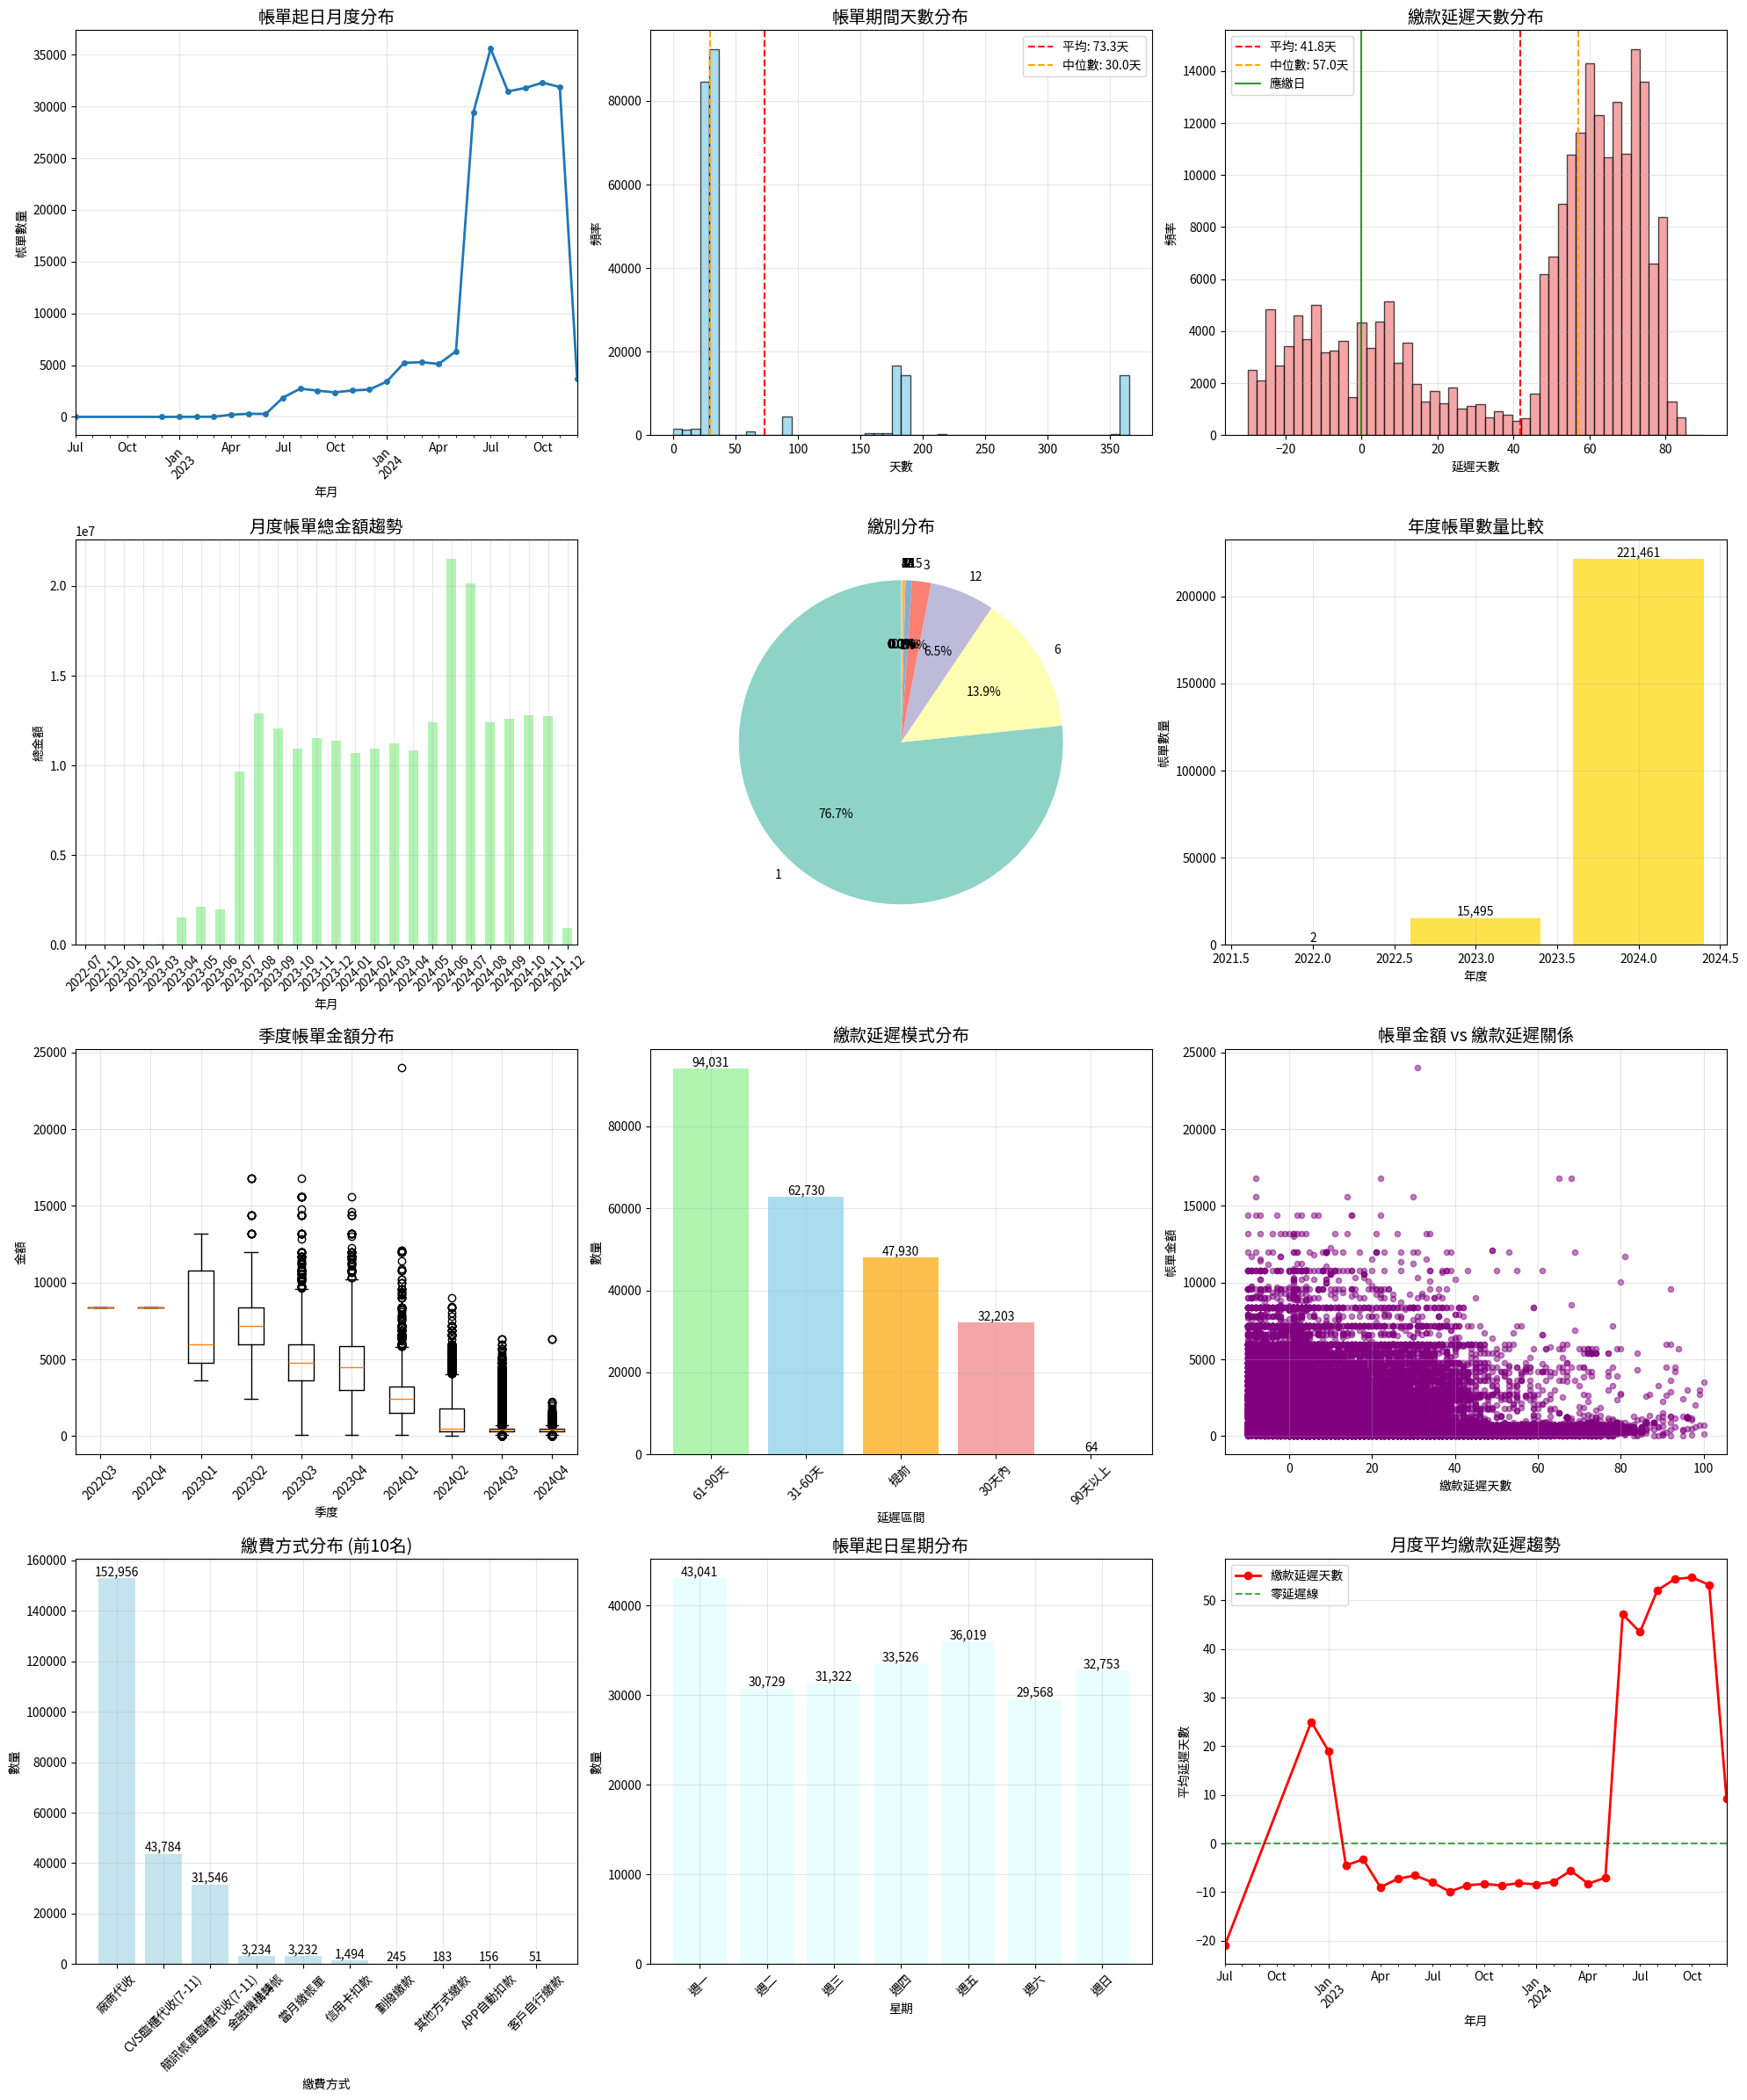


=== 帳務分析統計摘要 ===

📊 帳單基本統計:
帳單總數: 236,958
涉及客戶數: 85,118
資料時間範圍: 2022-07-22 ~ 2024-12-26

📈 帳單期間分析:
平均帳單期間: 76.3 天
帳單期間中位數: 30.0 天
最短帳單期間: 0 天
最長帳單期間: 730 天

💰 帳單金額分析:
總帳單金額: 223,571,840.00
平均帳單金額: 943.51
帳單金額中位數: 450.00
最大帳單金額: 24,000.00
最小帳單金額: 1.00

⏰ 繳款延遲分析:
有銷帳記錄的帳單數: 236,958
平均繳款延遲: 40.0 天
延遲中位數: 56.0 天
最大延遲: 100 天
最小延遲: -60 天

繳款模式分布:
  提前繳款: 46,774 筆 (19.7%)
  準時繳款: 1,156 筆 (0.5%)
  延遲1-30天: 32,203 筆 (13.6%)
  延遲31-60天: 62,730 筆 (26.5%)
  延遲61-90天: 94,031 筆 (39.7%)
  延遲超過90天: 64 筆 (0.0%)

📅 時間分布分析:
年度統計:
  2022年: 2 筆, 總額 16,800.00, 平均 8400.00
  2023年: 15,495 筆, 總額 74,284,460.00, 平均 4794.09
  2024年: 221,461 筆, 總額 149,270,580.00, 平均 674.03

✅ 帳務日期分析與視覺化完成!


In [15]:
import seaborn as sns
import numpy as np
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')


print("=== 帳務日期分析與視覺化 ===")

# 1. 載入並準備資料
bill_data = bill.copy()

# 確保日期格式正確
date_columns = ['帳單起日', '帳單迄日', '銷帳日期']
for col in date_columns:
    if col in bill_data.columns:
        bill_data[col] = pd.to_datetime(bill_data[col], errors='coerce')

# 計算衍生指標
bill_data['帳單期間天數'] = (bill_data['帳單迄日'] - bill_data['帳單起日']).dt.days
bill_data['繳款延遲天數'] = (bill_data['銷帳日期'] - bill_data['帳單起日']).dt.days
bill_data['年月'] = bill_data['帳單起日'].dt.to_period('M')
bill_data['年'] = bill_data['帳單起日'].dt.year
bill_data['月'] = bill_data['帳單起日'].dt.month
bill_data['季度'] = bill_data['帳單起日'].dt.quarter

# 篩選有效資料
valid_data = bill_data.dropna(subset=['帳單起日', '帳單迄日'])
payment_data = bill_data.dropna(subset=['帳單起日', '銷帳日期'])

print(f"總記錄數: {len(bill_data):,}")
print(f"有效帳單記錄數: {len(valid_data):,}")
print(f"有效付款記錄數: {len(payment_data):,}")

# 2. 建立視覺化圖表
fig = plt.figure(figsize=(20, 24))

# 2.1 帳單起日時間分布
plt.subplot(4, 3, 1)
monthly_counts = bill_data.groupby('年月').size()
monthly_counts.plot(kind='line', marker='o', linewidth=2, markersize=4)
plt.title('帳單起日月度分布', fontsize=14, fontweight='bold')
plt.xlabel('年月')
plt.ylabel('帳單數量')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# 2.2 帳單期間天數分布
plt.subplot(4, 3, 2)
valid_periods = valid_data['帳單期間天數']
valid_periods_filtered = valid_periods[(valid_periods >= 0) & (valid_periods <= 365)]
plt.hist(valid_periods_filtered, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
plt.axvline(valid_periods_filtered.mean(), color='red', linestyle='--', 
           label=f'平均: {valid_periods_filtered.mean():.1f}天')
plt.axvline(valid_periods_filtered.median(), color='orange', linestyle='--', 
           label=f'中位數: {valid_periods_filtered.median():.1f}天')
plt.title('帳單期間天數分布', fontsize=14, fontweight='bold')
plt.xlabel('天數')
plt.ylabel('頻率')
plt.legend()
plt.grid(True, alpha=0.3)

# 2.3 繳款延遲天數分布
plt.subplot(4, 3, 3)
delay_days = payment_data['繳款延遲天數']
delay_days_filtered = delay_days[(delay_days >= -30) & (delay_days <= 90)]
plt.hist(delay_days_filtered, bins=50, alpha=0.7, color='lightcoral', edgecolor='black')
plt.axvline(delay_days_filtered.mean(), color='red', linestyle='--', 
           label=f'平均: {delay_days_filtered.mean():.1f}天')
plt.axvline(delay_days_filtered.median(), color='orange', linestyle='--', 
           label=f'中位數: {delay_days_filtered.median():.1f}天')
plt.axvline(0, color='green', linestyle='-', alpha=0.8, label='應繳日')
plt.title('繳款延遲天數分布', fontsize=14, fontweight='bold')
plt.xlabel('延遲天數')
plt.ylabel('頻率')
plt.legend()
plt.grid(True, alpha=0.3)

# 2.4 月度帳單金額趨勢
plt.subplot(4, 3, 4)
monthly_amount = bill_data.groupby('年月')['金額'].agg(['sum', 'mean'])
monthly_amount['sum'].plot(kind='bar', alpha=0.7, color='lightgreen')
plt.title('月度帳單總金額趨勢', fontsize=14, fontweight='bold')
plt.xlabel('年月')
plt.ylabel('總金額')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# 2.5 繳別分布
plt.subplot(4, 3, 5)
payment_type_counts = bill_data['繳別'].value_counts()
plt.pie(payment_type_counts.values, labels=payment_type_counts.index, autopct='%1.1f%%', 
        startangle=90, colors=plt.cm.Set3.colors)
plt.title('繳別分布', fontsize=14, fontweight='bold')

# 2.6 年度帳單數量比較
plt.subplot(4, 3, 6)
yearly_counts = bill_data.groupby('年').size()
bars = plt.bar(yearly_counts.index, yearly_counts.values, alpha=0.7, color='gold')
plt.title('年度帳單數量比較', fontsize=14, fontweight='bold')
plt.xlabel('年度')
plt.ylabel('帳單數量')
# 在柱狀圖上顯示數值
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height):,}', ha='center', va='bottom')
plt.grid(True, alpha=0.3)

# 2.7 季度帳單金額箱型圖
plt.subplot(4, 3, 7)
season_data = []
season_labels = []
for year in bill_data['年'].unique():
    for quarter in [1, 2, 3, 4]:
        quarter_data = bill_data[(bill_data['年'] == year) & (bill_data['季度'] == quarter)]['金額']
        if len(quarter_data) > 0:
            season_data.append(quarter_data)
            season_labels.append(f'{year}Q{quarter}')

if season_data:
    plt.boxplot(season_data, labels=season_labels)
plt.title('季度帳單金額分布', fontsize=14, fontweight='bold')
plt.xlabel('季度')
plt.ylabel('金額')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# 2.8 延遲支付模式分析
plt.subplot(4, 3, 8)
delay_categories = pd.cut(payment_data['繳款延遲天數'], 
                         bins=[-np.inf, 0, 30, 60, 90, np.inf],
                         labels=['提前', '30天內', '31-60天', '61-90天', '90天以上'])
delay_counts = delay_categories.value_counts()
colors = ['lightgreen', 'skyblue', 'orange', 'lightcoral', 'red']
bars = plt.bar(delay_counts.index, delay_counts.values, color=colors, alpha=0.7)
plt.title('繳款延遲模式分布', fontsize=14, fontweight='bold')
plt.xlabel('延遲區間')
plt.ylabel('數量')
plt.xticks(rotation=45)
# 在柱狀圖上顯示數值
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height):,}', ha='center', va='bottom')
plt.grid(True, alpha=0.3)

# 2.9 帳單金額與延遲天數散布圖
plt.subplot(4, 3, 9)
scatter_data = payment_data[(payment_data['繳款延遲天數'] >= -10) & 
                           (payment_data['繳款延遲天數'] <= 100)]
plt.scatter(scatter_data['繳款延遲天數'], scatter_data['金額'], 
           alpha=0.5, s=20, color='purple')
plt.xlabel('繳款延遲天數')
plt.ylabel('帳單金額')
plt.title('帳單金額 vs 繳款延遲關係', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# 2.10 繳費方式分布
plt.subplot(4, 3, 10)
if '繳費方式' in bill_data.columns:
    payment_method_counts = bill_data['繳費方式'].value_counts().head(10)
    bars = plt.bar(range(len(payment_method_counts)), payment_method_counts.values, 
                   alpha=0.7, color='lightblue')
    plt.title('繳費方式分布 (前10名)', fontsize=14, fontweight='bold')
    plt.xlabel('繳費方式')
    plt.ylabel('數量')
    plt.xticks(range(len(payment_method_counts)), payment_method_counts.index, rotation=45)
    # 在柱狀圖上顯示數值
    for i, bar in enumerate(bars):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                 f'{int(height):,}', ha='center', va='bottom')
    plt.grid(True, alpha=0.3)

# 2.11 帳單週期分析（一週中的分布）
plt.subplot(4, 3, 11)
bill_data['weekday'] = bill_data['帳單起日'].dt.day_name()
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_counts = bill_data['weekday'].value_counts().reindex(weekday_order)
chinese_weekdays = ['週一', '週二', '週三', '週四', '週五', '週六', '週日']
bars = plt.bar(chinese_weekdays, weekday_counts.values, alpha=0.7, color='lightcyan')
plt.title('帳單起日星期分布', fontsize=14, fontweight='bold')
plt.xlabel('星期')
plt.ylabel('數量')
plt.xticks(rotation=45)
# 在柱狀圖上顯示數值
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height):,}', ha='center', va='bottom')
plt.grid(True, alpha=0.3)

# 2.12 月度平均延遲趨勢
plt.subplot(4, 3, 12)
monthly_delay = payment_data.groupby('年月')['繳款延遲天數'].mean()
monthly_delay.plot(kind='line', marker='o', linewidth=2, markersize=6, color='red')
plt.title('月度平均繳款延遲趨勢', fontsize=14, fontweight='bold')
plt.xlabel('年月')
plt.ylabel('平均延遲天數')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='green', linestyle='--', alpha=0.7, label='零延遲線')
plt.legend()

plt.tight_layout()
plt.show()

# 3. 統計摘要報告
print(f"\n=== 帳務分析統計摘要 ===")

print(f"\n📊 帳單基本統計:")
print(f"帳單總數: {len(bill_data):,}")
print(f"涉及客戶數: {bill_data['客編'].nunique():,}")
print(f"資料時間範圍: {bill_data['帳單起日'].min().strftime('%Y-%m-%d')} ~ {bill_data['帳單起日'].max().strftime('%Y-%m-%d')}")

print(f"\n📈 帳單期間分析:")
if len(valid_data) > 0:
    print(f"平均帳單期間: {valid_data['帳單期間天數'].mean():.1f} 天")
    print(f"帳單期間中位數: {valid_data['帳單期間天數'].median():.1f} 天")
    print(f"最短帳單期間: {valid_data['帳單期間天數'].min()} 天")
    print(f"最長帳單期間: {valid_data['帳單期間天數'].max()} 天")

print(f"\n💰 帳單金額分析:")
print(f"總帳單金額: {bill_data['金額'].sum():,.2f}")
print(f"平均帳單金額: {bill_data['金額'].mean():.2f}")
print(f"帳單金額中位數: {bill_data['金額'].median():.2f}")
print(f"最大帳單金額: {bill_data['金額'].max():,.2f}")
print(f"最小帳單金額: {bill_data['金額'].min():.2f}")

print(f"\n⏰ 繳款延遲分析:")
if len(payment_data) > 0:
    print(f"有銷帳記錄的帳單數: {len(payment_data):,}")
    print(f"平均繳款延遲: {payment_data['繳款延遲天數'].mean():.1f} 天")
    print(f"延遲中位數: {payment_data['繳款延遲天數'].median():.1f} 天")
    print(f"最大延遲: {payment_data['繳款延遲天數'].max()} 天")
    print(f"最小延遲: {payment_data['繳款延遲天數'].min()} 天")
    
    # 延遲分布統計
    early_payment = (payment_data['繳款延遲天數'] < 0).sum()
    on_time = (payment_data['繳款延遲天數'] == 0).sum()
    late_30 = ((payment_data['繳款延遲天數'] > 0) & (payment_data['繳款延遲天數'] <= 30)).sum()
    late_60 = ((payment_data['繳款延遲天數'] > 30) & (payment_data['繳款延遲天數'] <= 60)).sum()
    late_90 = ((payment_data['繳款延遲天數'] > 60) & (payment_data['繳款延遲天數'] <= 90)).sum()
    very_late = (payment_data['繳款延遲天數'] > 90).sum()
    
    print(f"\n繳款模式分布:")
    print(f"  提前繳款: {early_payment:,} 筆 ({early_payment/len(payment_data)*100:.1f}%)")
    print(f"  準時繳款: {on_time:,} 筆 ({on_time/len(payment_data)*100:.1f}%)")
    print(f"  延遲1-30天: {late_30:,} 筆 ({late_30/len(payment_data)*100:.1f}%)")
    print(f"  延遲31-60天: {late_60:,} 筆 ({late_60/len(payment_data)*100:.1f}%)")
    print(f"  延遲61-90天: {late_90:,} 筆 ({late_90/len(payment_data)*100:.1f}%)")
    print(f"  延遲超過90天: {very_late:,} 筆 ({very_late/len(payment_data)*100:.1f}%)")

print(f"\n📅 時間分布分析:")
yearly_stats = bill_data.groupby('年').agg({
    '帳單起日': 'count',
    '金額': ['sum', 'mean']
}).round(2)
print("年度統計:")
for year in yearly_stats.index:
    count = yearly_stats.loc[year, ('帳單起日', 'count')]
    total_amount = yearly_stats.loc[year, ('金額', 'sum')]
    avg_amount = yearly_stats.loc[year, ('金額', 'mean')]
    print(f"  {year}年: {count:,} 筆, 總額 {total_amount:,.2f}, 平均 {avg_amount:.2f}")

print(f"\n✅ 帳務日期分析與視覺化完成!")

In [16]:
# 計算延遲日數
bill['繳款延遲日數'] = (bill['銷帳日期'] - bill['帳單起日']).dt.days

# 移除無效記錄以計算平均
valid_bills = bill.dropna(subset=['繳款延遲日數'])
avg_global = round(valid_bills['繳款延遲日數'].mean(), 2)

# 平均延遲日數
delay_avg = bill.groupby('客編')['繳款延遲日數'].mean().reset_index()
delay_avg.columns = ['客編', '平均繳款延遲日數']

# 將全體平均補進 NaN 的客戶
all_customers = bill[['客編']].drop_duplicates()
delay_filled = pd.merge(all_customers, delay_avg, on='客編', how='left')
delay_filled['平均繳款延遲日數'] = delay_filled['平均繳款延遲日數'].fillna(avg_global)

# 最常見繳費方式
payment_mode = bill.groupby('客編')['繳費方式'] \
                   .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else '未知') \
                   .reset_index()
payment_mode.columns = ['客編', '最常見繳費方式']

# 合併帳單特徵
# bill_features = pd.merge(delay_avg, payment_mode, on='客編', how='outer')
bill_features = pd.merge(delay_filled, payment_mode, on='客編', how='left')



In [17]:
bill_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85118 entries, 0 to 85117
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   客編        85118 non-null  int64  
 1   平均繳款延遲日數  85118 non-null  float64
 2   最常見繳費方式   85118 non-null  object 
dtypes: float64(1), int64(1), object(1)
memory usage: 1.9+ MB


In [18]:
bill['繳費方式'].value_counts()

繳費方式
廠商代收              152956
CVS臨櫃代收(7-11)      43784
簡訊帳單臨櫃代收(7-11)     31546
金融機構轉帳              3234
當月繳帳單               3232
信用卡扣款               1494
劃撥繳款                 245
其他方式繳款               183
APP自動扣款              156
客戶自行繳款                51
APP臨櫃代收(7-11)         37
需先請款                  29
人工收費單                  4
稽核收款                   3
金融機構繳款                 2
個月繳帳單                  1
專案收款                   1
Name: count, dtype: int64

In [19]:
# 依照 bill_features 中的客編，搜尋 bill 中任一筆相同客編，取出其繳別放到 bill_features 中

print("=== 依客編搜尋繳別並合併至 bill_features ===")

# 1. 檢查當前資料狀態
print(f"bill_features 筆數: {len(bill_features):,}")
print(f"bill 筆數: {len(bill):,}")

# 檢查欄位
print(f"\nbill_features 欄位: {list(bill_features.columns)}")
print(f"bill 欄位: {list(bill.columns)}")

# 2. 確保客編資料型態一致
print(f"\n統一客編資料型態...")
bill_features['客編'] = bill_features['客編'].astype(str)
bill['客編'] = bill['客編'].astype(str)

# 3. 從 bill 中取得每個客編的第一筆繳別
print(f"從 bill 中提取每個客編的繳別...")

# 方法：取每個客編的第一筆非空繳別
bill_payment_type = bill.groupby('客編')['繳別'].first().reset_index()
print(f"bill 中唯一客編數: {len(bill_payment_type):,}")

# 顯示 bill 繳別提取結果樣本
print(f"\nbill 繳別提取樣本 (前10筆):")
print(bill_payment_type.head(10).to_string(index=False))

# 4. 檢查繳別的分布
print(f"\n=== bill 中繳別分布 ===")
payment_type_dist = bill['繳別'].value_counts()
print("繳別分布:")
for payment_type, count in payment_type_dist.items():
    print(f"  {payment_type}: {count:,} 筆")

# 5. 合併繳別到 bill_features
print(f"\n=== 執行合併操作 ===")
print(f"合併前 bill_features 欄位數: {len(bill_features.columns)}")

# 執行左連接，保留所有 bill_features 的記錄
bill_features_with_payment = pd.merge(
    bill_features, 
    bill_payment_type, 
    on='客編', 
    how='left'
)

print(f"合併後 bill_features_with_payment 筆數: {len(bill_features_with_payment):,}")
print(f"合併後欄位數: {len(bill_features_with_payment.columns)}")
print(f"合併後欄位: {list(bill_features_with_payment.columns)}")

# 6. 檢查合併結果
print(f"\n=== 合併結果檢查 ===")

# 檢查繳別欄位的空值情況
null_payment_count = bill_features_with_payment['繳別'].isnull().sum()
not_null_payment_count = bill_features_with_payment['繳別'].notnull().sum()

print(f"繳別為空值的客編數: {null_payment_count:,}")
print(f"繳別有值的客編數: {not_null_payment_count:,}")
print(f"繳別填入成功率: {not_null_payment_count/len(bill_features_with_payment)*100:.2f}%")

# 7. 顯示合併後的繳別分布
if not_null_payment_count > 0:
    print(f"\n合併後繳別分布:")
    merged_payment_dist = bill_features_with_payment['繳別'].value_counts()
    for payment_type, count in merged_payment_dist.items():
        print(f"  {payment_type}: {count:,} 筆")

# 8. 顯示合併結果樣本
print(f"\n=== 合併結果樣本 (前10筆) ===")
display_cols = ['客編', '平均繳款延遲日數', '最常見繳費方式', '繳別']
available_cols = [col for col in display_cols if col in bill_features_with_payment.columns]
print(bill_features_with_payment[available_cols].head(10).to_string(index=False))

# 9. 檢查沒有找到繳別的客編
if null_payment_count > 0:
    print(f"\n=== 沒有找到繳別的客編分析 ===")
    missing_payment_customers = bill_features_with_payment[
        bill_features_with_payment['繳別'].isnull()
    ]['客編']
    
    print(f"沒有找到繳別的客編樣本 (前10個):")
    for i, cust_id in enumerate(missing_payment_customers.head(10)):
        print(f"  {i+1}: {cust_id}")
    
    # 檢查這些客編是否真的不在 bill 中
    missing_in_bill = 0
    for cust_id in missing_payment_customers.head(5):  # 檢查前5個
        exists_in_bill = (bill['客編'] == cust_id).any()
        if not exists_in_bill:
            missing_in_bill += 1
            print(f"    客編 {cust_id}: 不存在於 bill 中")
        else:
            # 檢查該客編在 bill 中的繳別情況
            cust_records = bill[bill['客編'] == cust_id]
            payment_types = cust_records['繳別'].dropna().unique()
            print(f"    客編 {cust_id}: 在 bill 中但繳別為 {payment_types}")

# 10. 處理繳別空值（可選）
print(f"\n=== 處理繳別空值 ===")
if null_payment_count > 0:
    # 可以用最常見的繳別來填補空值
    most_common_payment = bill_features_with_payment['繳別'].mode()
    
    if len(most_common_payment) > 0:
        most_common_value = most_common_payment.iloc[0]
        print(f"最常見繳別: {most_common_value}")
        print(f"是否要用最常見繳別填補空值? (建議手動決定)")
        
        # 取消註解下面兩行來執行填補
        # bill_features_with_payment['繳別'].fillna(most_common_value, inplace=True)
        # print(f"✅ 已用 {most_common_value} 填補 {null_payment_count} 個繳別空值")

# 11. 更新原始 bill_features 變數
bill_features = bill_features_with_payment.copy()
print(f"\n✅ bill_features 已更新為包含繳別的版本")

# 12. 最終驗證
print(f"\n=== 最終驗證 ===")
print(f"最終 bill_features 筆數: {len(bill_features):,}")
print(f"最終欄位: {list(bill_features.columns)}")

final_null_payment = bill_features['繳別'].isnull().sum()
print(f"最終繳別空值數: {final_null_payment:,}")

if final_null_payment == 0:
    print("✅ 所有客編都已成功獲得繳別資料")
else:
    print(f"⚠️ 仍有 {final_null_payment:,} 個客編沒有繳別資料")

# 顯示最終結果
print(f"\n最終 bill_features 樣本:")
print(bill_features.head().to_string(index=False))

print(f"\n🎯 客編繳別搜尋合併作業完成！")

=== 依客編搜尋繳別並合併至 bill_features ===
bill_features 筆數: 85,118
bill 筆數: 236,958

bill_features 欄位: ['客編', '平均繳款延遲日數', '最常見繳費方式']
bill 欄位: ['客編', '相關編號', '帳單起日', '帳單迄日', '金額', '銷帳日期', '繳別', '繳費方式', '繳款延遲日數']

統一客編資料型態...
從 bill 中提取每個客編的繳別...
bill 中唯一客編數: 85,118

bill 繳別提取樣本 (前10筆):
     客編  繳別
1000012  12
1000015   6
1000037  12
1000046   6
1000084  12
1000101   1
1000107   6
1000110   6
1000123   1
 100015   1

=== bill 中繳別分布 ===
繳別分布:
  1: 181,636 筆
  6: 32,960 筆
  12: 15,294 筆
  3: 4,482 筆
  15: 1,514 筆
  2: 712 筆
  7: 179 筆
  4: 99 筆
  16: 34 筆
  18: 23 筆
  13: 9 筆
  8: 6 筆
  14: 6 筆
  24: 2 筆
  5: 2 筆

=== 執行合併操作 ===
合併前 bill_features 欄位數: 3
合併後 bill_features_with_payment 筆數: 85,118
合併後欄位數: 4
合併後欄位: ['客編', '平均繳款延遲日數', '最常見繳費方式', '繳別']

=== 合併結果檢查 ===
繳別為空值的客編數: 0
繳別有值的客編數: 85,118
繳別填入成功率: 100.00%

合併後繳別分布:
  1: 33,163 筆
  6: 32,398 筆
  12: 15,211 筆
  3: 2,300 筆
  15: 1,483 筆
  2: 241 筆
  7: 177 筆
  4: 63 筆
  16: 34 筆
  18: 23 筆
  13: 9 筆
  8: 6 筆
  14: 6 筆
  24: 2 筆
  5: 2 筆

=== 合併結果樣

In [20]:
bill_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85118 entries, 0 to 85117
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   客編        85118 non-null  object 
 1   平均繳款延遲日數  85118 non-null  float64
 2   最常見繳費方式   85118 non-null  object 
 3   繳別        85118 non-null  int64  
dtypes: float64(1), int64(1), object(2)
memory usage: 2.6+ MB


In [81]:
bill_features.head(10)

,客編,平均繳款延遲日數,最常見繳費方式,繳別
0,933144,-18.0,CVS臨櫃代收(7-11),24
1,224088,29.0,CVS臨櫃代收(7-11),24
2,975731,-39.0,CVS臨櫃代收(7-11),18
3,1107235,-21.0,簡訊帳單臨櫃代收(7-11),24
4,941082,-14.0,CVS臨櫃代收(7-11),18
5,964554,-16.0,CVS臨櫃代收(7-11),18
6,981423,-13.0,CVS臨櫃代收(7-11),18
7,1059699,1.0,CVS臨櫃代收(7-11),18
8,1096320,-15.0,CVS臨櫃代收(7-11),16
9,1130775,-27.0,CVS臨櫃代收(7-11),16


In [21]:
# 儲存
bill_features.to_csv('forTrain_ds_bill_24_h2.csv', index=False, sep='^')
print("✅ 成功轉換並合併，已輸出為 forTrain_ds_bill_24_h2.csv")

✅ 成功轉換並合併，已輸出為 forTrain_ds_bill_24_h2.csv


<<< 此處為分界點，後續權當參考 >>>

In [59]:
import pandas as pd
# 載入資料
dataset = pd.read_csv('cleaned_dataset_20251201.csv',sep='^')

C:\Users\user\AppData\Local\Temp\ipykernel_11204\1422207356.py:3: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  dataset = pd.read_csv('cleaned_dataset_20251201.csv',sep='^')


In [60]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 346781 entries, 0 to 346780
Data columns (total 10 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   客編      346781 non-null  int64 
 1   產品名稱    346781 non-null  object
 2   用戶種類    346781 non-null  object
 3   相關編號    346781 non-null  int64 
 4   起日      346781 non-null  object
 5   迄日      196679 non-null  object
 6   系統台     346781 non-null  object
 7   地區      346750 non-null  object
 8   繳別      346781 non-null  int64 
 9   使用狀態    346781 non-null  object
dtypes: int64(3), object(7)
memory usage: 26.5+ MB


In [ ]:
ds = pd.read_csv('/content/bill_22_24_filtered.csv',sep='^')

In [ ]:
ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1785869 entries, 0 to 1785868
Data columns (total 8 columns):
 #   Column  Dtype 
---  ------  ----- 
 0   客編      int64 
 1   相關編號    int64 
 2   帳單起日    object
 3   帳單迄日    object
 4   金額      int64 
 5   銷帳日期    object
 6   繳別      int64 
 7   繳費方式    object
dtypes: int64(4), object(4)
memory usage: 109.0+ MB


In [ ]:
import pandas as pd
# 載入資料
ds = pd.read_csv('/content/ds_numService_with_billing.csv',sep=',')

In [ ]:
ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47310 entries, 0 to 47309
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   客編        47310 non-null  int64  
 1   相關編號      47310 non-null  int64  
 2   30天內      47310 non-null  int64  
 3   60天內      47310 non-null  int64  
 4   90天內      47310 non-null  int64  
 5   90天以上     47310 non-null  int64  
 6   平均等待天數    47310 non-null  float64
 7   繳別        47310 non-null  int64  
 8   使用狀態_數值   47310 non-null  int64  
 9   產品名稱_數值   47310 non-null  int64  
 10  平均繳款延遲日數  47310 non-null  float64
 11  最常見繳費方式   47310 non-null  object 
dtypes: float64(2), int64(9), object(1)
memory usage: 4.3+ MB


In [ ]:
import pandas as pd

# 載入資料
ds = pd.read_csv('ds_numService.csv',sep='^')
bill = ds_bill_filtered.copy()  # 建立副本

# 清洗欄位名稱
ds.columns = ds.columns.str.strip()
bill.columns = bill.columns.str.strip()

# 👉 將 '銷帳日期' 中中文月份轉為英文縮寫（供 datetime 解析）
month_map = {
    '1月': 'Jan', '2月': 'Feb', '3月': 'Mar', '4月': 'Apr',
    '5月': 'May', '6月': 'Jun', '7月': 'Jul', '8月': 'Aug',
    '9月': 'Sep', '10月': 'Oct', '11月': 'Nov', '12月': 'Dec'
}

# 替換中文月份
for zh, en in month_map.items():
    bill['銷帳日期'] = bill['銷帳日期'].str.replace(zh, en, regex=False)

# 轉換為 datetime 格式
bill['銷帳日期'] = pd.to_datetime(bill['銷帳日期'], format='%d-%b -%y', errors='coerce')

# 解析 '帳單迄日'
bill['帳單起日'] = pd.to_datetime(bill['帳單起日'], format='%Y-%m-%d %H:%M:%S', errors='coerce')

# 計算延遲日數
bill['繳款延遲日數'] = (bill['銷帳日期'] - bill['帳單起日']).dt.days

# 移除無效記錄以計算平均
valid_bills = bill.dropna(subset=['繳款延遲日數'])
avg_global = round(valid_bills['繳款延遲日數'].mean(), 2)

# 平均延遲日數
delay_avg = bill.groupby('客編')['繳款延遲日數'].mean().reset_index()
delay_avg.columns = ['客編', '平均繳款延遲日數']

# 將全體平均補進 NaN 的客戶
all_customers = bill[['客編']].drop_duplicates()
delay_filled = pd.merge(all_customers, delay_avg, on='客編', how='left')
delay_filled['平均繳款延遲日數'] = delay_filled['平均繳款延遲日數'].fillna(avg_global)

# 最常見繳費方式
payment_mode = bill.groupby('客編')['繳費方式'] \
                   .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else '未知') \
                   .reset_index()
payment_mode.columns = ['客編', '最常見繳費方式']

# 合併帳單特徵
# bill_features = pd.merge(delay_avg, payment_mode, on='客編', how='outer')
bill_features = pd.merge(delay_filled, payment_mode, on='客編', how='left')

# 合併至主訓練集
merged_df = pd.merge(ds, bill_features, on='客編', how='left')

# 儲存
merged_df.to_csv('ds_numService_with_billing.csv', index=False)
print("✅ 成功轉換並合併，已輸出為 ds_numService_with_billing.csv")

✅ 成功轉換並合併，已輸出為 ds_numService_with_billing.csv
